<a href="https://colab.research.google.com/github/insocandy/AI-Resume-Analyzer/blob/main/initial_finetuning_beacon_Ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:

!nvidia-smi

Tue Aug 18 08:52:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   65C    P0             31W /   70W |    5589MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [54]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [55]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [56]:
import os

project_path = "/content/drive/MyDrive/Beacon_AI"

os.makedirs(project_path, exist_ok=True)

print(project_path)

/content/drive/MyDrive/Beacon_AI


In [57]:
!pip install -q \
transformers \
datasets \
accelerate \
peft \
trl \
bitsandbytes \
qwen-vl-utils \
pillow

In [58]:
from huggingface_hub import login

login()

In [59]:
import transformers

print(transformers.__version__)

5.13.1


In [60]:
from transformers import Qwen2_5_VLForConditionalGeneration
from transformers import AutoProcessor
from transformers import BitsAndBytesConfig

In [61]:
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training
)

In [62]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True
)

In [63]:
processor = AutoProcessor.from_pretrained(
    "Qwen/Qwen2.5-VL-3B-Instruct"
)

In [64]:
print(processor)

Qwen2_5_VLProcessor:
- image_processor: Qwen2VLImageProcessor {
  "do_convert_rgb": true,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.48145466,
    0.4578275,
    0.40821073
  ],
  "image_processor_type": "Qwen2VLImageProcessor",
  "image_std": [
    0.26862954,
    0.26130258,
    0.27577711
  ],
  "merge_size": 2,
  "patch_size": 14,
  "resample": 3,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "longest_edge": 12845056,
    "shortest_edge": 3136
  },
  "temporal_patch_size": 2
}

- tokenizer: Qwen2Tokenizer(name_or_path='Qwen/Qwen2.5-VL-3B-Instruct', vocab_size=151643, model_max_length=131072, padding_side='right', truncation_side='right', special_tokens={'eos_token': '<|im_end|>', 'pad_token': '<|endoftext|>'}, added_tokens_decoder={
	151643: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151644: AddedToken("<|im_start|>", rstrip=False, lstrip=False, single_word=F

In [65]:
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2.5-VL-3B-Instruct",
    quantization_config=bnb_config,
    device_map="auto"
)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

In [66]:
print(type(model))

print(type(processor))

<class 'transformers.models.qwen2_5_vl.modeling_qwen2_5_vl.Qwen2_5_VLForConditionalGeneration'>
<class 'transformers.models.qwen2_5_vl.processing_qwen2_5_vl.Qwen2_5_VLProcessor'>


In [67]:
model = prepare_model_for_kbit_training(model)

In [68]:
count = 0

for name, param in model.named_parameters():
    if param.requires_grad:
        count += 1

print("Trainable Parameters:", count)

Trainable Parameters: 0


In [69]:
from peft import LoraConfig

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj"
    ],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

In [70]:
model = get_peft_model(model, lora_config)

In [71]:
model.print_trainable_parameters()

trainable params: 37,152,768 || all params: 3,791,775,744 || trainable%: 0.9798


In [72]:
for name, module in model.named_modules():

    if "lora" in name.lower():
        print(name)

base_model.model.model.visual.blocks.0.mlp.gate_proj.lora_dropout
base_model.model.model.visual.blocks.0.mlp.gate_proj.lora_dropout.default
base_model.model.model.visual.blocks.0.mlp.gate_proj.lora_A
base_model.model.model.visual.blocks.0.mlp.gate_proj.lora_A.default
base_model.model.model.visual.blocks.0.mlp.gate_proj.lora_B
base_model.model.model.visual.blocks.0.mlp.gate_proj.lora_B.default
base_model.model.model.visual.blocks.0.mlp.gate_proj.lora_embedding_A
base_model.model.model.visual.blocks.0.mlp.gate_proj.lora_embedding_B
base_model.model.model.visual.blocks.0.mlp.gate_proj.lora_magnitude_vector
base_model.model.model.visual.blocks.0.mlp.up_proj.lora_dropout
base_model.model.model.visual.blocks.0.mlp.up_proj.lora_dropout.default
base_model.model.model.visual.blocks.0.mlp.up_proj.lora_A
base_model.model.model.visual.blocks.0.mlp.up_proj.lora_A.default
base_model.model.model.visual.blocks.0.mlp.up_proj.lora_B
base_model.model.model.visual.blocks.0.mlp.up_proj.lora_B.default
base_

In [73]:
for name, module in model.model.named_children():
    print(name)

model
lm_head


In [74]:
print(type(model))

<class 'peft.peft_model.PeftModelForCausalLM'>


In [75]:
for name, module in model.named_modules():
    if "lora" in name.lower():
        print(name)
        break

base_model.model.model.visual.blocks.0.mlp.gate_proj.lora_dropout


In [76]:
print(type(model))

<class 'peft.peft_model.PeftModelForCausalLM'>


In [77]:
for name, module in model.named_modules():
    if "layers.0" in name:
        print(name)

base_model.model.model.language_model.layers.0
base_model.model.model.language_model.layers.0.self_attn
base_model.model.model.language_model.layers.0.self_attn.q_proj
base_model.model.model.language_model.layers.0.self_attn.q_proj.base_layer
base_model.model.model.language_model.layers.0.self_attn.q_proj.lora_dropout
base_model.model.model.language_model.layers.0.self_attn.q_proj.lora_dropout.default
base_model.model.model.language_model.layers.0.self_attn.q_proj.lora_A
base_model.model.model.language_model.layers.0.self_attn.q_proj.lora_A.default
base_model.model.model.language_model.layers.0.self_attn.q_proj.lora_B
base_model.model.model.language_model.layers.0.self_attn.q_proj.lora_B.default
base_model.model.model.language_model.layers.0.self_attn.q_proj.lora_embedding_A
base_model.model.model.language_model.layers.0.self_attn.q_proj.lora_embedding_B
base_model.model.model.language_model.layers.0.self_attn.q_proj.lora_magnitude_vector
base_model.model.model.language_model.layers.0.

In [78]:
for name, module in model.named_modules():
    if "lora_A" in name:
        print(name)
        break

base_model.model.model.visual.blocks.0.mlp.gate_proj.lora_A


In [79]:
for name, module in model.named_modules():
    if "language_model" in name and "q_proj" in name:
        print(name)
        break

base_model.model.model.language_model.layers.0.self_attn.q_proj


In [80]:
for name, module in model.named_modules():
    if "language_model" in name and "lora_A" in name:
        print(name)
        break

base_model.model.model.language_model.layers.0.self_attn.q_proj.lora_A


In [81]:
import torch

from transformers import (
    Qwen2_5_VLForConditionalGeneration,
    BitsAndBytesConfig
)

from peft import prepare_model_for_kbit_training

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True
)

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2.5-VL-3B-Instruct",
    quantization_config=bnb_config,
    device_map="auto"
)

model = prepare_model_for_kbit_training(model)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

In [82]:
for name, module in model.named_modules():
    if "language_model.layers" in name and "q_proj" in name:
        print(name)

model.language_model.layers.0.self_attn.q_proj
model.language_model.layers.1.self_attn.q_proj
model.language_model.layers.2.self_attn.q_proj
model.language_model.layers.3.self_attn.q_proj
model.language_model.layers.4.self_attn.q_proj
model.language_model.layers.5.self_attn.q_proj
model.language_model.layers.6.self_attn.q_proj
model.language_model.layers.7.self_attn.q_proj
model.language_model.layers.8.self_attn.q_proj
model.language_model.layers.9.self_attn.q_proj
model.language_model.layers.10.self_attn.q_proj
model.language_model.layers.11.self_attn.q_proj
model.language_model.layers.12.self_attn.q_proj
model.language_model.layers.13.self_attn.q_proj
model.language_model.layers.14.self_attn.q_proj
model.language_model.layers.15.self_attn.q_proj
model.language_model.layers.16.self_attn.q_proj
model.language_model.layers.17.self_attn.q_proj
model.language_model.layers.18.self_attn.q_proj
model.language_model.layers.19.self_attn.q_proj
model.language_model.layers.20.self_attn.q_proj
mo

In [83]:
target_modules = []

for name, module in model.named_modules():

    if "model.language_model.layers." in name:
        if name.endswith((
            "self_attn.q_proj",
            "self_attn.k_proj",
            "self_attn.v_proj",
            "self_attn.o_proj"
        )):
            target_modules.append(name)

print("Number of target modules:", len(target_modules))

for name in target_modules[:8]:
    print(name)

Number of target modules: 144
model.language_model.layers.0.self_attn.q_proj
model.language_model.layers.0.self_attn.k_proj
model.language_model.layers.0.self_attn.v_proj
model.language_model.layers.0.self_attn.o_proj
model.language_model.layers.1.self_attn.q_proj
model.language_model.layers.1.self_attn.k_proj
model.language_model.layers.1.self_attn.v_proj
model.language_model.layers.1.self_attn.o_proj


In [84]:
from peft import LoraConfig

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=target_modules,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

In [85]:
from peft import get_peft_model

model = get_peft_model(model, lora_config)

In [86]:
model.print_trainable_parameters()

trainable params: 7,372,800 || all params: 3,761,995,776 || trainable%: 0.1960


In [87]:
vision_lora = []
language_lora = []

for name, module in model.named_modules():

    if "lora_" in name:

        if ".visual." in name:
            vision_lora.append(name)

        elif ".language_model." in name:
            language_lora.append(name)

print("Vision LoRA modules:", len(vision_lora))
print("Language LoRA modules:", len(language_lora))

Vision LoRA modules: 0
Language LoRA modules: 1296


In [88]:
trainable = 0
frozen = 0

for name, param in model.named_parameters():

    if param.requires_grad:
        trainable += param.numel()

        if "lora_" not in name:
            print("⚠️ Unexpected trainable parameter:", name)

    else:
        frozen += param.numel()

print("Trainable:", trainable)
print("Frozen:", frozen)

Trainable: 7372800
Frozen: 2034024448


In [89]:
vision_trainable = []

for name, param in model.named_parameters():

    if ".visual." in name and param.requires_grad:
        vision_trainable.append(name)

print("Trainable vision parameters:", len(vision_trainable))

Trainable vision parameters: 0


In [90]:
class BeaconCollator:

    def __init__(self, processor):
        self.processor = processor

    def create_assistant_labels(self, input_ids):

        labels = input_ids.clone()

        assistant_header = self.processor.tokenizer.encode(
            "<|im_start|>assistant\n",
            add_special_tokens=False
        )

        header_len = len(assistant_header)

        for i in range(input_ids.shape[0]):

            sequence = input_ids[i].tolist()

            # Start by ignoring EVERYTHING
            labels[i, :] = -100

            # Find every assistant response
            for j in range(len(sequence) - header_len + 1):

                if sequence[j:j + header_len] == assistant_header:

                    response_start = j + header_len

                    # Find the next <|im_end|>
                    response_end = None

                    for k in range(response_start, len(sequence)):

                        if sequence[k] == 151645:  # <|im_end|>
                            response_end = k
                            break

                    if response_end is None:
                        response_end = len(sequence)

                    # Train on this assistant response
                    labels[i, response_start:response_end + 1] = \
                        input_ids[i, response_start:response_end + 1]

        return labels


    def __call__(self, batch):

        images = []
        texts = []

        for sample in batch:

            images.append(sample["image"])

            text = self.processor.apply_chat_template(
                sample["messages"],
                tokenize=False,
                add_generation_prompt=False
            )

            texts.append(text)

        model_inputs = self.processor(
            text=texts,
            images=images,
            padding=True,
            return_tensors="pt"
        )

        # IMPORTANT:
        # Only assistant response contributes to loss
        model_inputs["labels"] = self.create_assistant_labels(
            model_inputs["input_ids"]
        )

        return model_inputs

In [91]:
print([name for name in globals() if "data" in name.lower()])

['Dataset', 'BeaconFashionDataset', 'dataset']


In [92]:
import os

In [93]:
from torch.utils.data import Dataset
from PIL import Image
import json
from pathlib import Path


PROJECT_ROOT = Path("/content/BeaconAI")

TRAIN_FILE = PROJECT_ROOT / "datasets/annotations/train.jsonl"


class BeaconFashionDataset(Dataset):

    def __init__(self, annotation_file):

        self.samples = []

        with open(annotation_file, "r") as f:
            for line in f:
                self.samples.append(json.loads(line))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        sample = self.samples[idx]

        image = Image.open(sample["image"]).convert("RGB")

        return {
            "image": image,
            "messages": sample["messages"],
            "metadata": sample["metadata"]
        }

In [94]:
os.makedirs("/content/BeaconAI/datasets/images", exist_ok=True)
os.makedirs("/content/BeaconAI/datasets/annotations", exist_ok=True)
os.makedirs("/content/BeaconAI/checkpoints", exist_ok=True)
os.makedirs("/content/BeaconAI/outputs", exist_ok=True)

In [95]:
PROJECT_ROOT = Path("/content/BeaconAI")

IMAGE_DIR = PROJECT_ROOT / "datasets/images"

ANNOTATION_DIR = PROJECT_ROOT / "datasets/annotations"

TRAIN_FILE = ANNOTATION_DIR / "train.jsonl"

In [96]:
import os

print("Current directory:", os.getcwd())
print("\n/content:")
print(os.listdir("/content"))

print("\nMyDrive:")
if os.path.exists("/content/drive/MyDrive"):
    print(os.listdir("/content/drive/MyDrive")[:30])
else:
    print("Google Drive is not mounted")

Current directory: /content

/content:
['.config', 'drive', 'BeaconAI', 'sample_data']

MyDrive:
['Munzir abdul jabbar.pdf', 'Munzir abdul jabbar (1) (1).pdf', 'Sharer.pw', 'DriveStore.Net', 'Screenshot_20201202-165515_YouTube.jpg', 'Lab 1 Full.1 (3).pdf', 'Lab 1 Full.1.gdoc', 'education-kahqq715ytoqv7yq-1595339229.pdf', '2d33262f-3bb5-421e-aa02-9c83399fb233.pdf', 'Engg2013Maths.pdf', 'Engg_Tech_Maths1.7.pdf', 'KEAM 2013 solved question paper Mathematics.pdf', 'Important Questions in Complex numbers.pdf', 'KEAM 2015 Engineering Entrance Answer Key- MATHEMATICS.pdf', 'KEAM 2016 Question paper PAPER II Mathematics.pdf', 'KEAM 2015 Question Paper - MATHS.pdf', 'KEAM-2013-Question-paper-Mathematics.pdf', 'KEAM 2014 Mathematics Question paper with key 1.pdf', 'KEAM-2013-Question-paper-Physics-and-Chemistry.pdf', 'KEAM-2014-Question-paper-Mathematics.pdf', 'KEAM-2016-Answer-Key-Mathematics.pdf', 'KEAM-2015-Question-paper-Mathematics.pdf', 'KEAM-2016-Paper-2-Previous-Year-Papers-recruitmentre

In [97]:
from pathlib import Path

for path in Path("/content/BeaconAI").rglob("*"):
    if path.is_file():
        print(path)

/content/BeaconAI/datasets/images/dress0001.jpg
/content/BeaconAI/datasets/annotations/train.jsonl


In [98]:
import os

print("BeaconAI exists:", os.path.exists("/content/BeaconAI"))
print("BeaconAI contents:", os.listdir("/content/BeaconAI"))

BeaconAI exists: True
BeaconAI contents: ['datasets', 'outputs', 'checkpoints']


In [99]:
!find /content/BeaconAI -maxdepth 5 -print

/content/BeaconAI
/content/BeaconAI/datasets
/content/BeaconAI/datasets/images
/content/BeaconAI/datasets/images/dress0001.jpg
/content/BeaconAI/datasets/annotations
/content/BeaconAI/datasets/annotations/train.jsonl
/content/BeaconAI/outputs
/content/BeaconAI/checkpoints


In [100]:
import os

print("Images:", os.listdir("/content/BeaconAI/datasets/images"))
print("Annotations:", os.listdir("/content/BeaconAI/datasets/annotations"))

Images: ['dress0001.jpg']
Annotations: ['train.jsonl']


In [101]:
dataset = BeaconFashionDataset(TRAIN_FILE)

print("Dataset size:", len(dataset))

Dataset size: 1


In [102]:
collator = BeaconCollator(processor)

batch = collator([dataset[0]])

print(batch.keys())

KeysView({'input_ids': tensor([[151644,   8948,    198,  ...,     13, 151645,    198]]), 'attention_mask': tensor([[1, 1, 1,  ..., 1, 1, 1]]), 'mm_token_type_ids': tensor([[0, 0, 0,  ..., 0, 0, 0]]), 'pixel_values': tensor([[1.5216, 1.5362, 1.5362,  ..., 1.6909, 1.6766, 1.6766],
        [1.5946, 1.5946, 1.6238,  ..., 1.6909, 1.6909, 1.6766],
        [1.5508, 1.5508, 1.5362,  ..., 1.6909, 1.6909, 1.6909],
        ...,
        [0.9814, 0.9814, 1.0690,  ..., 0.9372, 0.9230, 0.9088],
        [0.8647, 0.8501, 1.0252,  ..., 1.0652, 1.0083, 0.9799],
        [1.0690, 1.0398, 1.0836,  ..., 0.8803, 0.9656, 1.0652]]), 'image_grid_thw': tensor([[  1, 288, 216]]), 'labels': tensor([[  -100,   -100,   -100,  ...,     13, 151645,   -100]])})


In [103]:
labels = batch["labels"]

for i, label in enumerate(labels[0]):

    if label.item() == -100:
        print(i, "IGNORED")
    else:
        print(i, processor.tokenizer.decode([label.item()]))

Streaming output truncated to the last 5000 lines.
10620 IGNORED
10621 IGNORED
10622 IGNORED
10623 IGNORED
10624 IGNORED
10625 IGNORED
10626 IGNORED
10627 IGNORED
10628 IGNORED
10629 IGNORED
10630 IGNORED
10631 IGNORED
10632 IGNORED
10633 IGNORED
10634 IGNORED
10635 IGNORED
10636 IGNORED
10637 IGNORED
10638 IGNORED
10639 IGNORED
10640 IGNORED
10641 IGNORED
10642 IGNORED
10643 IGNORED
10644 IGNORED
10645 IGNORED
10646 IGNORED
10647 IGNORED
10648 IGNORED
10649 IGNORED
10650 IGNORED
10651 IGNORED
10652 IGNORED
10653 IGNORED
10654 IGNORED
10655 IGNORED
10656 IGNORED
10657 IGNORED
10658 IGNORED
10659 IGNORED
10660 IGNORED
10661 IGNORED
10662 IGNORED
10663 IGNORED
10664 IGNORED
10665 IGNORED
10666 IGNORED
10667 IGNORED
10668 IGNORED
10669 IGNORED
10670 IGNORED
10671 IGNORED
10672 IGNORED
10673 IGNORED
10674 IGNORED
10675 IGNORED
10676 IGNORED
10677 IGNORED
10678 IGNORED
10679 IGNORED
10680 IGNORED
10681 IGNORED
10682 IGNORED
10683 IGNORED
10684 IGNORED
10685 IGNORED
10686 IGNORED
10687 IGNOR

In [104]:
test_messages = [
    {
        "role": "system",
        "content": "You are Beacon AI."
    },
    {
        "role": "user",
        "content": "Describe this dress."
    },
    {
        "role": "assistant",
        "content": "It is a blue floral maxi dress."
    },
    {
        "role": "user",
        "content": "Make it gothic."
    },
    {
        "role": "assistant",
        "content": "Use darker tones and gothic detailing."
    }
]

In [105]:
test_text = processor.apply_chat_template(
    test_messages,
    tokenize=False,
    add_generation_prompt=False
)

print(test_text)

<|im_start|>system
You are Beacon AI.<|im_end|>
<|im_start|>user
Describe this dress.<|im_end|>
<|im_start|>assistant
It is a blue floral maxi dress.<|im_end|>
<|im_start|>user
Make it gothic.<|im_end|>
<|im_start|>assistant
Use darker tones and gothic detailing.<|im_end|>



In [106]:
test_tokens = processor.tokenizer(
    test_text,
    return_tensors="pt"
)

test_labels = collator.create_assistant_labels(
    test_tokens["input_ids"]
)

In [107]:
for i, label in enumerate(test_labels[0]):

    if label.item() == -100:
        print(i, "IGNORED")
    else:
        print(i, processor.tokenizer.decode([label.item()]))

0 IGNORED
1 IGNORED
2 IGNORED
3 IGNORED
4 IGNORED
5 IGNORED
6 IGNORED
7 IGNORED
8 IGNORED
9 IGNORED
10 IGNORED
11 IGNORED
12 IGNORED
13 IGNORED
14 IGNORED
15 IGNORED
16 IGNORED
17 IGNORED
18 IGNORED
19 IGNORED
20 IGNORED
21 IGNORED
22 It
23  is
24  a
25  blue
26  floral
27  maxi
28  dress
29 .
30 <|im_end|>
31 IGNORED
32 IGNORED
33 IGNORED
34 IGNORED
35 IGNORED
36 IGNORED
37 IGNORED
38 IGNORED
39 IGNORED
40 IGNORED
41 IGNORED
42 IGNORED
43 IGNORED
44 IGNORED
45 Use
46  darker
47  tones
48  and
49  go
50 thic
51  detailing
52 .
53 <|im_end|>
54 IGNORED


In [108]:
collator = BeaconCollator(processor)

batch = collator([dataset[0]])

print("Labels shape:", batch["labels"].shape)
print(
    "Ignored tokens:",
    (batch["labels"] == -100).sum().item()
)
print(
    "Trainable target tokens:",
    (batch["labels"] != -100).sum().item()
)

Labels shape: torch.Size([1, 15620])
Ignored tokens: 15592
Trainable target tokens: 28


In [109]:

from torch.utils.data import DataLoader

In [110]:
dataloader = DataLoader(
    dataset,
    batch_size=1,
    shuffle=True,
    collate_fn=collator
)

print("DataLoader created successfully!")

DataLoader created successfully!


In [111]:
batch = next(iter(dataloader))

print(batch.keys())

KeysView({'input_ids': tensor([[151644,   8948,    198,  ...,     13, 151645,    198]]), 'attention_mask': tensor([[1, 1, 1,  ..., 1, 1, 1]]), 'mm_token_type_ids': tensor([[0, 0, 0,  ..., 0, 0, 0]]), 'pixel_values': tensor([[1.5216, 1.5362, 1.5362,  ..., 1.6909, 1.6766, 1.6766],
        [1.5946, 1.5946, 1.6238,  ..., 1.6909, 1.6909, 1.6766],
        [1.5508, 1.5508, 1.5362,  ..., 1.6909, 1.6909, 1.6909],
        ...,
        [0.9814, 0.9814, 1.0690,  ..., 0.9372, 0.9230, 0.9088],
        [0.8647, 0.8501, 1.0252,  ..., 1.0652, 1.0083, 0.9799],
        [1.0690, 1.0398, 1.0836,  ..., 0.8803, 0.9656, 1.0652]]), 'image_grid_thw': tensor([[  1, 288, 216]]), 'labels': tensor([[  -100,   -100,   -100,  ...,     13, 151645,   -100]])})


In [112]:
for key, value in batch.items():
    print(key, value.shape, value.dtype)

input_ids torch.Size([1, 15620]) torch.int64
attention_mask torch.Size([1, 15620]) torch.int64
mm_token_type_ids torch.Size([1, 15620]) torch.int64
pixel_values torch.Size([62208, 1176]) torch.float32
image_grid_thw torch.Size([1, 3]) torch.int64
labels torch.Size([1, 15620]) torch.int64


In [113]:
collator = BeaconCollator(processor)

dataloader = DataLoader(
    dataset,
    batch_size=1,
    shuffle=True,
    collate_fn=collator
)

In [114]:
batch = {
    k: v.to(model.device)
    for k, v in batch.items()
}

In [115]:
print("Batch moved to:", model.device)

Batch moved to: cuda:0


In [116]:
from transformers import AutoProcessor

processor = AutoProcessor.from_pretrained(
    "Qwen/Qwen2.5-VL-3B-Instruct",
    min_pixels=256 * 28 * 28,
    max_pixels=512 * 28 * 28
)

In [117]:
collator = BeaconCollator(processor)

In [118]:
batch = collator([dataset[0]])

In [119]:
for key, value in batch.items():
    print(key, value.shape)

input_ids torch.Size([1, 562])
attention_mask torch.Size([1, 562])
mm_token_type_ids torch.Size([1, 562])
pixel_values torch.Size([1976, 1176])
image_grid_thw torch.Size([1, 3])
labels torch.Size([1, 562])


In [120]:
batch = {
    k: v.to(model.device)
    for k, v in batch.items()
}

In [121]:
import torch
torch.cuda.empty_cache()

In [122]:
model.train()

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2_5_VLForConditionalGeneration(
      (model): Qwen2_5_VLModel(
        (visual): Qwen2_5_VisionTransformerPretrainedModel(
          (patch_embed): Qwen2_5_VisionPatchEmbed(
            (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
          )
          (rotary_pos_emb): Qwen2_5_VisionRotaryEmbedding()
          (blocks): ModuleList(
            (0-31): 32 x Qwen2_5_VLVisionBlock(
              (norm1): Qwen2_5_VLRMSNorm((1280,), eps=1e-06)
              (norm2): Qwen2_5_VLRMSNorm((1280,), eps=1e-06)
              (attn): Qwen2_5_VLVisionAttention(
                (qkv): Linear4bit(in_features=1280, out_features=3840, bias=True)
                (proj): Linear4bit(in_features=1280, out_features=1280, bias=True)
              )
              (mlp): Qwen2_5_VLMLP(
                (gate_proj): Linear4bit(in_features=1280, out_features=3420, bias=True)
                (up_proj): Linear4bit(

In [123]:
outputs = model(**batch)

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


In [124]:
print("Loss:", outputs.loss.item())
print("Logits shape:", outputs.logits.shape)

Loss: 2.3019278049468994
Logits shape: torch.Size([1, 562, 151936])


In [125]:
from torch.optim import AdamW

optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=2e-4
)

In [126]:
loss = outputs.loss

optimizer.zero_grad()

loss.backward()

In [127]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(
            name,
            "gradient:",
            param.grad is not None
        )
        break

base_model.model.model.language_model.layers.0.self_attn.q_proj.lora_A.default.weight gradient: True


In [128]:
optimizer.step()

In [129]:
optimizer.zero_grad()

outputs_after = model(**batch)

print("Loss after update:", outputs_after.loss.item())

Loss after update: 2.1232411861419678


In [130]:
sample = dataset[0]

messages = sample["messages"]

text = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=False
)

print(text)

<|im_start|>system
You are Beacon AI, an expert fashion designer, fashion stylist, clothing analyst, and customization assistant.<|im_end|>
<|im_start|>user
<|vision_start|><|image_pad|><|vision_end|>Describe this dress.<|im_end|>
<|im_start|>assistant
This is a sleeveless blue floral maxi dress made from lightweight cotton. It has a relaxed silhouette and is ideal for casual summer outings.<|im_end|>



In [131]:
tokenized = processor.tokenizer(
    text,
    return_tensors="pt"
)

print(tokenized["input_ids"].shape)

torch.Size([1, 69])


In [132]:
tokenizer = processor.tokenizer

print("Assistant token:",
      tokenizer.convert_tokens_to_ids("<|im_start|>"))

print("End token:",
      tokenizer.convert_tokens_to_ids("<|im_end|>"))

Assistant token: 151644
End token: 151645


In [133]:
input_ids = tokenized["input_ids"][0]

for i, token_id in enumerate(input_ids):
    token = tokenizer.decode([token_id])
    print(i, token_id.item(), repr(token))

0 151644 '<|im_start|>'
1 8948 'system'
2 198 '\n'
3 2610 'You'
4 525 ' are'
5 58620 ' Beacon'
6 15235 ' AI'
7 11 ','
8 458 ' an'
9 6203 ' expert'
10 11153 ' fashion'
11 14692 ' designer'
12 11 ','
13 11153 ' fashion'
14 66373 ' stylist'
15 11 ','
16 17438 ' clothing'
17 18237 ' analyst'
18 11 ','
19 323 ' and'
20 48041 ' customization'
21 17847 ' assistant'
22 13 '.'
23 151645 '<|im_end|>'
24 198 '\n'
25 151644 '<|im_start|>'
26 872 'user'
27 198 '\n'
28 151652 '<|vision_start|>'
29 151655 '<|image_pad|>'
30 151653 '<|vision_end|>'
31 74785 'Describe'
32 419 ' this'
33 8511 ' dress'
34 13 '.'
35 151645 '<|im_end|>'
36 198 '\n'
37 151644 '<|im_start|>'
38 77091 'assistant'
39 198 '\n'
40 1986 'This'
41 374 ' is'
42 264 ' a'
43 36153 ' sleeve'
44 1717 'less'
45 6303 ' blue'
46 45019 ' floral'
47 76968 ' maxi'
48 8511 ' dress'
49 1865 ' made'
50 504 ' from'
51 29144 ' lightweight'
52 23522 ' cotton'
53 13 '.'
54 1084 ' It'
55 702 ' has'
56 264 ' a'
57 30367 ' relaxed'
58 56727 ' silhouet

In [134]:
labels = tokenized["input_ids"].clone()

# Ignore everything before assistant response
labels[:, :40] = -100

# Ignore everything after assistant response
labels[:, 67:] = -100

print(labels)

tensor([[ -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
          -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
          -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
          -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
          1986,   374,   264, 36153,  1717,  6303, 45019, 76968,  8511,  1865,
           504, 29144, 23522,    13,  1084,   702,   264, 30367, 56727,   323,
           374, 10507,   369, 16334,  7324, 95627,    13,  -100,  -100]])


In [135]:
for i, label in enumerate(labels[0]):

    if label.item() == -100:
        print(i, "IGNORED")
    else:
        print(i, tokenizer.decode([label.item()]))

0 IGNORED
1 IGNORED
2 IGNORED
3 IGNORED
4 IGNORED
5 IGNORED
6 IGNORED
7 IGNORED
8 IGNORED
9 IGNORED
10 IGNORED
11 IGNORED
12 IGNORED
13 IGNORED
14 IGNORED
15 IGNORED
16 IGNORED
17 IGNORED
18 IGNORED
19 IGNORED
20 IGNORED
21 IGNORED
22 IGNORED
23 IGNORED
24 IGNORED
25 IGNORED
26 IGNORED
27 IGNORED
28 IGNORED
29 IGNORED
30 IGNORED
31 IGNORED
32 IGNORED
33 IGNORED
34 IGNORED
35 IGNORED
36 IGNORED
37 IGNORED
38 IGNORED
39 IGNORED
40 This
41  is
42  a
43  sleeve
44 less
45  blue
46  floral
47  maxi
48  dress
49  made
50  from
51  lightweight
52  cotton
53 .
54  It
55  has
56  a
57  relaxed
58  silhouette
59  and
60  is
61  ideal
62  for
63  casual
64  summer
65  outings
66 .
67 IGNORED
68 IGNORED


In [136]:
assistant_header = tokenizer.encode(
    "<|im_start|>assistant\n",
    add_special_tokens=False
)

print(assistant_header)

[151644, 77091, 198]


In [137]:
def create_assistant_labels(self, input_ids):

    labels = input_ids.clone()

    assistant_header = self.processor.tokenizer.encode(
        "<|im_start|>assistant\n",
        add_special_tokens=False
    )

    header_len = len(assistant_header)

    for i in range(input_ids.shape[0]):

        sequence = input_ids[i].tolist()

        # Start by ignoring EVERYTHING
        labels[i, :] = -100

        # Find every assistant response
        for j in range(len(sequence) - header_len + 1):

            if sequence[j:j + header_len] == assistant_header:

                response_start = j + header_len

                # Find the next <|im_end|>
                response_end = None

                for k in range(response_start, len(sequence)):

                    if sequence[k] == 151645:  # <|im_end|>
                        response_end = k
                        break

                if response_end is None:
                    response_end = len(sequence)

                # Train on this assistant response
                labels[i, response_start:response_end + 1] = \
                    input_ids[i, response_start:response_end + 1]

    return labels

In [139]:
labels = create_assistant_labels(
    tokenized["input_ids"],
    tokenizer
)

AttributeError: Qwen2Tokenizer has no attribute clone

In [ ]:
for i, label in enumerate(labels[0]):

    if label.item() == -100:
        print(i, "IGNORED")
    else:
        print(i, tokenizer.decode([label.item()]))

In [140]:
from pathlib import Path
import json

PROJECT_ROOT = Path("/content/BeaconAI")

IMAGE_DIR = PROJECT_ROOT / "datasets" / "images"
ANNOTATION_DIR = PROJECT_ROOT / "datasets" / "annotations"

IMAGE_DIR.mkdir(parents=True, exist_ok=True)
ANNOTATION_DIR.mkdir(parents=True, exist_ok=True)

PILOT_FILE = ANNOTATION_DIR / "pilot_train.jsonl"

print("Image directory:", IMAGE_DIR)
print("Annotation file:", PILOT_FILE)

Image directory: /content/BeaconAI/datasets/images
Annotation file: /content/BeaconAI/datasets/annotations/pilot_train.jsonl


In [141]:
SYSTEM_PROMPT = (
    "You are Beacon AI, an expert fashion designer, fashion stylist, "
    "clothing analyst, and customization assistant."
)


def make_example(image_path, conversations):

    messages = [
        {
            "role": "system",
            "content": SYSTEM_PROMPT
        }
    ]

    for user_text, assistant_text in conversations:

        messages.append({
            "role": "user",
            "content": [
                {
                    "type": "image"
                },
                {
                    "type": "text",
                    "text": user_text
                }
            ]
        })

        messages.append({
            "role": "assistant",
            "content": assistant_text
        })

    return {
    "image": str(image_path),
    "messages": messages,
    "metadata": {
        "category": "fashion",
        "source": "pilot",
        "capabilities": [
            "visual_understanding",
            "style_modification",
            "constraint_preservation",
            "multi_turn"
        ]
    }
}

In [142]:
image_path = IMAGE_DIR / "dress0001.jpg"

conversation = [

    (
        "Describe this dress.",
        "This is a sleeveless blue floral maxi dress made from lightweight cotton. "
        "It has a relaxed silhouette and is ideal for casual summer outings."
    ),

    (
        "Make it more gothic.",
        "You could give the dress a gothic aesthetic by shifting the blue toward "
        "a deeper, darker tone and introducing subtle gothic detailing while "
        "preserving its flowing maxi silhouette."
    ),

    (
        "Keep the sleeves unchanged but make the color black.",
        "Keep the existing sleeveless design unchanged and replace the blue base "
        "color with black while retaining the floral pattern and relaxed maxi silhouette."
    )
]

example = make_example(
    image_path,
    conversation
)

print(json.dumps(example, indent=2))

{
  "image": "/content/BeaconAI/datasets/images/dress0001.jpg",
  "messages": [
    {
      "role": "system",
      "content": "You are Beacon AI, an expert fashion designer, fashion stylist, clothing analyst, and customization assistant."
    },
    {
      "role": "user",
      "content": [
        {
          "type": "image"
        },
        {
          "type": "text",
          "text": "Describe this dress."
        }
      ]
    },
    {
      "role": "assistant",
      "content": "This is a sleeveless blue floral maxi dress made from lightweight cotton. It has a relaxed silhouette and is ideal for casual summer outings."
    },
    {
      "role": "user",
      "content": [
        {
          "type": "image"
        },
        {
          "type": "text",
          "text": "Make it more gothic."
        }
      ]
    },
    {
      "role": "assistant",
      "content": "You could give the dress a gothic aesthetic by shifting the blue toward a deeper, darker tone and introducing

In [143]:
with open(PILOT_FILE, "w") as f:

    f.write(
        json.dumps(example) + "\n"
    )

print("Saved:", PILOT_FILE)

Saved: /content/BeaconAI/datasets/annotations/pilot_train.jsonl


In [144]:
with open(PILOT_FILE, "r") as f:
    loaded = json.loads(f.readline())

print(loaded["image"])
print("Messages:", len(loaded["messages"]))

/content/BeaconAI/datasets/images/dress0001.jpg
Messages: 7


In [145]:
CAPABILITY_TEMPLATES = {
    "visual_understanding": [
        "Describe this outfit.",
        "What type of clothing is shown here?",
        "What silhouette does this garment have?",
        "What colors and patterns are visible?"
    ],

    "fashion_analysis": [
        "What aesthetic does this outfit have?",
        "What makes this design visually distinctive?",
        "Where would this outfit be appropriate to wear?",
        "What design elements stand out the most?"
    ],

    "modification": [
        "Make the design more gothic.",
        "Make the outfit more futuristic.",
        "Change the primary color while keeping the design intact.",
        "Make the silhouette more fitted."
    ],

    "constraint_preservation": [
        "Keep the sleeves unchanged but change the color.",
        "Keep the silhouette but make the design more futuristic.",
        "Keep the pattern and change only the fabric.",
        "Change the color but preserve all other design elements."
    ],

    "recommendation": [
        "What accessories would complement this outfit?",
        "What occasion would this outfit work best for?",
        "What color would pair well with this design?"
    ]
}

In [146]:
def append_example(example, output_file):

    with open(output_file, "a") as f:
        f.write(json.dumps(example) + "\n")

In [147]:
conversation_2 = [

    (
        "What aesthetic does this dress have?",
        "The dress has a relaxed, feminine summer aesthetic, combining a flowing maxi silhouette with a blue floral pattern."
    ),

    (
        "How could I make it more suitable for an evening event?",
        "You could retain the maxi silhouette while using a deeper color palette, more refined fabric, and subtle accessories to give it a more formal evening character."
    ),

    (
        "Keep the floral pattern but make the overall look gothic.",
        "Keep the floral pattern intact while shifting the base toward a darker palette and introducing gothic-inspired styling details."
    )
]

In [148]:
example_2 = make_example(
    image_path,
    conversation_2
)

example_2["metadata"] = {
    "category": "fashion",
    "source": "pilot",
    "capabilities": [
        "fashion_analysis",
        "recommendation",
        "style_modification",
        "constraint_preservation",
        "multi_turn"
    ]
}

In [149]:
append_example(example_2, PILOT_FILE)

In [150]:
with open(PILOT_FILE, "r") as f:
    lines = f.readlines()

print("Number of examples:", len(lines))

Number of examples: 2


In [151]:
for i, line in enumerate(lines):

    sample = json.loads(line)

    print(
        f"Example {i + 1}:",
        sample["image"],
        "| messages:",
        len(sample["messages"]),
        "| capabilities:",
        sample["metadata"]["capabilities"]
    )

Example 1: /content/BeaconAI/datasets/images/dress0001.jpg | messages: 7 | capabilities: ['visual_understanding', 'style_modification', 'constraint_preservation', 'multi_turn']
Example 2: /content/BeaconAI/datasets/images/dress0001.jpg | messages: 7 | capabilities: ['fashion_analysis', 'recommendation', 'style_modification', 'constraint_preservation', 'multi_turn']


In [152]:
with open(PILOT_FILE, "r") as f:
    for line in f:
        print(json.dumps(json.loads(line), indent=2))

{
  "image": "/content/BeaconAI/datasets/images/dress0001.jpg",
  "messages": [
    {
      "role": "system",
      "content": "You are Beacon AI, an expert fashion designer, fashion stylist, clothing analyst, and customization assistant."
    },
    {
      "role": "user",
      "content": [
        {
          "type": "image"
        },
        {
          "type": "text",
          "text": "Describe this dress."
        }
      ]
    },
    {
      "role": "assistant",
      "content": "This is a sleeveless blue floral maxi dress made from lightweight cotton. It has a relaxed silhouette and is ideal for casual summer outings."
    },
    {
      "role": "user",
      "content": [
        {
          "type": "image"
        },
        {
          "type": "text",
          "text": "Make it more gothic."
        }
      ]
    },
    {
      "role": "assistant",
      "content": "You could give the dress a gothic aesthetic by shifting the blue toward a deeper, darker tone and introducing

In [153]:
PILOT_IMAGES = [
    {
        "file": "dress0001.jpg",
        "category": "maxi_dress"
    },
    {
        "file": "dress0002.jpg",
        "category": "bodycon_dress"
    },
    {
        "file": "dress0003.jpg",
        "category": "frock"
    },
    {
        "file": "outfit0001.jpg",
        "category": "streetwear"
    },
    {
        "file": "outfit0002.jpg",
        "category": "gothic"
    },
    {
        "file": "outfit0003.jpg",
        "category": "cyberpunk"
    },
    {
        "file": "outfit0004.jpg",
        "category": "formalwear"
    },
    {
        "file": "outfit0005.jpg",
        "category": "traditional_inspired"
    },
    {
        "file": "outfit0006.jpg",
        "category": "casual"
    },
    {
        "file": "outfit0007.jpg",
        "category": "experimental"
    }
]

In [154]:
def build_conversation(
    description,
    analysis,
    modification,
    followup
):

    return [
        (
            "Describe this outfit.",
            description
        ),

        (
            "What stands out about the design?",
            analysis
        ),

        (
            "How would you modify it?",
            modification
        ),

        (
            followup[0],
            followup[1]
        )
    ]

In [155]:
conversation = build_conversation(

    description=(
        "This is a sleeveless blue floral maxi dress made from "
        "lightweight cotton. It has a relaxed silhouette and is "
        "ideal for casual summer outings."
    ),

    analysis=(
        "The flowing maxi silhouette and floral pattern give the "
        "dress a relaxed, feminine summer aesthetic."
    ),

    modification=(
        "I would make it more gothic by shifting the palette toward "
        "darker tones and introducing subtle gothic styling details "
        "while preserving the flowing silhouette."
    ),

    followup=(
        "Keep the sleeves unchanged but make the dress black.",
        (
            "The dress is already sleeveless, so I would preserve "
            "that structure and change the primary blue color to "
            "black while retaining the floral pattern and relaxed "
            "maxi silhouette."
        )
    )
)

In [156]:
example = make_example(
    IMAGE_DIR / "dress0001.jpg",
    conversation
)

example["metadata"] = {
    "category": "maxi_dress",
    "source": "pilot",
    "capabilities": [
        "visual_understanding",
        "fashion_analysis",
        "style_modification",
        "constraint_preservation",
        "multi_turn"
    ]
}

In [158]:
target_dir = Path("/content/BeaconAI/datasets/images")

In [159]:
images = sorted(target_dir.glob("*.jpg"))

print("Total images:", len(images))

for image in images:
    print(image.name)

Total images: 21
dress0001.jpg
img_0001.jpg
img_0002.jpg
img_0003.jpg
img_0004.jpg
img_0005.jpg
img_0006.jpg
img_0007.jpg
img_0008.jpg
img_0009.jpg
img_0010.jpg
img_0011.jpg
img_0012.jpg
img_0013.jpg
img_0014.jpg
img_0015.jpg
img_0016.jpg
img_0017.jpg
img_0018.jpg
img_0019.jpg
img_0020.jpg


In [160]:
from pathlib import Path
from PIL import Image
import hashlib
import json
import numpy as np

IMAGE_DIR = Path("/content/BeaconAI/datasets/images")
QC_DIR = Path("/content/BeaconAI/datasets/annotations")
QC_DIR.mkdir(parents=True, exist_ok=True)

MIN_WIDTH = 300
MIN_HEIGHT = 300


def sha256_file(path):
    h = hashlib.sha256()

    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)

    return h.hexdigest()


def image_stats(path):

    try:
        with Image.open(path) as img:

            width, height = img.size

            # Force PIL to actually decode the image
            img.load()

            return {
                "valid": True,
                "width": width,
                "height": height,
                "format": img.format,
                "mode": img.mode,
                "aspect_ratio": round(width / height, 3),
                "sha256": sha256_file(path)
            }

    except Exception as e:

        return {
            "valid": False,
            "error": str(e)
        }


images = sorted(
    IMAGE_DIR.glob("*"),
    key=lambda p: p.name
)

print("Images found:", len(images))
print("=" * 60)

results = []

for image in images:

    stats = image_stats(image)

    if not stats["valid"]:

        status = "INVALID"

    elif (
        stats["width"] < MIN_WIDTH
        or stats["height"] < MIN_HEIGHT
    ):

        status = "LOW_RESOLUTION"

    else:

        status = "PASS"

    result = {
        "filename": image.name,
        "status": status,
        **stats
    }

    results.append(result)

    print(
        f"{image.name:15} "
        f"{status:16} "
        f"{stats.get('width', '-')}"
        f"x"
        f"{stats.get('height', '-')}"
    )

Images found: 21
dress0001.jpg   PASS             3024x4032
img_0001.jpg    PASS             1004x1200
img_0002.jpg    PASS             943x1200
img_0003.jpg    PASS             533x800
img_0004.jpg    PASS             900x1200
img_0005.jpg    PASS             1200x1200
img_0006.jpg    PASS             335x597
img_0007.jpg    PASS             407x491
img_0008.jpg    PASS             2000x3000
img_0009.jpg    PASS             736x1227
img_0010.jpg    PASS             736x1104
img_0011.jpg    PASS             569x740
img_0012.jpg    PASS             452x678
img_0013.jpg    PASS             596x748
img_0014.jpg    PASS             910x1200
img_0015.jpg    PASS             387x516
img_0016.jpg    PASS             828x1345
img_0017.jpg    PASS             570x742
img_0018.jpg    PASS             452x678
img_0019.jpg    PASS             474x711
img_0020.jpg    PASS             2500x3750


In [161]:
hash_groups = {}

for result in results:

    if result["status"] == "PASS":

        hash_value = result["sha256"]

        hash_groups.setdefault(
            hash_value,
            []
        ).append(result["filename"])


duplicates = []

for hash_value, filenames in hash_groups.items():

    if len(filenames) > 1:

        duplicates.append(filenames)


print("\nExact duplicate groups:")

if not duplicates:
    print("None 🎉")
else:
    for group in duplicates:
        print(group)


Exact duplicate groups:
None 🎉


In [162]:
report_path = QC_DIR / "image_qc.json"

with open(report_path, "w") as f:
    json.dump(results, f, indent=2)

passed = sum(
    r["status"] == "PASS"
    for r in results
)

failed = len(results) - passed

print("\n" + "=" * 60)
print("BEACON AI IMAGE QC")
print("=" * 60)

print("Total images :", len(results))
print("Passed       :", passed)
print("Failed       :", failed)
print("Duplicates   :", len(duplicates))
print("Report       :", report_path)


BEACON AI IMAGE QC
Total images : 21
Passed       : 21
Failed       : 0
Duplicates   : 0
Report       : /content/BeaconAI/datasets/annotations/image_qc.json


In [163]:
print("\nFINAL IMAGE LIST")

for r in results:
    print(
        f"{r['filename']:15} → "
        f"{r['status']:16} → "
        f"{r.get('width', '?')}x{r.get('height', '?')}"
    )


FINAL IMAGE LIST
dress0001.jpg   → PASS             → 3024x4032
img_0001.jpg    → PASS             → 1004x1200
img_0002.jpg    → PASS             → 943x1200
img_0003.jpg    → PASS             → 533x800
img_0004.jpg    → PASS             → 900x1200
img_0005.jpg    → PASS             → 1200x1200
img_0006.jpg    → PASS             → 335x597
img_0007.jpg    → PASS             → 407x491
img_0008.jpg    → PASS             → 2000x3000
img_0009.jpg    → PASS             → 736x1227
img_0010.jpg    → PASS             → 736x1104
img_0011.jpg    → PASS             → 569x740
img_0012.jpg    → PASS             → 452x678
img_0013.jpg    → PASS             → 596x748
img_0014.jpg    → PASS             → 910x1200
img_0015.jpg    → PASS             → 387x516
img_0016.jpg    → PASS             → 828x1345
img_0017.jpg    → PASS             → 570x742
img_0018.jpg    → PASS             → 452x678
img_0019.jpg    → PASS             → 474x711
img_0020.jpg    → PASS             → 2500x3750


In [164]:
!pip -q install ImageHash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 6.6 MB/s eta 0:00:00


In [165]:
import imagehash
from PIL import Image

def perceptual_hash(path):
    with Image.open(path) as img:
        return imagehash.phash(img)

In [166]:
phashes = {}

for image in sorted(IMAGE_DIR.glob("img_*.jpg")):
    phashes[image.name] = perceptual_hash(image)

for name, h in phashes.items():
    print(name, h)

img_0001.jpg e5c79e599919d218
img_0002.jpg e6e69936999226d8
img_0003.jpg e3cd26c69e989998
img_0004.jpg f0cfcdb0cb2c1c32
img_0005.jpg cf633066c2dacc33
img_0006.jpg 9ca792d84d4da599
img_0007.jpg cd2930a38f2eaea9
img_0008.jpg b331cecf99306c8c
img_0009.jpg dd4ac487ca611d6e
img_0010.jpg f71f9ba942618626
img_0011.jpg b38dd0f00f0ad63d
img_0012.jpg f5f74b491928e027
img_0013.jpg e7e598963229c927
img_0014.jpg b48ed686c33b293c
img_0015.jpg f0c35f5cc0cce0ce
img_0016.jpg b4434e9d8bdc942b
img_0017.jpg b0b64d9813cdce8b
img_0018.jpg c30c3cd66223f35e
img_0019.jpg cd5db00de4a61b71
img_0020.jpg ef77a21ed9094889


In [167]:
from itertools import combinations

print("\nPotential visual duplicates:")
print("=" * 60)

threshold = 6

similar_pairs = []

for (name1, hash1), (name2, hash2) in combinations(phashes.items(), 2):

    distance = hash1 - hash2

    if distance <= threshold:
        similar_pairs.append(
            (name1, name2, distance)
        )

        print(
            f"{name1} <-> {name2} | "
            f"distance = {distance}"
        )

if not similar_pairs:
    print("None found 🎉")


Potential visual duplicates:
None found 🎉


In [168]:
import json
from pathlib import Path

metadata_file = (
    Path("/content/BeaconAI/datasets/annotations")
    / "image_metadata.jsonl"
)

pilot_images = sorted(
    IMAGE_DIR.glob("img_*.jpg")
)

with open(metadata_file, "w") as f:

    for image_path in pilot_images:

        with Image.open(image_path) as img:

            record = {
                "image": image_path.name,
                "width": img.width,
                "height": img.height,
                "format": img.format,
                "sha256": sha256_file(image_path),
                "perceptual_hash": str(
                    perceptual_hash(image_path)
                ),

                # We have not verified these yet.
                "source_url": None,
                "source_name": None,
                "license": "UNVERIFIED",
                "license_url": None
            }

        f.write(
            json.dumps(record) + "\n"
        )

print("Metadata saved to:")
print(metadata_file)

Metadata saved to:
/content/BeaconAI/datasets/annotations/image_metadata.jsonl


In [169]:
with open(metadata_file, "r") as f:

    for line in f:
        print(json.dumps(json.loads(line), indent=2))

{
  "image": "img_0001.jpg",
  "width": 1004,
  "height": 1200,
  "format": "WEBP",
  "sha256": "d82ef666aeae2d738d30e409745d18b5504c7511430ec2dea3eae196cfb64ed7",
  "perceptual_hash": "e5c79e599919d218",
  "source_url": null,
  "source_name": null,
  "license": "UNVERIFIED",
  "license_url": null
}
{
  "image": "img_0002.jpg",
  "width": 943,
  "height": 1200,
  "format": "WEBP",
  "sha256": "17b1fb7bf2321302969c9dc25524c096fa8640c9f0306e2461a79dfd5b41ebc8",
  "perceptual_hash": "e6e69936999226d8",
  "source_url": null,
  "source_name": null,
  "license": "UNVERIFIED",
  "license_url": null
}
{
  "image": "img_0003.jpg",
  "width": 533,
  "height": 800,
  "format": "WEBP",
  "sha256": "256813d352d6b6806d216387a98328a9d799ec3f337fb95d258b3d5e60aafd2c",
  "perceptual_hash": "e3cd26c69e989998",
  "source_url": null,
  "source_name": null,
  "license": "UNVERIFIED",
  "license_url": null
}
{
  "image": "img_0004.jpg",
  "width": 900,
  "height": 1200,
  "format": "WEBP",
  "sha256": "7f79

In [170]:
import json
from pathlib import Path

ANNOTATION_DIR = Path("/content/BeaconAI/datasets/annotations")
IMAGE_DIR = Path("/content/BeaconAI/datasets/images")

TRAIN_FILE = ANNOTATION_DIR / "pilot_train.jsonl"

SYSTEM_PROMPT = (
    "You are Beacon AI, an expert fashion designer, fashion stylist, "
    "clothing analyst, and customization assistant."
)

In [171]:
def create_beacon_example(image_name, conversations, capabilities):

    messages = [
        {
            "role": "system",
            "content": SYSTEM_PROMPT
        }
    ]

    for user_text, assistant_text in conversations:

        messages.append({
            "role": "user",
            "content": [
                {
                    "type": "image"
                },
                {
                    "type": "text",
                    "text": user_text
                }
            ]
        })

        messages.append({
            "role": "assistant",
            "content": assistant_text
        })

    return {
        "image": image_name,
        "messages": messages,
        "metadata": {
            "capabilities": capabilities
        }
    }

Size: (1004, 1200)


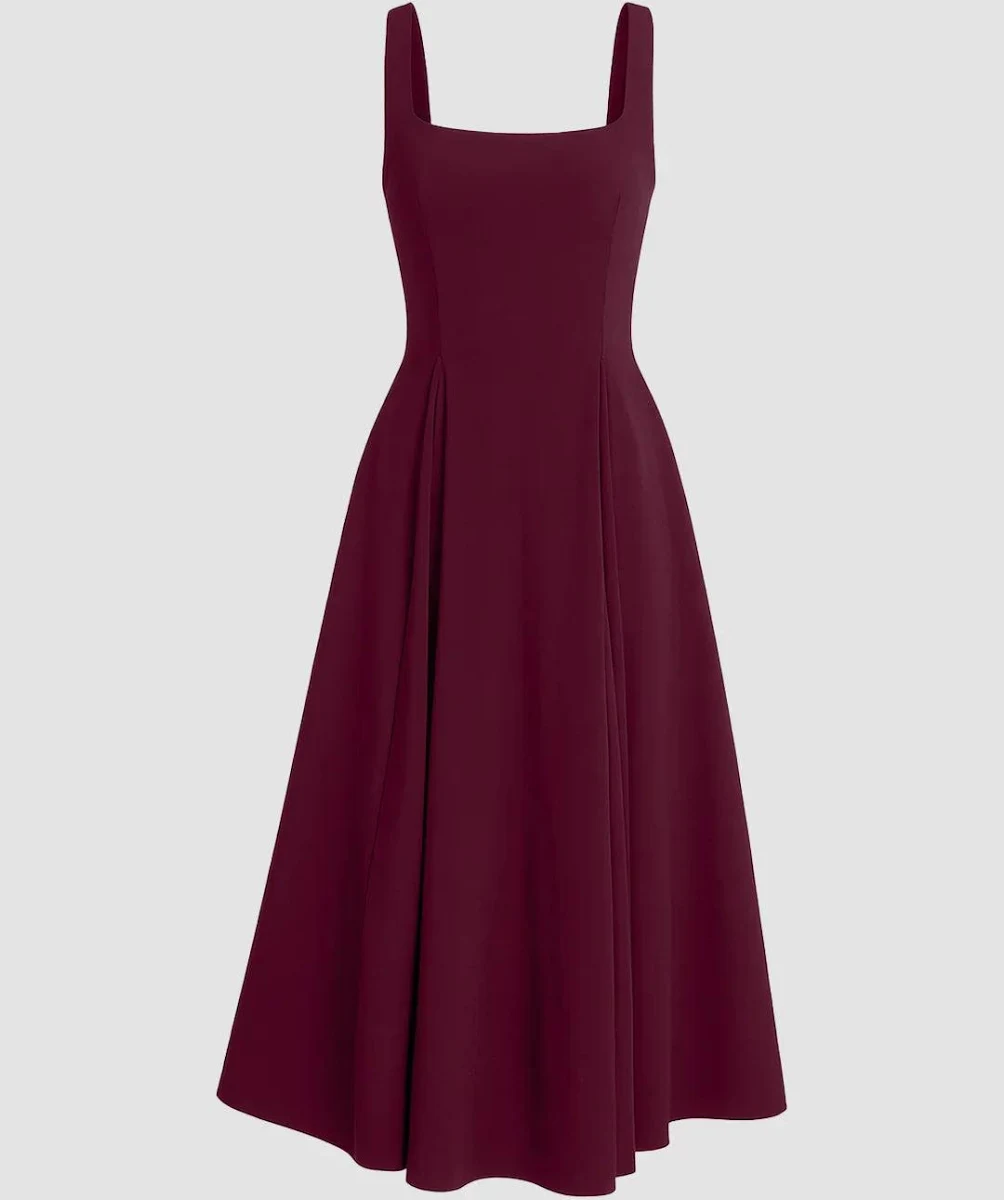

In [172]:
from IPython.display import display
from PIL import Image

img_path = "/content/BeaconAI/datasets/images/img_0001.jpg"

img = Image.open(img_path)

print("Size:", img.size)
display(img)

In [173]:
img_0001_conversations = [

    # 1. Visual understanding
    (
        "Describe this dress.",
        "This is a sleeveless deep burgundy dress with wide shoulder straps, "
        "a fitted bodice, a defined waist, and a dramatically flared skirt. "
        "It has a clean solid-color design with vertical folds or pleats "
        "visible through the skirt."
    ),

    # 2. Fashion analysis
    (
        "What are the most noticeable design elements?",
        "The strongest design elements are the fitted bodice, defined waist, "
        "wide shoulder straps, and the contrast between the structured upper "
        "body and the wide flared skirt. The deep burgundy color also gives "
        "the dress a rich and elegant appearance."
    ),

    # 3. Style modification
    (
        "How could I make this dress look more gothic?",
        "Keep the fitted bodice and flared silhouette, but shift the deep "
        "burgundy toward a darker wine or near-black tone. You could also "
        "introduce subtle gothic details such as darker hardware, lace "
        "accents, or understated Victorian-inspired detailing."
    ),

    # 4. Constraint preservation
    (
        "Keep the silhouette unchanged but make the dress black.",
        "Keep the fitted bodice, defined waist, wide straps, and flared skirt "
        "exactly as they are, while changing the deep burgundy color to black. "
        "The solid-color appearance should remain unchanged."
    ),

    # 5. Multi-turn refinement
    (
        "Describe this dress.",
        "This is a sleeveless deep burgundy dress with wide shoulder straps, "
        "a fitted bodice, a defined waist, and a strongly flared skirt with "
        "visible vertical folds."
    ),
    (
        "Make it suitable for a formal evening event.",
        "Keep the existing silhouette but give it a more formal evening "
        "character through a richer, more refined appearance and understated "
        "accessories such as elegant jewelry and dress shoes."
    ),
    (
        "Don't change the silhouette or color.",
        "Keep the original deep burgundy color, fitted bodice, defined waist, "
        "wide straps, and flared skirt unchanged. Only the styling should be "
        "adjusted for the formal evening setting."
    )
]

In [174]:
example_0001 = create_beacon_example(
    image_name="img_0001.jpg",
    conversations=img_0001_conversations,
    capabilities=[
        "visual_understanding",
        "fashion_analysis",
        "style_modification",
        "constraint_preservation",
        "multi_turn_reasoning"
    ]
)

print(json.dumps(example_0001, indent=2))

{
  "image": "img_0001.jpg",
  "messages": [
    {
      "role": "system",
      "content": "You are Beacon AI, an expert fashion designer, fashion stylist, clothing analyst, and customization assistant."
    },
    {
      "role": "user",
      "content": [
        {
          "type": "image"
        },
        {
          "type": "text",
          "text": "Describe this dress."
        }
      ]
    },
    {
      "role": "assistant",
      "content": "This is a sleeveless deep burgundy dress with wide shoulder straps, a fitted bodice, a defined waist, and a dramatically flared skirt. It has a clean solid-color design with vertical folds or pleats visible through the skirt."
    },
    {
      "role": "user",
      "content": [
        {
          "type": "image"
        },
        {
          "type": "text",
          "text": "What are the most noticeable design elements?"
        }
      ]
    },
    {
      "role": "assistant",
      "content": "The strongest design elements are t

In [175]:
with open(TRAIN_FILE, "a") as f:
    f.write(json.dumps(example_0001) + "\n")

print("Saved:", TRAIN_FILE)

Saved: /content/BeaconAI/datasets/annotations/pilot_train.jsonl


In [176]:
with open(TRAIN_FILE, "r") as f:
    data = [json.loads(line) for line in f]

print("Training examples:", len(data))
print("First image:", data[0]["image"])
print("Messages:", len(data[0]["messages"]))

Training examples: 3
First image: /content/BeaconAI/datasets/images/dress0001.jpg
Messages: 7


In [177]:
img_0002_conversations = [

    # 1 — Visual understanding
    (
        "Describe this dress.",
        "This is a fitted black midi dress with a sleeveless design, "
        "wide shoulder straps, and a simple square-like neckline. "
        "It follows the body closely through the torso and hips and "
        "extends to around mid-calf, with a visible slit near the lower side."
    ),

    # 2 — Fashion analysis
    (
        "What makes this dress visually distinctive?",
        "Its strongest feature is its clean, body-hugging silhouette. "
        "The solid black color, minimal detailing, sleeveless construction, "
        "and lower slit create a sleek and understated appearance."
    ),

    # 3 — Modification
    (
        "How could I make this dress look more dramatic?",
        "You could preserve the fitted midi silhouette while introducing "
        "a stronger visual element, such as a deeper color contrast, "
        "a more pronounced slit, subtle draping, or statement accessories."
    ),

    # 4 — Constraint preservation
    (
        "Change the dress to burgundy but keep its silhouette and length unchanged.",
        "Change the black color to a deep burgundy while preserving the "
        "body-hugging silhouette, sleeveless construction, and midi length. "
        "The existing proportions and overall structure should remain unchanged."
    ),

    # 5 — Multi-turn refinement
    (
        "Describe this dress.",
        "This is a sleek, fitted black midi dress with wide shoulder straps, "
        "a simple neckline, a body-hugging silhouette, and a visible lower slit."
    ),

    (
        "Make it appropriate for a formal evening event.",
        "Keep the fitted midi silhouette but style it for a formal evening "
        "setting with refined accessories, elegant footwear, and understated "
        "jewelry."
    ),

    (
        "Keep the dress itself unchanged. Only modify the styling.",
        "Keep the black dress, its silhouette, length, neckline, straps, "
        "and slit unchanged. Only add or adjust accessories and styling "
        "elements to create the formal evening look."
    )
]

In [178]:
example_0002 = create_beacon_example(
    image_name="img_0002.jpg",
    conversations=img_0002_conversations,
    capabilities=[
        "visual_understanding",
        "fashion_analysis",
        "style_modification",
        "constraint_preservation",
        "multi_turn_reasoning"
    ]
)

In [179]:
with open(TRAIN_FILE, "a") as f:
    f.write(json.dumps(example_0002) + "\n")

print("img_0002 added successfully.")

img_0002 added successfully.


In [180]:
img_0003_conversations = [

    # 1 — Visual understanding
    (
        "Describe this outfit.",
        "This outfit features a fitted, strapless mini dress with a light "
        "pastel floral pattern. The dress has a straight neckline and "
        "extensive ruching through the bodice and skirt, creating a gathered "
        "texture and close-fitting silhouette. It is paired with tall black boots."
    ),

    # 2 — Fashion analysis
    (
        "What are the most noticeable design elements?",
        "The most noticeable elements are the strapless neckline, pastel floral "
        "print, fitted silhouette, and extensive ruching across the dress. "
        "The tall black boots create a strong contrast with the lighter floral "
        "dress and give the outfit a more contemporary edge."
    ),

    # 3 — Style modification
    (
        "How could I make this outfit look more gothic?",
        "Keep the fitted mini-dress silhouette and ruching, but shift the floral "
        "palette toward darker tones such as black, burgundy, and muted purple. "
        "The existing tall black boots already complement the darker direction, "
        "and additional understated gothic accessories could reinforce the look."
    ),

    # 4 — Constraint preservation
    (
        "Keep the floral pattern and silhouette unchanged but make the outfit more formal.",
        "Keep the pastel floral pattern, fitted silhouette, strapless neckline, "
        "and ruched construction unchanged. Make the outfit more formal through "
        "refined accessories, elegant styling, and more sophisticated footwear "
        "while preserving the dress itself."
    ),

    # 5 — Multi-turn refinement
    (
        "Describe this outfit.",
        "This is a fitted strapless floral mini dress with a straight neckline, "
        "extensive ruching, and a short length. It is styled with tall black boots."
    ),

    (
        "Make it suitable for a night out.",
        "Keep the fitted floral mini dress and its ruched construction, but "
        "emphasize the evening character through the existing black boots, "
        "minimal statement jewelry, and a darker, more polished styling approach."
    ),

    (
        "Keep the dress exactly the same and only change the accessories.",
        "Keep the floral pattern, strapless neckline, fitted silhouette, ruching, "
        "and length unchanged. Only modify the accessories and styling around "
        "the dress to create the desired night-out look."
    )
]

In [181]:
example_0003 = create_beacon_example(
    image_name="img_0003.jpg",
    conversations=img_0003_conversations,
    capabilities=[
        "visual_understanding",
        "fashion_analysis",
        "style_modification",
        "constraint_preservation",
        "multi_turn_reasoning"
    ]
)

In [182]:
with open(TRAIN_FILE, "a") as f:
    f.write(json.dumps(example_0003) + "\n")

print("img_0003 added successfully.")

img_0003 added successfully.


In [183]:
img_0004_conversations = [

    # 1 — Visual understanding
    (
        "Describe this dress.",
        "This is a long black dress with a V-neckline, long voluminous sleeves, "
        "and a defined waist. The skirt flares outward toward the ankles, creating "
        "an A-line silhouette. Small repeated cutout or eyelet-like details are "
        "visible across the surface of the dress."
    ),

    # 2 — Fashion analysis
    (
        "What are the most noticeable design elements?",
        "The most noticeable elements are the long voluminous sleeves, V-neckline, "
        "defined waist, and flowing A-line skirt. The repeated small cutout-like "
        "details add texture to the otherwise solid black design."
    ),

    # 3 — Style modification
    (
        "How could I make this dress look more romantic?",
        "Keep the long silhouette and defined waist, while emphasizing the softer "
        "qualities of the design through delicate accessories, subtle jewelry, "
        "and lighter-toned footwear. The existing textured surface and flowing "
        "skirt already support a romantic direction."
    ),

    # 4 — Constraint preservation
    (
        "Make the dress burgundy but keep the sleeves and silhouette unchanged.",
        "Change the black color to a deep burgundy while preserving the long "
        "voluminous sleeves, V-neckline, defined waist, and flared A-line skirt. "
        "The existing surface detailing should also remain unchanged."
    ),

    # 5 — Multi-turn refinement
    (
        "Describe this dress.",
        "This is a long black dress with a V-neckline, voluminous long sleeves, "
        "a defined waist, and a flowing ankle-length A-line skirt with small "
        "repeated cutout-like details."
    ),

    (
        "Make it appropriate for a formal evening event.",
        "Keep the long black silhouette and defined waist, but elevate the styling "
        "with refined jewelry, elegant footwear, and understated accessories. "
        "The flowing skirt and textured surface can remain the main visual features."
    ),

    (
        "Keep the dress itself unchanged. Only change the styling.",
        "Keep the black color, V-neckline, long sleeves, defined waist, flowing "
        "skirt, length, and surface detailing unchanged. Only modify the "
        "accessories and footwear to create the formal evening look."
    )
]

In [184]:
example_0004 = create_beacon_example(
    image_name="img_0004.jpg",
    conversations=img_0004_conversations,
    capabilities=[
        "visual_understanding",
        "fashion_analysis",
        "style_modification",
        "constraint_preservation",
        "multi_turn_reasoning"
    ]
)

In [185]:
with open(TRAIN_FILE, "a") as f:
    f.write(json.dumps(example_0004) + "\n")

print("img_0004 added successfully.")

img_0004 added successfully.


In [186]:
img_0005_conversations = [

    # 1 — Full outfit understanding
    (
        "Describe this outfit.",
        "This is a casual, polished outfit consisting of a white sleeveless top, "
        "an open blue-and-white vertically striped button-up shirt, and high-waisted "
        "light beige trousers. The outfit is completed with black sunglasses, a "
        "structured dark handbag, and simple jewelry."
    ),

    # 2 — Fashion analysis
    (
        "What makes this outfit work visually?",
        "The outfit works through a restrained combination of white, blue, and beige. "
        "The vertical stripes add visual structure to the open shirt, while the "
        "high-waisted beige trousers create a clean lower silhouette. The dark "
        "accessories add contrast without overwhelming the outfit."
    ),

    # 3 — Style modification
    (
        "How could I make this outfit look more streetwear-inspired?",
        "Keep the overall layered structure but make the styling more relaxed. "
        "You could replace the structured handbag with a casual crossbody or "
        "shoulder bag, add chunkier footwear, and use a more oversized version "
        "of the striped shirt while retaining the neutral color palette."
    ),

    # 4 — Constraint preservation
    (
        "Keep the striped shirt and beige trousers unchanged but make the outfit more elegant.",
        "Keep the blue-and-white striped shirt and light beige trousers exactly as "
        "they are. Elevate the outfit through refined accessories, sleek footwear, "
        "and understated jewelry while preserving the existing garments and their colors."
    ),

    # 5 — Multi-turn refinement
    (
        "Describe this outfit.",
        "This is a casual layered outfit with a white sleeveless top, an open "
        "blue-and-white striped shirt, and high-waisted light beige trousers. "
        "Black sunglasses, a dark handbag, and jewelry complete the look."
    ),

    (
        "Make it suitable for a casual summer lunch.",
        "Keep the light color palette and layered structure, but emphasize the "
        "relaxed summer character with lightweight-looking styling, simple "
        "accessories, and comfortable footwear."
    ),

    (
        "Keep all three garments unchanged and only modify the accessories.",
        "Keep the white top, blue-and-white striped shirt, and beige trousers "
        "unchanged. Only modify the handbag, sunglasses, jewelry, and footwear "
        "to create the desired summer-lunch styling."
    )
]

In [187]:
example_0005 = create_beacon_example(
    image_name="img_0005.jpg",
    conversations=img_0005_conversations,
    capabilities=[
        "visual_understanding",
        "outfit_analysis",
        "style_modification",
        "constraint_preservation",
        "accessory_styling",
        "multi_turn_reasoning"
    ]
)

In [188]:
with open(TRAIN_FILE, "a") as f:
    f.write(json.dumps(example_0005) + "\n")

print("img_0005 added successfully.")

img_0005 added successfully.


In [189]:
img_0006_conversations = [

    # 1 — Visual understanding
    (
        "Describe this outfit.",
        "This is a relaxed casual outfit featuring a dark navy-blue oversized "
        "button-up shirt paired with white wide-leg trousers. The shirt is worn "
        "as an outer layer, creating a loose upper silhouette, while the wide "
        "trousers continue the relaxed proportions. A dark handbag, sunglasses, "
        "necklace, and brown-toned footwear complete the look."
    ),

    # 2 — Fashion analysis
    (
        "What makes this outfit visually balanced?",
        "The outfit balances the darker oversized shirt with the lighter white "
        "trousers. Both pieces have relaxed proportions, while the darker "
        "accessories and footwear provide visual contrast and tie the outfit together."
    ),

    # 3 — Style modification
    (
        "How could I make this outfit look more streetwear-inspired?",
        "Keep the relaxed proportions but emphasize the oversized styling. "
        "You could use chunkier footwear, a more structured streetwear bag, "
        "and additional understated accessories while keeping the navy-and-white "
        "color combination."
    ),

    # 4 — Constraint preservation
    (
        "Keep the white trousers unchanged but make the outfit more colorful.",
        "Keep the white wide-leg trousers exactly as they are. Add color through "
        "the upper layer and accessories, such as a brighter shirt or colorful "
        "bag and footwear, while preserving the relaxed proportions of the outfit."
    ),

    # 5 — Multi-turn refinement
    (
        "Describe this outfit.",
        "This is a relaxed outfit built around an oversized dark navy-blue "
        "button-up shirt and white wide-leg trousers, accessorized with a dark "
        "handbag, sunglasses, necklace, and brown-toned shoes."
    ),

    (
        "Make it suitable for a casual weekend outing.",
        "Keep the relaxed shirt-and-wide-leg-trouser combination, but style it "
        "with comfortable footwear, minimal accessories, and a practical bag "
        "to maintain an effortless weekend aesthetic."
    ),

    (
        "Keep the shirt and trousers unchanged and only modify the accessories.",
        "Keep the dark navy-blue shirt and white wide-leg trousers unchanged. "
        "Only modify the handbag, sunglasses, jewelry, and footwear to create "
        "the casual weekend styling."
    )
]

In [190]:
example_0006 = create_beacon_example(
    image_name="img_0006.jpg",
    conversations=img_0006_conversations,
    capabilities=[
        "visual_understanding",
        "outfit_analysis",
        "style_modification",
        "constraint_preservation",
        "accessory_styling",
        "multi_turn_reasoning"
    ]
)

In [191]:
with open(TRAIN_FILE, "a") as f:
    f.write(json.dumps(example_0006) + "\n")

print("img_0006 added successfully.")

img_0006 added successfully.


In [192]:
img_0007_conversations = [

    # 1 — Visual understanding
    (
        "Describe this outfit.",
        "This outfit features a loose white blouse with long voluminous sleeves, "
        "a rounded neckline, and a gathered waist that creates a softly flared "
        "hem. It is paired with dark reddish-brown ribbed shorts and an orange "
        "patterned head wrap."
    ),

    # 2 — Fashion analysis
    (
        "What are the most noticeable design elements?",
        "The strongest elements are the voluminous sleeves, gathered waist, "
        "softly flared hem, and the contrast between the light blouse and "
        "dark reddish-brown shorts. The orange patterned head wrap adds "
        "another distinct visual accent."
    ),

    # 3 — Style modification
    (
        "How could I make this outfit look more bohemian?",
        "Keep the loose blouse and relaxed proportions, but emphasize the "
        "bohemian character with earthy accessories, layered jewelry, "
        "natural-looking textures, and relaxed footwear. The patterned "
        "head wrap already complements that direction."
    ),

    # 4 — Constraint preservation
    (
        "Keep the blouse unchanged but make the outfit more summery.",
        "Keep the white blouse, its voluminous sleeves, gathered waist, and "
        "flared hem unchanged. Make the overall outfit feel more summery "
        "through lighter accessories, relaxed footwear, and a fresh styling "
        "approach while retaining the reddish-brown shorts."
    ),

    # 5 — Multi-turn refinement
    (
        "Describe this outfit.",
        "This is a relaxed outfit featuring a loose white blouse with "
        "voluminous sleeves and a gathered waist, paired with reddish-brown "
        "ribbed shorts and an orange patterned head wrap."
    ),

    (
        "Make it suitable for a casual beach day.",
        "Keep the relaxed silhouette and light blouse, while styling the "
        "outfit with comfortable sandals, minimal accessories, and other "
        "casual elements suited to a beach setting."
    ),

    (
        "Keep the blouse and shorts unchanged and only modify the accessories.",
        "Keep the white blouse and reddish-brown shorts unchanged, including "
        "their silhouettes and colors. Only modify the headwear, jewelry, "
        "footwear, and other accessories to create the beach-day styling."
    )
]

In [193]:
example_0007 = create_beacon_example(
    image_name="img_0007.jpg",
    conversations=img_0007_conversations,
    capabilities=[
        "visual_understanding",
        "outfit_analysis",
        "style_modification",
        "constraint_preservation",
        "accessory_styling",
        "multi_turn_reasoning"
    ]
)

In [194]:
with open(TRAIN_FILE, "a") as f:
    f.write(json.dumps(example_0007) + "\n")

print("img_0007 added successfully.")

img_0007 added successfully.


In [195]:
img_0008_conversations = [

    # 1 — Visual understanding
    (
        "Describe this outfit.",
        "This is a contemporary casual outfit featuring a relaxed black "
        "T-shirt with a small white graphic on the chest, paired with "
        "cream-colored wide-leg cargo trousers. White sneakers and minimal "
        "jewelry complete the look."
    ),

    # 2 — Fashion analysis
    (
        "What are the main design elements of this outfit?",
        "The main design elements are the oversized black T-shirt, the "
        "wide-leg cream cargo trousers, and the contrast between the dark "
        "top and light trousers. The cargo-style pocket and panel details "
        "add a utility-inspired element, while the white sneakers keep "
        "the outfit casual."
    ),

    # 3 — Style modification
    (
        "How could I make this outfit look more streetwear-inspired?",
        "Keep the relaxed proportions but emphasize the streetwear character "
        "with chunkier sneakers, a more pronounced graphic on the T-shirt, "
        "and accessories such as a crossbody bag or cap. The wide-leg cargo "
        "trousers already provide a strong streetwear foundation."
    ),

    # 4 — Constraint preservation
    (
        "Keep the cargo trousers unchanged but make the outfit more colorful.",
        "Keep the cream cargo trousers, their wide-leg silhouette, and utility "
        "details unchanged. Introduce color through the upper garment, "
        "footwear, or accessories while preserving the relaxed proportions "
        "of the outfit."
    ),

    # 5 — Multi-turn refinement
    (
        "Describe this outfit.",
        "This is a relaxed casual outfit consisting of a black graphic "
        "T-shirt, cream wide-leg cargo trousers, white sneakers, and minimal "
        "jewelry."
    ),

    (
        "Make it suitable for a casual evening outing.",
        "Keep the relaxed black T-shirt and cream cargo trousers, but create "
        "a more polished evening look through cleaner footwear, understated "
        "accessories, and a structured casual jacket or overshirt."
    ),

    (
        "Keep the T-shirt and trousers exactly the same and only change the styling.",
        "Keep the black graphic T-shirt and cream cargo trousers unchanged, "
        "including their colors, proportions, and visible details. Only "
        "modify the footwear, accessories, or additional styling elements."
    )
]

In [196]:
example_0008 = create_beacon_example(
    image_name="img_0008.jpg",
    conversations=img_0008_conversations,
    capabilities=[
        "visual_understanding",
        "outfit_analysis",
        "menswear_analysis",
        "streetwear_analysis",
        "style_modification",
        "constraint_preservation",
        "accessory_styling",
        "multi_turn_reasoning"
    ]
)

In [197]:
with open(TRAIN_FILE, "a") as f:
    f.write(json.dumps(example_0008) + "\n")

print("img_0008 added successfully.")

img_0008 added successfully.


In [198]:
img_0009_conversations = [

    # 1 — Visual understanding
    (
        "Describe this outfit.",
        "This is an oversized streetwear outfit built around a black hoodie "
        "with a large white graphic on the front and loose blue-gray jeans "
        "with bold white graphic markings. A baseball cap, crossbody bag, "
        "chain detail, necklace, rings, and white sneakers complete the look."
    ),

    # 2 — Fashion analysis
    (
        "What makes this outfit strongly streetwear-inspired?",
        "The oversized hoodie, baggy jeans, graphic detailing, baseball cap, "
        "crossbody bag, and relaxed proportions all contribute to a strong "
        "streetwear aesthetic. The black, gray-blue, and white palette keeps "
        "the outfit cohesive despite its bold graphics."
    ),

    # 3 — Style modification
    (
        "How could I make this outfit look more minimal while keeping the streetwear aesthetic?",
        "Keep the oversized proportions and relaxed silhouette, but reduce "
        "the number of visible graphic elements. A plain black hoodie, "
        "cleaner bag, simple cap, and less heavily decorated jeans would "
        "create a more minimal streetwear look."
    ),

    # 4 — Constraint preservation
    (
        "Keep the baggy jeans and oversized silhouette unchanged, but make the outfit more colorful.",
        "Keep the baggy blue-gray jeans, oversized proportions, and relaxed "
        "silhouette unchanged. Introduce color through the hoodie, cap, "
        "sneakers, or accessories while preserving the existing fit and "
        "overall streetwear structure."
    ),

    # 5 — Multi-turn refinement
    (
        "Describe this outfit.",
        "This is a bold oversized streetwear outfit featuring a black graphic "
        "hoodie, loose blue-gray jeans with white graphic details, a baseball "
        "cap, crossbody bag, jewelry, and white sneakers."
    ),

    (
        "Make it more suitable for a fashion-forward streetwear look.",
        "Keep the oversized silhouette but refine the styling with coordinated "
        "accessories, cleaner layering, and deliberate contrast between the "
        "black hoodie, blue-gray denim, and white footwear. The graphic "
        "elements can remain as the main visual statement."
    ),

    (
        "Keep the hoodie and jeans unchanged and only modify the accessories.",
        "Keep the black graphic hoodie and blue-gray graphic jeans exactly "
        "as they are, including their colors, graphics, and oversized fit. "
        "Only modify the cap, bag, jewelry, and footwear to refine the "
        "streetwear styling."
    )
]

In [199]:
example_0009 = create_beacon_example(
    image_name="img_0009.jpg",
    conversations=img_0009_conversations,
    capabilities=[
        "visual_understanding",
        "outfit_analysis",
        "menswear_analysis",
        "streetwear_analysis",
        "graphic_analysis",
        "style_modification",
        "constraint_preservation",
        "accessory_styling",
        "multi_turn_reasoning"
    ]
)

In [200]:
with open(TRAIN_FILE, "a") as f:
    f.write(json.dumps(example_0009) + "\n")

print("img_0009 added successfully.")

img_0009 added successfully.


In [201]:
img_0010_conversations = [

    # 1 — Visual understanding
    (
        "Describe this outfit.",
        "This is a highly expressive streetwear outfit built around an oversized "
        "blue graphic T-shirt layered over a darker long-sleeved top. It is paired "
        "with loose cargo-style trousers covered in colorful graphic and graffiti-like "
        "details. A patterned blue beanie, necklace, and red-and-white sneakers "
        "complete the look."
    ),

    # 2 — Fashion analysis
    (
        "What makes this outfit look maximalist?",
        "The outfit has a maximalist character because several strong visual elements "
        "appear together: the oversized blue graphic T-shirt, colorful decorated "
        "trousers, layered sleeves, patterned beanie, and contrasting footwear. "
        "The combination of multiple colors, graphics, and relaxed proportions creates "
        "a deliberately bold appearance."
    ),

    # 3 — Style modification
    (
        "How could I make this outfit more minimalist without losing its streetwear feel?",
        "Reduce the number of competing graphic elements while keeping the relaxed "
        "streetwear proportions. For example, the colorful trousers could be replaced "
        "with plain cargo trousers, while the oversized T-shirt, beanie, and sneakers "
        "could remain as the main styling elements."
    ),

    # 4 — Constraint preservation
    (
        "Keep the oversized silhouette and colorful trousers unchanged, but make the outfit less busy.",
        "Keep the oversized proportions and the colorful graphic trousers unchanged. "
        "Reduce visual complexity through simpler accessories and a more restrained "
        "layer underneath, allowing the existing trousers and oversized T-shirt to "
        "remain the primary visual elements."
    ),

    # 5 — Multi-turn refinement
    (
        "Describe this outfit.",
        "This is a bold oversized streetwear outfit featuring a blue graphic T-shirt, "
        "a darker long-sleeved layer, colorful decorated cargo-style trousers, a blue "
        "patterned beanie, and red-and-white sneakers."
    ),

    (
        "Push it even further into an experimental streetwear direction.",
        "Keep the oversized silhouette and graphic-heavy character, but emphasize the "
        "experimental direction through unconventional layering, contrasting accessories, "
        "and deliberately mixed colors and textures."
    ),

    (
        "Keep the trousers and T-shirt unchanged.",
        "Keep the colorful trousers and oversized blue graphic T-shirt exactly as they are, "
        "including their colors, graphics, and proportions. Only modify the layering, "
        "accessories, and footwear to push the outfit toward a more experimental direction."
    )
]

In [202]:
example_0010 = create_beacon_example(
    image_name="img_0010.jpg",
    conversations=img_0010_conversations,
    capabilities=[
        "visual_understanding",
        "outfit_analysis",
        "streetwear_analysis",
        "maximalist_style_analysis",
        "graphic_analysis",
        "style_modification",
        "constraint_preservation",
        "layering_analysis",
        "multi_turn_reasoning"
    ]
)

In [203]:
with open(TRAIN_FILE, "a") as f:
    f.write(json.dumps(example_0010) + "\n")

print("img_0010 added successfully.")

img_0010 added successfully.


In [204]:
img_0011_conversations = [

    # 1 — Visual understanding
    (
        "Describe this dress.",
        "This is a floor-length black dress with a fitted silhouette through "
        "the bodice and hips and a flowing skirt. It has long, dramatically "
        "flared bell sleeves and a simple rounded neckline. Layered dark "
        "necklaces and dark footwear reinforce the overall gothic aesthetic."
    ),

    # 2 — Fashion analysis
    (
        "What gives this dress its gothic character?",
        "The monochromatic black color, floor-length silhouette, dramatic "
        "bell sleeves, fitted shape, and dark layered jewelry all contribute "
        "to its gothic character. The exaggerated sleeves are particularly "
        "strong as a visual statement."
    ),

    # 3 — Style modification
    (
        "How could I make this dress look more Victorian-inspired?",
        "Keep the long black silhouette and dramatic sleeves, while adding "
        "subtle Victorian-inspired elements such as a more ornate necklace, "
        "decorative detailing around the neckline, or vintage-inspired "
        "accessories. The existing silhouette already supports the direction."
    ),

    # 4 — Constraint preservation
    (
        "Keep the silhouette and black color unchanged but make it look more elegant.",
        "Keep the black color, fitted bodice, flowing floor-length skirt, and "
        "dramatically flared sleeves unchanged. Refine the overall appearance "
        "through understated jewelry, polished footwear, and restrained styling "
        "without altering the dress itself."
    ),

    # 5 — Multi-turn refinement
    (
        "Describe this dress.",
        "This is a dramatic floor-length black dress with a fitted bodice, "
        "flowing skirt, long flared bell sleeves, and a rounded neckline. "
        "Dark layered jewelry completes the gothic-inspired styling."
    ),

    (
        "Make it more dramatic for a gothic evening event.",
        "Preserve the dramatic black silhouette and exaggerated sleeves while "
        "emphasizing the gothic character through layered dark jewelry, "
        "statement footwear, and other restrained dark accessories."
    ),

    (
        "Keep the dress exactly the same. Only change the accessories.",
        "Keep the black color, neckline, fitted bodice, floor-length skirt, "
        "and exaggerated bell sleeves exactly unchanged. Only modify the "
        "jewelry, footwear, and other accessories."
    )
]

In [205]:
example_0011 = create_beacon_example(
    image_name="img_0011.jpg",
    conversations=img_0011_conversations,
    capabilities=[
        "visual_understanding",
        "fashion_analysis",
        "gothic_style_analysis",
        "alternative_fashion_analysis",
        "style_modification",
        "constraint_preservation",
        "accessory_styling",
        "multi_turn_reasoning"
    ]
)

In [206]:
with open(TRAIN_FILE, "a") as f:
    f.write(json.dumps(example_0011) + "\n")

print("img_0011 added successfully.")

img_0011 added successfully.


In [207]:
img_0012_conversations = [

    # 1 — Visual understanding
    (
        "Describe this outfit.",
        "This is an urban layered outfit centered around a long, oversized "
        "black glossy-looking coat worn over a black hoodie. It is paired "
        "with relaxed blue jeans, dark footwear, and a large black backpack. "
        "The elongated outer layer creates a strong oversized silhouette."
    ),

    # 2 — Fashion analysis
    (
        "What are the key styling elements of this outfit?",
        "The main styling elements are the long oversized coat, layered black "
        "hoodie, relaxed jeans, and large backpack. The dark monochromatic "
        "upper half creates a strong visual block, while the blue denim "
        "introduces contrast. The long outer layer also gives the outfit "
        "a dramatic urban silhouette."
    ),

    # 3 — Style modification
    (
        "How could I make this outfit look more avant-garde?",
        "Keep the oversized proportions and long outer layer, but emphasize "
        "the experimental character through more exaggerated layering, "
        "asymmetric accessories, unconventional proportions, or contrasting "
        "textures. A mostly monochromatic palette would preserve the dark "
        "urban character."
    ),

    # 4 — Constraint preservation
    (
        "Keep the long coat and relaxed jeans unchanged, but make the outfit lighter.",
        "Keep the long dark coat and relaxed blue jeans exactly as they are, "
        "including their silhouettes. Introduce lighter tones through the "
        "hoodie, footwear, backpack, or other accessories while preserving "
        "the existing proportions."
    ),

    # 5 — Multi-turn refinement
    (
        "Describe this outfit.",
        "This is a dark urban outfit featuring a long oversized coat over a "
        "black hoodie, relaxed blue jeans, dark footwear, and a large black "
        "backpack."
    ),

    (
        "Make it suitable for a modern city evening.",
        "Keep the long coat, hoodie, and relaxed jeans, but refine the look "
        "with cleaner footwear, understated accessories, and a structured "
        "bag while maintaining the dark urban aesthetic."
    ),

    (
        "Keep the coat and jeans exactly the same and only modify the styling.",
        "Keep the long dark coat and relaxed blue jeans unchanged, including "
        "their colors, proportions, and silhouettes. Only modify the hoodie, "
        "footwear, backpack, and accessories to refine the city-evening look."
    )
]

In [208]:
example_0012 = create_beacon_example(
    image_name="img_0012.jpg",
    conversations=img_0012_conversations,
    capabilities=[
        "visual_understanding",
        "outfit_analysis",
        "menswear_analysis",
        "outerwear_analysis",
        "layering_analysis",
        "avant_garde_style_analysis",
        "style_modification",
        "constraint_preservation",
        "multi_turn_reasoning"
    ]
)

In [209]:
with open(TRAIN_FILE, "a") as f:
    f.write(json.dumps(example_0012) + "\n")

print("img_0012 added successfully.")

img_0012 added successfully.


In [210]:
img_0013_conversations = [

    # 1 — Visual understanding
    (
        "Describe this outfit.",
        "This is a formal menswear outfit featuring a dark two-piece suit "
        "with a structured single-breasted jacket and matching tailored "
        "trousers. It is styled with a light dress shirt, gray-toned tie, "
        "white pocket square, and black dress shoes."
    ),

    # 2 — Tailoring analysis
    (
        "What gives this outfit its formal and polished appearance?",
        "The coordinated dark suit, structured jacket, tailored trousers, "
        "dress shirt, necktie, pocket square, and polished dark footwear "
        "create a cohesive formal appearance. The restrained color palette "
        "also contributes to the clean and sophisticated styling."
    ),

    # 3 — Style modification
    (
        "How could I make this suit look more contemporary?",
        "Keep the tailored foundation but introduce a more contemporary "
        "direction through updated accessories, a less traditional shirt-and-tie "
        "combination, or subtly stronger contrast. The clean suit silhouette "
        "can remain the central element."
    ),

    # 4 — Constraint preservation
    (
        "Change the suit to navy but keep its tailoring and proportions unchanged.",
        "Change the dark suit to navy while preserving the jacket structure, "
        "matching trousers, tailored proportions, and overall silhouette. "
        "The shirt, tie, pocket square, and footwear can remain coordinated "
        "with the new suit color."
    ),

    # 5 — Multi-turn refinement
    (
        "Describe this outfit.",
        "This is a classic formal outfit consisting of a dark tailored suit, "
        "light dress shirt, gray-toned tie, white pocket square, and black "
        "dress shoes."
    ),

    (
        "Make it suitable for a formal evening event but slightly more distinctive.",
        "Keep the tailored suit as the foundation while introducing more "
        "distinctive accessories, such as a refined tie or pocket-square "
        "combination and carefully coordinated formal footwear."
    ),

    (
        "Don't change the suit itself.",
        "Keep the jacket and matching trousers unchanged, including their "
        "dark color, tailored proportions, and overall silhouette. Only "
        "modify the shirt, tie, pocket square, footwear, or other accessories "
        "to create the more distinctive evening styling."
    )
]

In [211]:
example_0013 = create_beacon_example(
    image_name="img_0013.jpg",
    conversations=img_0013_conversations,
    capabilities=[
        "visual_understanding",
        "outfit_analysis",
        "menswear_analysis",
        "formalwear_analysis",
        "tailoring_analysis",
        "style_modification",
        "constraint_preservation",
        "accessory_styling",
        "multi_turn_reasoning"
    ]
)

In [212]:
with open(TRAIN_FILE, "a") as f:
    f.write(json.dumps(example_0013) + "\n")

print("img_0013 added successfully.")

img_0013 added successfully.


In [213]:
img_0014_conversations = [

    (
        "Describe this dress.",
        "This is a polished dark navy-blue short-sleeve dress with a V-neckline, "
        "a fitted structured silhouette, and an above-knee length. A matching "
        "waist belt with a metallic buckle defines the waist, while large hoop "
        "earrings complete the look."
    ),

    (
        "What makes this dress suitable for professional wear?",
        "The clean silhouette, restrained dark color, modest V-neckline, "
        "short sleeves, and structured waist create a polished professional "
        "appearance. The simple design also makes it easy to style for an "
        "office environment."
    ),

    (
        "How could I make this dress look more suitable for an evening event?",
        "Keep the fitted silhouette and defined waist, but elevate the styling "
        "with statement jewelry, refined heels, and a more sophisticated "
        "evening bag. The dark color already provides a strong foundation."
    ),

    (
        "Keep the dress unchanged but make the styling more minimal.",
        "Keep the dress, its dark color, fitted silhouette, V-neckline, short "
        "sleeves, and waist belt unchanged. Simplify the accessories by using "
        "small understated jewelry and clean footwear."
    ),

    (
        "Describe the overall style of this outfit.",
        "The overall style is polished professional dressing with a feminine "
        "and structured silhouette. The defined waist and dark monochromatic "
        "color give the outfit a refined appearance."
    ),

    (
        "Make this look more contemporary without changing the dress.",
        "Keep the dress completely unchanged and update only the styling. "
        "Contemporary accessories, modern footwear, and a structured handbag "
        "could give the outfit a more current appearance."
    ),

    (
        "Keep the belt and dress exactly the same. Change only the accessories.",
        "Keep the dark dress, fitted silhouette, V-neckline, short sleeves, "
        "and matching waist belt exactly unchanged. Only modify the earrings, "
        "footwear, handbag, or other accessories."
    )
]

In [214]:
example_0014 = create_beacon_example(
    image_name="img_0014.jpg",
    conversations=img_0014_conversations,
    capabilities=[
        "visual_understanding",
        "dress_analysis",
        "womenswear_analysis",
        "professionalwear_analysis",
        "silhouette_analysis",
        "style_modification",
        "constraint_preservation",
        "accessory_styling",
        "multi_turn_reasoning"
    ]
)

In [215]:
with open(TRAIN_FILE, "a") as f:
    f.write(json.dumps(example_0014) + "\n")

print("img_0014 added successfully.")

img_0014 added successfully.


In [216]:
img_0015_conversations = [

    (
        "Describe this outfit.",
        "This is a traditional Indian lehenga ensemble featuring a fitted purple "
        "short-sleeve choli, a long voluminous flared lehenga skirt, and a matching "
        "purple dupatta. The outfit is decorated with extensive light-colored "
        "floral and ornamental patterns and embellished borders. Statement earrings "
        "and a necklace complete the festive look."
    ),

    (
        "What are the main components of this outfit?",
        "The outfit consists of three main components: a fitted choli, a long flared "
        "lehenga skirt, and a matching dupatta. Together they create a coordinated "
        "traditional Indian occasionwear ensemble."
    ),

    (
        "What makes this outfit suitable for a festive occasion?",
        "The coordinated purple palette, voluminous skirt, decorative patterns, "
        "ornamental borders, matching dupatta, and statement jewelry give the outfit "
        "a highly festive and celebratory appearance."
    ),

    (
        "How could I make this lehenga look more contemporary?",
        "Keep the coordinated lehenga structure but modernize the styling through "
        "simpler jewelry, contemporary footwear, or a more minimal treatment of "
        "the dupatta. The traditional silhouette can remain the foundation."
    ),

    (
        "Keep the purple lehenga unchanged but make the styling more minimal.",
        "Keep the purple choli, flared lehenga skirt, matching dupatta, colors, "
        "patterns, and decorative borders unchanged. Simplify only the accessories "
        "and styling so that the ensemble feels less visually elaborate."
    ),

    (
        "Describe the overall aesthetic.",
        "The overall aesthetic is traditional, ornate, and festive, with a strong "
        "Indian occasionwear character. The rich purple palette and coordinated "
        "decorative elements create a cohesive statement look."
    ),

    (
        "Keep the lehenga and choli exactly the same and change only the dupatta styling.",
        "Keep the purple choli and lehenga skirt unchanged, including their colors, "
        "patterns, proportions, and decorative borders. Only alter the way the "
        "matching dupatta is draped or styled."
    )
]

In [217]:
example_0015 = create_beacon_example(
    image_name="img_0015.jpg",
    conversations=img_0015_conversations,
    capabilities=[
        "visual_understanding",
        "womenswear_analysis",
        "traditional_fashion_analysis",
        "indian_fashion_analysis",
        "ensemble_analysis",
        "garment_component_analysis",
        "style_modification",
        "constraint_preservation",
        "accessory_styling",
        "multi_turn_reasoning"
    ]
)

In [218]:
with open(TRAIN_FILE, "a") as f:
    f.write(json.dumps(example_0015) + "\n")

print("img_0015 added successfully.")

img_0015 added successfully.


In [219]:
img_0016_conversations = [

    # 1 — Visual understanding
    (
        "Describe this outfit.",
        "This is a contemporary Indian festive ensemble in a coral-red color. "
        "It features a fitted cropped blouse with ornate decorative detailing, "
        "a long flowing draped lower garment, and a matching sheer drape with "
        "a decorated border."
    ),

    # 2 — Garment analysis
    (
        "What are the main elements of this outfit?",
        "The main elements are the fitted cropped blouse, the flowing draped "
        "lower garment, and the long sheer red drape. The coordinated color "
        "palette and decorative detailing visually connect the separate pieces."
    ),

    # 3 — Style analysis
    (
        "What makes this look feel contemporary rather than purely traditional?",
        "The cropped fitted blouse, exposed midriff, streamlined styling, and "
        "flowing draped silhouette give the traditional-inspired ensemble a "
        "contemporary character. The ornate detailing and drape retain a strong "
        "Indian festive influence."
    ),

    # 4 — Style modification
    (
        "How could I make this outfit look more modern?",
        "Keep the flowing draped silhouette and Indian-inspired character, but "
        "modernize the styling through simpler accessories, contemporary "
        "footwear, and a cleaner treatment of the drape."
    ),

    # 5 — Constraint preservation
    (
        "Keep the red outfit unchanged but make the styling more minimal.",
        "Keep the coral-red blouse, flowing lower garment, sheer drape, "
        "decorative details, and overall silhouette unchanged. Simplify only "
        "the accessories and styling to create a cleaner appearance."
    ),

    # 6 — Occasion transformation
    (
        "How could I style this for a festive evening event?",
        "The existing coral-red ensemble already works well for a festive "
        "evening setting. Refine it with elegant statement jewelry, polished "
        "footwear, and a carefully arranged drape while keeping the outfit "
        "itself intact."
    ),

    # 7 — Multi-turn constraint reasoning
    (
        "Keep the blouse and lower garment exactly the same and only change "
        "the drape styling.",
        "Keep the cropped blouse and flowing lower garment unchanged, including "
        "their color, decorative details, and silhouette. Only alter the way "
        "the sheer red drape is arranged or worn."
    )
]

In [220]:
example_0016 = create_beacon_example(
    image_name="img_0016.jpg",
    conversations=img_0016_conversations,
    capabilities=[
        "visual_understanding",
        "womenswear_analysis",
        "indian_fashion_analysis",
        "traditional_fashion_analysis",
        "fusion_fashion_analysis",
        "garment_component_analysis",
        "drape_analysis",
        "style_modification",
        "constraint_preservation",
        "multi_turn_reasoning"
    ]
)

In [221]:
with open(TRAIN_FILE, "a") as f:
    f.write(json.dumps(example_0016) + "\n")

print("img_0016 added successfully.")

img_0016 added successfully.


In [222]:
img_0017_conversations = [

    (
        "Describe this outfit.",
        "This is a futuristic black full-body outfit with a highly fitted "
        "silhouette and extensive segmented panel-like detailing. The outfit "
        "has a structured, corset-like upper section, fitted legs, dark gloves, "
        "and tall black boots."
    ),

    (
        "What makes this outfit look futuristic?",
        "The extremely fitted silhouette, segmented panel details, structured "
        "upper body, monochromatic black palette, gloves, and tall boots create "
        "a futuristic and highly stylized appearance."
    ),

    (
        "What fashion aesthetic does this outfit suggest?",
        "The outfit suggests a futuristic, cyberpunk-inspired, and alternative "
        "fashion aesthetic. Its structured panels, dark palette, and body-contouring "
        "silhouette create a strong technological and dramatic visual character."
    ),

    (
        "How could I make this outfit more wearable for everyday fashion?",
        "Keep the futuristic influence but reduce the visual intensity by "
        "incorporating individual elements into a conventional outfit. For "
        "example, a structured black top, fitted trousers, or technical-looking "
        "boots could preserve the aesthetic without using the full-body design."
    ),

    (
        "Keep the black futuristic outfit unchanged but make the styling less dramatic.",
        "Keep the black full-body outfit, fitted silhouette, panel details, "
        "gloves, and boots unchanged. Reduce the dramatic effect only through "
        "simpler posing and restrained styling without altering the garment."
    ),

    (
        "How could I adapt this aesthetic into streetwear?",
        "Translate the futuristic elements into oversized or layered streetwear "
        "pieces using dark technical-looking fabrics, utility details, structured "
        "outerwear, and chunky footwear while keeping the predominantly black palette."
    ),

    (
        "Keep the outfit exactly the same and only change the accessories.",
        "Keep the black full-body garment, its fitted silhouette, structured "
        "panels, and all visible garment details unchanged. Only modify the "
        "gloves, footwear, or other accessories."
    )
]

In [223]:
example_0017 = create_beacon_example(
    image_name="img_0017.jpg",
    conversations=img_0017_conversations,
    capabilities=[
        "visual_understanding",
        "fashion_analysis",
        "alternative_fashion_analysis",
        "futuristic_style_analysis",
        "cyberpunk_style_analysis",
        "silhouette_analysis",
        "technical_detail_analysis",
        "style_modification",
        "constraint_preservation",
        "multi_turn_reasoning"
    ]
)

In [224]:
with open(TRAIN_FILE, "a") as f:
    f.write(json.dumps(example_0017) + "\n")

print("img_0017 added successfully.")

img_0017 added successfully.


In [225]:
img_0018_conversations = [

    (
        "Describe this outfit.",
        "This outfit combines a structured dark pinstriped jacket with a "
        "yellow-and-black plaid inner layer and blue jeans featuring bold "
        "dark graphic detailing. A cap, dark sunglasses, belt, and light-colored "
        "shoes complete the look."
    ),

    (
        "What makes this outfit different from traditional formal tailoring?",
        "Although the structured pinstriped jacket gives the outfit a tailored "
        "foundation, the plaid inner layer, graphic denim, cap, sunglasses, "
        "and relaxed proportions make it much more casual and fashion-forward "
        "than conventional formal suiting."
    ),

    (
        "How could I make this outfit more suitable for everyday wear?",
        "Keep the structured jacket as the main tailored element, but simplify "
        "the styling with a plain inner layer, cleaner jeans without prominent "
        "graphics, and understated footwear and accessories."
    ),

    (
        "How could I make this look more fashion-forward without changing the jacket?",
        "Keep the structured pinstriped jacket unchanged and build contrast "
        "through the inner layer, graphic denim, statement accessories, and "
        "deliberately mixed textures. The contrast between tailoring and casual "
        "pieces is already a strong fashion statement."
    ),

    (
        "Describe the overall styling direction.",
        "The outfit takes a runway-inspired approach to street tailoring by "
        "combining a structured pinstriped jacket with plaid layering and "
        "graphic denim. The cap and sunglasses add a youthful streetwear edge."
    ),

    (
        "Keep the jacket and jeans unchanged but make the outfit more minimal.",
        "Keep the dark pinstriped jacket and graphic blue jeans exactly unchanged, "
        "including their colors, proportions, and visible details. Simplify the "
        "inner layer and accessories to reduce the overall visual complexity."
    ),

    (
        "Keep the outfit but replace the streetwear feel with a smart-casual feel.",
        "Preserve the jacket and jeans while replacing the cap, sunglasses, and "
        "other strongly casual elements with cleaner accessories and footwear. "
        "A simple refined inner layer would also make the combination more "
        "smart-casual."
    )
]

In [226]:
example_0018 = create_beacon_example(
    image_name="img_0018.jpg",
    conversations=img_0018_conversations,
    capabilities=[
        "visual_understanding",
        "outfit_analysis",
        "menswear_analysis",
        "tailoring_analysis",
        "streetwear_analysis",
        "runway_fashion_analysis",
        "layering_analysis",
        "style_modification",
        "constraint_preservation",
        "multi_turn_reasoning"
    ]
)

In [227]:
with open(TRAIN_FILE, "a") as f:
    f.write(json.dumps(example_0018) + "\n")

print("img_0018 added successfully.")

img_0018 added successfully.


In [228]:
img_0019_conversations = [

    (
        "Describe this outfit.",
        "This is an elaborate blue-and-white couture gown with dense ornamental "
        "patterns and a highly sculptural silhouette. The sleeveless fitted bodice "
        "transitions into a dramatically layered skirt with extended trailing "
        "fabric. A large architectural headpiece and long decorative elements "
        "complete the theatrical runway presentation."
    ),

    (
        "What makes this outfit look like couture?",
        "The exaggerated silhouette, extensive decorative patterning, dramatic "
        "volume, sculptural construction, elaborate headpiece, and trailing fabric "
        "create a highly theatrical couture appearance. The outfit is designed "
        "to create visual impact rather than a simple everyday silhouette."
    ),

    (
        "What are the strongest visual elements of this look?",
        "The strongest elements are the blue-and-white ornamental pattern, the "
        "dramatically layered skirt, the extended train-like fabric, and the "
        "large architectural headpiece. Together they create a strong visual "
        "hierarchy and a highly theatrical silhouette."
    ),

    (
        "How could I make this outfit more wearable while keeping its couture inspiration?",
        "Keep the blue-and-white palette and ornamental character, but simplify "
        "the silhouette by reducing the amount of layered volume and trailing "
        "fabric. A more streamlined skirt and a smaller statement accessory "
        "could translate the couture concept into a more wearable outfit."
    ),

    (
        "Keep the color palette and patterns unchanged but make the silhouette simpler.",
        "Keep the blue-and-white color palette and ornamental patterns unchanged. "
        "Reduce the exaggerated volume and trailing fabric to create a cleaner, "
        "more streamlined silhouette while retaining the decorative character."
    ),

    (
        "Describe the overall fashion aesthetic.",
        "The overall aesthetic is theatrical couture with an ornate, highly "
        "decorative character. The sculptural silhouette, dramatic headpiece, "
        "and extended fabric create a strong runway-focused presentation."
    ),

    (
        "Keep the gown unchanged and only modify the head styling.",
        "Keep the blue-and-white gown, its patterns, layered construction, "
        "silhouette, and trailing fabric completely unchanged. Only modify "
        "the headpiece and other head styling elements."
    )
]

In [229]:
example_0019 = create_beacon_example(
    image_name="img_0019.jpg",
    conversations=img_0019_conversations,
    capabilities=[
        "visual_understanding",
        "womenswear_analysis",
        "couture_analysis",
        "runway_fashion_analysis",
        "silhouette_analysis",
        "pattern_analysis",
        "sculptural_fashion_analysis",
        "cultural_style_analysis",
        "style_modification",
        "constraint_preservation",
        "multi_turn_reasoning"
    ]
)

In [230]:
with open(TRAIN_FILE, "a") as f:
    f.write(json.dumps(example_0019) + "\n")

print("img_0019 added successfully.")

img_0019 added successfully.


In [231]:
img_0020_conversations = [

    (
        "Describe this outfit.",
        "This outfit uses a monochromatic light-neutral palette with a long "
        "light-colored coat layered over a structured vest-like piece and "
        "wide-leg trousers. A large tote and dark pointed footwear provide "
        "contrast, while the relaxed proportions create an elongated silhouette."
    ),

    (
        "What makes this outfit look sophisticated?",
        "The restrained neutral palette, clean layering, structured outerwear, "
        "wide-leg proportions, and minimal use of contrasting accessories give "
        "the outfit a polished and sophisticated appearance."
    ),

    (
        "What type of silhouette does this outfit create?",
        "The outfit creates an elongated, relaxed silhouette through the long "
        "outer layer and wide-leg trousers. The oversized proportions give the "
        "look a contemporary and effortless character."
    ),

    (
        "How could I recreate this aesthetic for everyday wear?",
        "Use a long neutral coat or jacket over a simple structured top, pair it "
        "with relaxed wide-leg trousers, and keep the color palette within cream, "
        "beige, ivory, or soft gray. A structured bag and simple dark footwear "
        "can add definition."
    ),

    (
        "How could I make this outfit less oversized?",
        "Keep the monochromatic neutral palette and layered approach, but replace "
        "the oversized outerwear with a more fitted coat and choose trousers with "
        "a straighter or moderately relaxed leg."
    ),

    (
        "Describe the styling direction of this look.",
        "The styling takes a minimalist contemporary approach to tailoring. "
        "Layered neutral garments, elongated proportions, and restrained "
        "accessories create a refined editorial appearance."
    ),

    (
        "Keep the color palette unchanged but make the outfit more casual.",
        "Keep the ivory, cream, and beige palette unchanged while replacing the "
        "structured tailoring with softer everyday pieces and more relaxed "
        "footwear. Preserve the layered monochromatic character."
    )
]

In [232]:
example_0020 = create_beacon_example(
    image_name="img_0020.jpg",
    conversations=img_0020_conversations,
    capabilities=[
        "visual_understanding",
        "womenswear_analysis",
        "minimalist_fashion_analysis",
        "tailoring_analysis",
        "layering_analysis",
        "silhouette_analysis",
        "monochromatic_styling",
        "luxury_style_analysis",
        "style_modification",
        "constraint_preservation",
        "multi_turn_reasoning"
    ]
)

In [233]:
with open(TRAIN_FILE, "a") as f:
    f.write(json.dumps(example_0020) + "\n")

print("img_0020 added successfully.")

img_0020 added successfully.


In [234]:
# ============================================================
# BEACON AI — FINAL DATASET INTEGRITY CHECK
# ============================================================

import os
import json
from PIL import Image

IMAGE_DIR = "/content/BeaconAI/datasets/images"
TRAIN_FILE = "/content/BeaconAI/datasets/annotations/train.jsonl"

print("=" * 60)
print("BEACON AI DATASET INTEGRITY CHECK")
print("=" * 60)

# ------------------------------------------------------------
# 1. Check files exist
# ------------------------------------------------------------

print("\n[1] PATH CHECK")

print("Image directory exists:", os.path.exists(IMAGE_DIR))
print("Annotation file exists:", os.path.exists(TRAIN_FILE))


# ------------------------------------------------------------
# 2. Collect images
# ------------------------------------------------------------

image_files = sorted([
    f for f in os.listdir(IMAGE_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
])

print("\n[2] IMAGE CHECK")
print("Total image files:", len(image_files))

for f in image_files:
    print(" ", f)


# ------------------------------------------------------------
# 3. Read JSONL
# ------------------------------------------------------------

print("\n[3] ANNOTATION CHECK")

records = []

with open(TRAIN_FILE, "r", encoding="utf-8") as f:
    for line_no, line in enumerate(f, 1):

        line = line.strip()

        if not line:
            continue

        try:
            records.append(json.loads(line))
        except json.JSONDecodeError as e:
            print(f"❌ Invalid JSON on line {line_no}: {e}")

print("Total annotation records:", len(records))


# ------------------------------------------------------------
# 4. Inspect record structure
# ------------------------------------------------------------

print("\n[4] RECORD STRUCTURE")

if records:
    print("First record keys:")
    print(records[0].keys())

    print("\nFirst record:")
    print(json.dumps(records[0], indent=2, ensure_ascii=False)[:3000])


# ------------------------------------------------------------
# 5. Extract image names
# ------------------------------------------------------------

def find_image_name(record):

    # Common possibilities
    for key in ["image", "image_name", "image_path", "file_name", "filename"]:

        if key in record:
            value = record[key]

            if isinstance(value, str):
                return os.path.basename(value)

    # Look inside conversations/messages if necessary
    text = json.dumps(record)

    for image_name in image_files:
        if image_name in text:
            return image_name

    return None


annotation_images = []

for record in records:

    img = find_image_name(record)

    if img:
        annotation_images.append(img)


# ------------------------------------------------------------
# 6. Match images ↔ annotations
# ------------------------------------------------------------

print("\n[5] IMAGE ↔ ANNOTATION MATCHING")

image_set = set(image_files)
annotation_set = set(annotation_images)

print("Images found:", len(image_set))
print("Images referenced by annotations:", len(annotation_set))

missing_annotations = image_set - annotation_set
missing_images = annotation_set - image_set

if missing_annotations:
    print("\n❌ Images WITHOUT annotations:")
    for x in sorted(missing_annotations):
        print(" ", x)
else:
    print("✅ Every image has an annotation.")

if missing_images:
    print("\n❌ Annotations referencing missing images:")
    for x in sorted(missing_images):
        print(" ", x)
else:
    print("✅ Every referenced image exists.")


# ------------------------------------------------------------
# 7. Duplicate image IDs
# ------------------------------------------------------------

print("\n[6] DUPLICATE CHECK")

duplicates = [
    x for x in annotation_images
    if annotation_images.count(x) > 1
]

duplicates = sorted(set(duplicates))

if duplicates:
    print("❌ Duplicate image references:")
    for x in duplicates:
        print(" ", x)
else:
    print("✅ No duplicate image references.")


# ------------------------------------------------------------
# 8. Validate actual images
# ------------------------------------------------------------

print("\n[7] IMAGE VALIDATION")

valid_images = 0
invalid_images = []

for filename in image_files:

    path = os.path.join(IMAGE_DIR, filename)

    try:
        with Image.open(path) as img:

            # Force loading
            img.verify()

        valid_images += 1

    except Exception as e:
        invalid_images.append((filename, str(e)))

print("Valid images:", valid_images)
print("Invalid images:", len(invalid_images))

if invalid_images:
    for filename, error in invalid_images:
        print("❌", filename, "→", error)
else:
    print("✅ All images are readable.")


# ------------------------------------------------------------
# 9. Conversation statistics
# ------------------------------------------------------------

print("\n[8] CONVERSATION STATISTICS")

total_conversations = 0
assistant_responses = 0

for record in records:

    conversations = (
        record.get("conversations")
        or record.get("messages")
        or []
    )

    if isinstance(conversations, list):

        total_conversations += len(conversations)

        for msg in conversations:

            if isinstance(msg, dict):

                role = (
                    msg.get("role")
                    or msg.get("from")
                    or ""
                )

                if role.lower() in ["assistant", "gpt"]:
                    assistant_responses += 1


print("Total conversation messages:", total_conversations)
print("Assistant responses:", assistant_responses)


# ------------------------------------------------------------
# 10. FINAL VERDICT
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL VERDICT")
print("=" * 60)

checks = {

    "20 images": len(image_files) == 20,
    "20 annotations": len(records) == 20,
    "All images readable": valid_images == len(image_files),
    "Image/annotation matching": not missing_annotations and not missing_images,
    "No duplicate image references": not duplicates,
}

all_passed = True

for name, passed in checks.items():

    if passed:
        print("✅", name)
    else:
        print("❌", name)
        all_passed = False


print("=" * 60)

if all_passed:
    print("🔥 DATASET PASSED — READY FOR TRAINING")
else:
    print("⚠️ DATASET NEEDS ATTENTION BEFORE TRAINING")

print("=" * 60)

BEACON AI DATASET INTEGRITY CHECK

[1] PATH CHECK
Image directory exists: True
Annotation file exists: True

[2] IMAGE CHECK
Total image files: 20
  img_0001.jpg
  img_0002.jpg
  img_0003.jpg
  img_0004.jpg
  img_0005.jpg
  img_0006.jpg
  img_0007.jpg
  img_0008.jpg
  img_0009.jpg
  img_0010.jpg
  img_0011.jpg
  img_0012.jpg
  img_0013.jpg
  img_0014.jpg
  img_0015.jpg
  img_0016.jpg
  img_0017.jpg
  img_0018.jpg
  img_0019.jpg
  img_0020.jpg

[3] ANNOTATION CHECK
Total annotation records: 1

[4] RECORD STRUCTURE
First record keys:
dict_keys(['id', 'image', 'messages', 'metadata'])

First record:
{
  "id": "000001",
  "image": "/content/BeaconAI/datasets/images/dress0001.jpg",
  "messages": [
    {
      "role": "system",
      "content": "You are Beacon AI, an expert fashion designer, fashion stylist, clothing analyst, and customization assistant."
    },
    {
      "role": "user",
      "content": [
        {
          "type": "image"
        },
        {
          "type": "text",
 

In [236]:
# ============================================================
# BEACON AI — BUILD FINAL 20-IMAGE TRAIN.JSONL
# ============================================================

import os
import json

IMAGE_DIR = "/content/BeaconAI/datasets/images"
TRAIN_FILE = "/content/BeaconAI/datasets/annotations/train.jsonl"

SYSTEM_PROMPT = (
    "You are Beacon AI, an expert fashion designer, fashion stylist, "
    "clothing analyst, and customization assistant."
)

# ------------------------------------------------------------
# 20 IMAGE-SPECIFIC TRAINING EXAMPLES
# ------------------------------------------------------------

examples = {

    "img_0001.jpg": {
        "category": "maxi dress",
        "color": "blue",
        "style": "casual feminine",
        "turns": [
            (
                "Describe this dress.",
                "This is a sleeveless blue floral maxi dress with a relaxed, "
                "flowing silhouette. Its lightweight-looking construction and "
                "floral pattern give it a casual summer character."
            ),
            (
                "What makes this dress suitable for summer?",
                "The sleeveless construction, flowing maxi silhouette, and light "
                "floral appearance make it visually suited to warm-weather dressing."
            ),
            (
                "How could I style this dress for a casual outing?",
                "Pair it with simple sandals, a small crossbody bag, and understated "
                "jewelry to keep the relaxed summer character of the dress."
            )
        ]
    },

    "img_0002.jpg": {
        "category": "fitted midi dress",
        "color": "black",
        "style": "minimalist",
        "turns": [
            (
                "Describe this outfit.",
                "This is a fitted black sleeveless midi dress with a clean, "
                "minimal silhouette and a refined, body-skimming shape."
            ),
            (
                "What is the main characteristic of the silhouette?",
                "The silhouette is slim and body-contouring through the torso and "
                "hips before falling into a relatively straight midi-length skirt."
            ),
            (
                "How could I make this look more elegant?",
                "Keep the dress unchanged and add refined heels, delicate jewelry, "
                "and a compact structured bag for a more polished appearance."
            )
        ]
    },

    "img_0003.jpg": {
        "category": "mini dress",
        "color": "floral multicolor",
        "style": "youthful casual",
        "turns": [
            (
                "Describe this outfit.",
                "This is a short fitted floral dress with a colorful pattern and "
                "a youthful silhouette. The look is completed with tall dark boots."
            ),
            (
                "What creates contrast in this outfit?",
                "The delicate floral mini dress contrasts with the heavier dark "
                "boots, creating a youthful combination of feminine and edgy elements."
            ),
            (
                "How could I make this look more casual?",
                "Replace the tall boots with simple sneakers or casual ankle boots "
                "and keep the floral dress as the main statement piece."
            )
        ]
    },

    "img_0004.jpg": {
        "category": "black midi dress",
        "color": "black",
        "style": "feminine textured",
        "turns": [
            (
                "Describe this dress.",
                "This is a long black dress with a V-shaped neckline, long sleeves, "
                "a defined waist, and a flowing skirt. The fabric has a subtle textured "
                "or perforated appearance."
            ),
            (
                "What gives this dress its shape?",
                "The defined waist and gradually widening skirt create a feminine "
                "A-line silhouette while the long sleeves add coverage."
            ),
            (
                "How could I style it for an evening occasion?",
                "Pair it with elegant sandals or heels, refined jewelry, and a small "
                "clutch while allowing the black dress to remain the focal point."
            )
        ]
    },

    "img_0005.jpg": {
        "category": "smart casual outfit",
        "color": "white and beige",
        "style": "smart casual",
        "turns": [
            (
                "Describe this outfit.",
                "This outfit combines a light striped overshirt with a simple white "
                "top and high-waisted light trousers. Sunglasses, a handbag, and jewelry "
                "complete the polished casual look."
            ),
            (
                "What makes this outfit smart-casual?",
                "The combination of tailored-looking trousers and a structured striped "
                "overshirt gives the relaxed base outfit a polished appearance."
            ),
            (
                "How could I make it more formal?",
                "Replace the casual accessories with refined footwear and a structured "
                "bag, and wear the overshirt more neatly to create a more polished look."
            )
        ]
    },

    "img_0006.jpg": {
        "category": "relaxed layered outfit",
        "color": "navy and white",
        "style": "casual",
        "turns": [
            (
                "Describe this outfit.",
                "This is a relaxed outfit built around a dark navy oversized shirt or "
                "jacket, loose white trousers, and casual footwear. A large patterned "
                "bag adds another visual element."
            ),
            (
                "What is the dominant styling direction?",
                "The styling is relaxed and contemporary, relying on loose proportions, "
                "layering, and a restrained navy-and-white palette."
            ),
            (
                "How could I make this outfit more minimalist?",
                "Keep the navy outer layer and white trousers but reduce the number of "
                "accessories and use a simple neutral bag and understated footwear."
            )
        ]
    },

    "img_0007.jpg": {
        "category": "casual beach outfit",
        "color": "white and red",
        "style": "relaxed romantic",
        "turns": [
            (
                "Describe this outfit.",
                "This is a relaxed white long-sleeved top with a loose, flowing shape, "
                "paired with short red bottoms. The overall styling has a casual beach-like feel."
            ),
            (
                "What creates the relaxed silhouette?",
                "The loose upper garment creates volume around the torso while the short "
                "bottom provides contrast and keeps the overall look lightweight."
            ),
            (
                "How could I make this suitable for a city outing?",
                "Keep the loose white top but pair it with tailored shorts or relaxed "
                "trousers and simple sneakers or sandals."
            )
        ]
    },

    "img_0008.jpg": {
        "category": "casual menswear",
        "color": "black and cream",
        "style": "minimal street casual",
        "turns": [
            (
                "Describe this outfit.",
                "This is a relaxed menswear outfit consisting of an oversized black "
                "short-sleeved T-shirt, loose cream trousers, and casual sneakers."
            ),
            (
                "What makes the outfit look contemporary?",
                "The oversized T-shirt, relaxed trousers, neutral palette, and clean "
                "sneakers create a simple contemporary street-casual silhouette."
            ),
            (
                "How could I make this outfit more fashion-forward?",
                "Keep the relaxed proportions but introduce a statement accessory, "
                "layered outerwear, or more distinctive footwear."
            )
        ]
    },

    "img_0009.jpg": {
        "category": "streetwear outfit",
        "color": "black and blue",
        "style": "urban streetwear",
        "turns": [
            (
                "Describe this outfit.",
                "This is a dark streetwear outfit built around a black oversized top, "
                "loose blue jeans, and casual footwear. The styling has a relaxed urban character."
            ),
            (
                "What defines the streetwear aesthetic here?",
                "The loose proportions, casual denim, dark palette, and relaxed styling "
                "give the outfit its urban streetwear character."
            ),
            (
                "How could I make it more minimal?",
                "Keep the oversized top and loose jeans but reduce visible accessories "
                "and use a simpler monochromatic palette."
            )
        ]
    },

    "img_0010.jpg": {
        "category": "graphic streetwear",
        "color": "multicolor",
        "style": "maximalist streetwear",
        "turns": [
            (
                "Describe this outfit.",
                "This is a highly colorful streetwear outfit featuring an oversized "
                "graphic top, loose patterned trousers, a blue head covering, and layered styling."
            ),
            (
                "What makes the outfit maximalist?",
                "Multiple strong colors, large graphics, patterned trousers, layered "
                "pieces, and statement accessories create a visually maximalist look."
            ),
            (
                "How could I make this outfit more wearable?",
                "Keep one statement piece, such as the graphic top or patterned trousers, "
                "and simplify the remaining pieces to create more visual balance."
            )
        ]
    },

    "img_0011.jpg": {
        "category": "gothic maxi dress",
        "color": "black",
        "style": "gothic",
        "turns": [
            (
                "Describe this outfit.",
                "This is a dramatic black floor-length dress with a fitted silhouette "
                "and extremely wide, flowing sleeves."
            ),
            (
                "What creates the gothic character?",
                "The all-black palette, floor-length silhouette, fitted body, and dramatic "
                "bell-shaped sleeves create a strong gothic and theatrical character."
            ),
            (
                "How could I make it less dramatic?",
                "Keep the black dress but simplify the sleeves and accessories, using "
                "cleaner footwear and minimal jewelry."
            )
        ]
    },

    "img_0012.jpg": {
        "category": "long leather coat outfit",
        "color": "black and gray",
        "style": "urban outerwear",
        "turns": [
            (
                "Describe this outfit.",
                "This outfit features a long dark glossy coat layered over casual clothing, "
                "paired with jeans and dark footwear. A backpack adds a practical urban element."
            ),
            (
                "What is the strongest garment in the outfit?",
                "The long dark coat is the dominant garment because of its length, glossy "
                "appearance, and strong outer silhouette."
            ),
            (
                "How could I style the coat more casually?",
                "Pair it with a simple hoodie, relaxed jeans, and casual sneakers while "
                "keeping the long coat as the statement layer."
            )
        ]
    },

    "img_0013.jpg": {
        "category": "formal suit",
        "color": "black",
        "style": "formal menswear",
        "turns": [
            (
                "Describe this outfit.",
                "This is a classic black formal suit consisting of a structured jacket, "
                "matching trousers, a white shirt, tie, and polished black dress shoes."
            ),
            (
                "What makes this a formal outfit?",
                "The matching tailored jacket and trousers, dress shirt, tie, and polished "
                "shoes create a conventional formal menswear silhouette."
            ),
            (
                "How could I make this suit more contemporary?",
                "Keep the tailored foundation but experiment with a slightly relaxed fit, "
                "a simpler shirt, and understated modern accessories."
            )
        ]
    },

    "img_0014.jpg": {
        "category": "belted midi dress",
        "color": "navy blue",
        "style": "professional feminine",
        "turns": [
            (
                "Describe this dress.",
                "This is a navy blue short-sleeved fitted dress with a V-shaped neckline "
                "and a defined waist created by a belt."
            ),
            (
                "What creates the structured appearance?",
                "The fitted silhouette, clean neckline, short sleeves, and waist belt create "
                "a structured and polished appearance."
            ),
            (
                "How could I style it for a professional setting?",
                "Pair it with simple pumps or loafers, understated jewelry, and a structured "
                "work bag for a polished professional look."
            )
        ]
    },

    "img_0015.jpg": {
        "category": "Indian lehenga",
        "color": "purple",
        "style": "festive traditional",
        "turns": [
            (
                "Describe this outfit.",
                "This is a purple Indian lehenga ensemble featuring a fitted embroidered "
                "blouse, a full flared skirt with ornate patterns, and a matching dupatta."
            ),
            (
                "What are the main components?",
                "The main components are the cropped blouse, voluminous flared lehenga skirt, "
                "and coordinating dupatta."
            ),
            (
                "How could I make this look more contemporary?",
                "Keep the purple palette and ornate character but use simpler jewelry, "
                "cleaner styling, and more contemporary footwear."
            )
        ]
    },

    "img_0016.jpg": {
        "category": "Indian contemporary fusion",
        "color": "coral red",
        "style": "festive fusion",
        "turns": [
            (
                "Describe this outfit.",
                "This is a contemporary Indian festive ensemble in a coral-red color. "
                "It features a fitted cropped blouse with ornate detailing, a long flowing "
                "draped lower garment, and a matching sheer decorated drape."
            ),
            (
                "What makes this look contemporary?",
                "The cropped fitted blouse, exposed midriff, flowing drape, and streamlined "
                "styling give the traditional-inspired ensemble a contemporary fusion character."
            ),
            (
                "How could I make the styling more minimal?",
                "Keep the coral-red garments and decorative details unchanged while simplifying "
                "the jewelry and other accessories."
            )
        ]
    },

    "img_0017.jpg": {
        "category": "futuristic bodysuit",
        "color": "black",
        "style": "futuristic alternative",
        "turns": [
            (
                "Describe this outfit.",
                "This is a futuristic black full-body outfit with an extremely fitted silhouette, "
                "structured sections, extensive panel-like detailing, gloves, and tall black boots."
            ),
            (
                "What makes the outfit look futuristic?",
                "The body-contouring silhouette, segmented detailing, structured upper section, "
                "dark palette, gloves, and tall boots create a futuristic visual character."
            ),
            (
                "How could I translate this aesthetic into streetwear?",
                "Use dark technical-looking outerwear, utility details, fitted or layered pieces, "
                "and chunky footwear to capture the futuristic influence in a more wearable form."
            )
        ]
    },

    "img_0018.jpg": {
        "category": "runway street tailoring",
        "color": "charcoal, yellow, blue",
        "style": "runway street tailoring",
        "turns": [
            (
                "Describe this outfit.",
                "This outfit combines a structured dark pinstriped jacket with a yellow-and-black "
                "plaid inner layer and blue jeans featuring bold dark graphic detailing. A cap, "
                "sunglasses, belt, and light-colored shoes complete the look."
            ),
            (
                "What makes this different from traditional formal tailoring?",
                "The structured jacket provides a tailored foundation, while the plaid layer, "
                "graphic denim, cap, and sunglasses give the outfit a casual and rebellious runway character."
            ),
            (
                "How could I make this look more smart-casual?",
                "Keep the structured jacket and jeans but simplify the inner layer, accessories, "
                "and footwear to create a cleaner balance between tailoring and casualwear."
            )
        ]
    },

    "img_0019.jpg": {
        "category": "couture gown",
        "color": "blue and white",
        "style": "theatrical couture",
        "turns": [
            (
                "Describe this outfit.",
                "This is an elaborate blue-and-white couture gown with dense ornamental patterns "
                "and a highly sculptural silhouette. The fitted upper section transitions into a "
                "dramatically layered skirt with extended trailing fabric, accompanied by an elaborate headpiece."
            ),
            (
                "What makes this look like couture?",
                "The exaggerated silhouette, extensive decorative patterning, dramatic volume, "
                "sculptural construction, and elaborate head styling create a highly theatrical runway appearance."
            ),
            (
                "How could I make this outfit more wearable?",
                "Keep the blue-and-white ornamental character but simplify the silhouette by reducing "
                "the amount of layered volume and trailing fabric."
            )
        ]
    },

    "img_0020.jpg": {
        "category": "minimalist tailored outfit",
        "color": "ivory, cream, beige",
        "style": "minimalist contemporary",
        "turns": [
            (
                "Describe this outfit.",
                "This outfit uses a monochromatic light-neutral palette with a long light-colored "
                "coat layered over a structured vest-like piece and wide-leg trousers. A large tote "
                "and dark pointed footwear provide contrast."
            ),
            (
                "What makes this outfit look sophisticated?",
                "The restrained neutral palette, clean layering, structured outerwear, wide-leg proportions, "
                "and minimal contrasting accessories create a polished and sophisticated appearance."
            ),
            (
                "How could I recreate this aesthetic for everyday wear?",
                "Use a long neutral coat over a simple structured top, pair it with relaxed wide-leg trousers, "
                "and keep the colors within cream, beige, ivory, or soft gray."
            )
        ]
    }
}


# ------------------------------------------------------------
# BUILD RECORDS
# ------------------------------------------------------------

records = []

for idx in range(1, 21):

    image_name = f"img_{idx:04d}.jpg"

    if image_name not in examples:
        raise ValueError(f"Missing annotation definition for {image_name}")

    image_path = os.path.join(IMAGE_DIR, image_name)

    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image not found: {image_path}")

    info = examples[image_name]

    turns = info["turns"]

    # First user turn contains the image.
    messages = [
        {
            "role": "system",
            "content": SYSTEM_PROMPT
        },
        {
            "role": "user",
            "content": [
                {
                    "type": "image"
                },
                {
                    "type": "text",
                    "text": turns[0][0]
                }
            ]
        },
        {
            "role": "assistant",
            "content": turns[0][1]
        }
    ]

    # Remaining turns are text-only.
    for user_text, assistant_text in turns[1:]:

        messages.append({
            "role": "user",
            "content": user_text
        })

        messages.append({
            "role": "assistant",
            "content": assistant_text
        })

    record = {
        "id": f"{idx:06d}",
        "image": image_path,
        "messages": messages,
        "metadata": {
            "category": info["category"],
            "color": info["color"],
            "style": info["style"]
        }
    }

    records.append(record)


# ------------------------------------------------------------
# WRITE NEW JSONL
# ------------------------------------------------------------

with open(TRAIN_FILE, "w", encoding="utf-8") as f:

    for record in records:
        f.write(
            json.dumps(record, ensure_ascii=False)
            + "\n"
        )


# ------------------------------------------------------------
# VERIFY WRITE
# ------------------------------------------------------------

print("=" * 60)
print("BEACON AI — TRAIN.JSONL REBUILT")
print("=" * 60)

print("Records written:", len(records))
print("Expected:", 20)
print("File:", TRAIN_FILE)

print("\nImage mapping:")

for record in records:
    print(
        f"{record['id']} → "
        f"{os.path.basename(record['image'])} → "
        f"{len(record['messages'])} messages"
    )

print("\nFirst record:")
print(
    json.dumps(
        records[0],
        indent=2,
        ensure_ascii=False
    )
)

print("\nLast record:")
print(
    json.dumps(
        records[-1],
        indent=2,
        ensure_ascii=False
    )
)

if len(records) == 20:
    print("\n🔥 SUCCESS — 20 annotation records created.")
else:
    print("\n❌ ERROR — record count is not 20.")

BEACON AI — TRAIN.JSONL REBUILT
Records written: 20
Expected: 20
File: /content/BeaconAI/datasets/annotations/train.jsonl

Image mapping:
000001 → img_0001.jpg → 7 messages
000002 → img_0002.jpg → 7 messages
000003 → img_0003.jpg → 7 messages
000004 → img_0004.jpg → 7 messages
000005 → img_0005.jpg → 7 messages
000006 → img_0006.jpg → 7 messages
000007 → img_0007.jpg → 7 messages
000008 → img_0008.jpg → 7 messages
000009 → img_0009.jpg → 7 messages
000010 → img_0010.jpg → 7 messages
000011 → img_0011.jpg → 7 messages
000012 → img_0012.jpg → 7 messages
000013 → img_0013.jpg → 7 messages
000014 → img_0014.jpg → 7 messages
000015 → img_0015.jpg → 7 messages
000016 → img_0016.jpg → 7 messages
000017 → img_0017.jpg → 7 messages
000018 → img_0018.jpg → 7 messages
000019 → img_0019.jpg → 7 messages
000020 → img_0020.jpg → 7 messages

First record:
{
  "id": "000001",
  "image": "/content/BeaconAI/datasets/images/img_0001.jpg",
  "messages": [
    {
      "role": "system",
      "content": "Yo

In [237]:
# ============================================================
# BEACON AI — FINAL DATASET INTEGRITY CHECK
# ============================================================

import os
import json
from PIL import Image

IMAGE_DIR = "/content/BeaconAI/datasets/images"
TRAIN_FILE = "/content/BeaconAI/datasets/annotations/train.jsonl"

print("=" * 60)
print("BEACON AI DATASET INTEGRITY CHECK")
print("=" * 60)

# ------------------------------------------------------------
# 1. Check files exist
# ------------------------------------------------------------

print("\n[1] PATH CHECK")

print("Image directory exists:", os.path.exists(IMAGE_DIR))
print("Annotation file exists:", os.path.exists(TRAIN_FILE))


# ------------------------------------------------------------
# 2. Collect images
# ------------------------------------------------------------

image_files = sorted([
    f for f in os.listdir(IMAGE_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
])

print("\n[2] IMAGE CHECK")
print("Total image files:", len(image_files))

for f in image_files:
    print(" ", f)


# ------------------------------------------------------------
# 3. Read JSONL
# ------------------------------------------------------------

print("\n[3] ANNOTATION CHECK")

records = []

with open(TRAIN_FILE, "r", encoding="utf-8") as f:
    for line_no, line in enumerate(f, 1):

        line = line.strip()

        if not line:
            continue

        try:
            records.append(json.loads(line))
        except json.JSONDecodeError as e:
            print(f"❌ Invalid JSON on line {line_no}: {e}")

print("Total annotation records:", len(records))


# ------------------------------------------------------------
# 4. Inspect record structure
# ------------------------------------------------------------

print("\n[4] RECORD STRUCTURE")

if records:
    print("First record keys:")
    print(records[0].keys())

    print("\nFirst record:")
    print(json.dumps(records[0], indent=2, ensure_ascii=False)[:3000])


# ------------------------------------------------------------
# 5. Extract image names
# ------------------------------------------------------------

def find_image_name(record):

    # Common possibilities
    for key in ["image", "image_name", "image_path", "file_name", "filename"]:

        if key in record:
            value = record[key]

            if isinstance(value, str):
                return os.path.basename(value)

    # Look inside conversations/messages if necessary
    text = json.dumps(record)

    for image_name in image_files:
        if image_name in text:
            return image_name

    return None


annotation_images = []

for record in records:

    img = find_image_name(record)

    if img:
        annotation_images.append(img)


# ------------------------------------------------------------
# 6. Match images ↔ annotations
# ------------------------------------------------------------

print("\n[5] IMAGE ↔ ANNOTATION MATCHING")

image_set = set(image_files)
annotation_set = set(annotation_images)

print("Images found:", len(image_set))
print("Images referenced by annotations:", len(annotation_set))

missing_annotations = image_set - annotation_set
missing_images = annotation_set - image_set

if missing_annotations:
    print("\n❌ Images WITHOUT annotations:")
    for x in sorted(missing_annotations):
        print(" ", x)
else:
    print("✅ Every image has an annotation.")

if missing_images:
    print("\n❌ Annotations referencing missing images:")
    for x in sorted(missing_images):
        print(" ", x)
else:
    print("✅ Every referenced image exists.")


# ------------------------------------------------------------
# 7. Duplicate image IDs
# ------------------------------------------------------------

print("\n[6] DUPLICATE CHECK")

duplicates = [
    x for x in annotation_images
    if annotation_images.count(x) > 1
]

duplicates = sorted(set(duplicates))

if duplicates:
    print("❌ Duplicate image references:")
    for x in duplicates:
        print(" ", x)
else:
    print("✅ No duplicate image references.")


# ------------------------------------------------------------
# 8. Validate actual images
# ------------------------------------------------------------

print("\n[7] IMAGE VALIDATION")

valid_images = 0
invalid_images = []

for filename in image_files:

    path = os.path.join(IMAGE_DIR, filename)

    try:
        with Image.open(path) as img:

            # Force loading
            img.verify()

        valid_images += 1

    except Exception as e:
        invalid_images.append((filename, str(e)))

print("Valid images:", valid_images)
print("Invalid images:", len(invalid_images))

if invalid_images:
    for filename, error in invalid_images:
        print("❌", filename, "→", error)
else:
    print("✅ All images are readable.")


# ------------------------------------------------------------
# 9. Conversation statistics
# ------------------------------------------------------------

print("\n[8] CONVERSATION STATISTICS")

total_conversations = 0
assistant_responses = 0

for record in records:

    conversations = (
        record.get("conversations")
        or record.get("messages")
        or []
    )

    if isinstance(conversations, list):

        total_conversations += len(conversations)

        for msg in conversations:

            if isinstance(msg, dict):

                role = (
                    msg.get("role")
                    or msg.get("from")
                    or ""
                )

                if role.lower() in ["assistant", "gpt"]:
                    assistant_responses += 1


print("Total conversation messages:", total_conversations)
print("Assistant responses:", assistant_responses)


# ------------------------------------------------------------
# 10. FINAL VERDICT
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL VERDICT")
print("=" * 60)

checks = {

    "20 images": len(image_files) == 20,
    "20 annotations": len(records) == 20,
    "All images readable": valid_images == len(image_files),
    "Image/annotation matching": not missing_annotations and not missing_images,
    "No duplicate image references": not duplicates,
}

all_passed = True

for name, passed in checks.items():

    if passed:
        print("✅", name)
    else:
        print("❌", name)
        all_passed = False


print("=" * 60)

if all_passed:
    print("🔥 DATASET PASSED — READY FOR TRAINING")
else:
    print("⚠️ DATASET NEEDS ATTENTION BEFORE TRAINING")

print("=" * 60)

BEACON AI DATASET INTEGRITY CHECK

[1] PATH CHECK
Image directory exists: True
Annotation file exists: True

[2] IMAGE CHECK
Total image files: 20
  img_0001.jpg
  img_0002.jpg
  img_0003.jpg
  img_0004.jpg
  img_0005.jpg
  img_0006.jpg
  img_0007.jpg
  img_0008.jpg
  img_0009.jpg
  img_0010.jpg
  img_0011.jpg
  img_0012.jpg
  img_0013.jpg
  img_0014.jpg
  img_0015.jpg
  img_0016.jpg
  img_0017.jpg
  img_0018.jpg
  img_0019.jpg
  img_0020.jpg

[3] ANNOTATION CHECK
Total annotation records: 20

[4] RECORD STRUCTURE
First record keys:
dict_keys(['id', 'image', 'messages', 'metadata'])

First record:
{
  "id": "000001",
  "image": "/content/BeaconAI/datasets/images/img_0001.jpg",
  "messages": [
    {
      "role": "system",
      "content": "You are Beacon AI, an expert fashion designer, fashion stylist, clothing analyst, and customization assistant."
    },
    {
      "role": "user",
      "content": [
        {
          "type": "image"
        },
        {
          "type": "text",
 

In [238]:
# ============================================================
# BEACON AI — STEP 2
# LOAD REAL DATASET + QWEN2.5-VL PROCESSOR
# ============================================================

import os
import json
import torch
from PIL import Image
from torch.utils.data import Dataset

TRAIN_FILE = "/content/BeaconAI/datasets/annotations/train.jsonl"
IMAGE_DIR = "/content/BeaconAI/datasets/images"

# ------------------------------------------------------------
# 1. Load JSONL
# ------------------------------------------------------------

with open(TRAIN_FILE, "r", encoding="utf-8") as f:
    beacon_records = [
        json.loads(line)
        for line in f
        if line.strip()
    ]

print("Loaded records:", len(beacon_records))

assert len(beacon_records) == 20, \
    f"Expected 20 records, got {len(beacon_records)}"

# ------------------------------------------------------------
# 2. Dataset class
# ------------------------------------------------------------

class BeaconDataset(Dataset):

    def __init__(self, records, image_dir):
        self.records = records
        self.image_dir = image_dir

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):

        record = self.records[idx]

        image_path = record["image"]

        # Safety: if JSONL contains an absolute path, use it.
        # Otherwise resolve relative to IMAGE_DIR.
        if not os.path.isabs(image_path):
            image_path = os.path.join(
                self.image_dir,
                image_path
            )

        if not os.path.exists(image_path):
            raise FileNotFoundError(
                f"Image not found: {image_path}"
            )

        image = Image.open(image_path).convert("RGB")

        return {
            "id": record["id"],
            "image": image,
            "messages": record["messages"],
            "metadata": record.get("metadata", {})
        }


dataset = BeaconDataset(
    beacon_records,
    IMAGE_DIR
)

print("Dataset length:", len(dataset))

# ------------------------------------------------------------
# 3. Inspect first example
# ------------------------------------------------------------

sample = dataset[0]

print("\n" + "=" * 60)
print("FIRST DATASET SAMPLE")
print("=" * 60)

print("ID:", sample["id"])
print("Image size:", sample["image"].size)
print("Metadata:", sample["metadata"])

print("\nMessages:")

for i, msg in enumerate(sample["messages"]):

    print(f"\n--- Message {i} ---")
    print("Role:", msg["role"])

    if isinstance(msg["content"], list):
        for item in msg["content"]:
            print(item)
    else:
        print(msg["content"])


# ------------------------------------------------------------
# 4. Confirm image-bearing user message
# ------------------------------------------------------------

image_messages = []

for msg in sample["messages"]:

    if msg["role"] == "user" and isinstance(msg["content"], list):

        for item in msg["content"]:

            if item.get("type") == "image":
                image_messages.append(msg)

print("\nImage-bearing user messages:", len(image_messages))

assert len(image_messages) >= 1, \
    "No image-bearing user message found."

# ------------------------------------------------------------
# 5. Confirm assistant responses
# ------------------------------------------------------------

assistant_messages = [
    msg
    for msg in sample["messages"]
    if msg["role"] == "assistant"
]

print("Assistant responses:", len(assistant_messages))

assert len(assistant_messages) > 0, \
    "No assistant responses found."

# ------------------------------------------------------------
# 6. Load processor
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("PROCESSOR")
print("=" * 60)

# `processor` should already exist from our previous
# Qwen2.5-VL setup.

assert processor is not None, \
    "processor is not defined. Run the Qwen2.5-VL loading cell first."

print("Processor:", type(processor).__name__)

# ------------------------------------------------------------
# 7. Apply Qwen chat template
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CHAT TEMPLATE")
print("=" * 60)

conversation = sample["messages"]

formatted_text = processor.apply_chat_template(
    conversation,
    tokenize=False,
    add_generation_prompt=False
)

print(formatted_text)

print("\nFormatted text length:", len(formatted_text))

# ------------------------------------------------------------
# 8. Final status
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("STEP 2 STATUS")
print("=" * 60)

print("✅ 20 records loaded")
print("✅ Dataset class working")
print("✅ Image successfully loaded")
print("✅ Multimodal message detected")
print("✅ Assistant responses detected")
print("✅ Qwen processor available")
print("✅ Chat template applied")

print("\n🔥 READY FOR TOKENIZATION + COLLATION")

Loaded records: 20
Dataset length: 20

FIRST DATASET SAMPLE
ID: 000001
Image size: (1004, 1200)
Metadata: {'category': 'maxi dress', 'color': 'blue', 'style': 'casual feminine'}

Messages:

--- Message 0 ---
Role: system
You are Beacon AI, an expert fashion designer, fashion stylist, clothing analyst, and customization assistant.

--- Message 1 ---
Role: user
{'type': 'image'}
{'type': 'text', 'text': 'Describe this dress.'}

--- Message 2 ---
Role: assistant
This is a sleeveless blue floral maxi dress with a relaxed, flowing silhouette. Its lightweight-looking construction and floral pattern give it a casual summer character.

--- Message 3 ---
Role: user
What makes this dress suitable for summer?

--- Message 4 ---
Role: assistant
The sleeveless construction, flowing maxi silhouette, and light floral appearance make it visually suited to warm-weather dressing.

--- Message 5 ---
Role: user
How could I style this dress for a casual outing?

--- Message 6 ---
Role: assistant
Pair it wi

In [240]:
# ============================================================
# BEACON AI — STEP 3
# MULTIMODAL TOKENIZATION + ASSISTANT-ONLY LABEL MASKING
# ============================================================

import torch

IGNORE_INDEX = -100


class BeaconCollator:

    def __init__(self, processor):
        self.processor = processor

    def __call__(self, batch):

        texts = []
        images = []

        for sample in batch:

            # ------------------------------------------------
            # Conversation
            # ------------------------------------------------

            messages = sample["messages"]

            text = self.processor.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=False
            )

            texts.append(text)

            # ------------------------------------------------
            # Image
            # ------------------------------------------------

            images.append(sample["image"])

        # ----------------------------------------------------
        # Processor
        # ----------------------------------------------------

        inputs = self.processor(
            text=texts,
            images=images,
            padding=True,
            return_tensors="pt"
        )

        # ----------------------------------------------------
        # Labels
        #
        # Start by copying input_ids.
        # We will mask everything except assistant responses.
        # ----------------------------------------------------

        labels = inputs["input_ids"].clone()

        # ----------------------------------------------------
        # Find assistant spans using the tokenized sequence.
        #
        # Qwen assistant header:
        #
        # <|im_start|>assistant\n
        #
        # Token IDs previously observed:
        #
        # 151644 = <|im_start|>
        # 77091  = assistant
        # 198    = newline
        # ----------------------------------------------------

        assistant_start = [
            151644,
            77091,
            198
        ]

        im_end_id = 151645

        for batch_idx in range(labels.shape[0]):

            row = labels[batch_idx]

            # Initially ignore EVERYTHING.
            labels[batch_idx] = IGNORE_INDEX

            seq_len = row.shape[0]

            i = 0

            while i <= seq_len - len(assistant_start):

                # Look for:
                # <|im_start|> assistant \n

                if torch.equal(
                    inputs["input_ids"][batch_idx, i:i+3],
                    torch.tensor(
                        assistant_start,
                        device=inputs["input_ids"].device
                    )
                ):

                    answer_start = i + 3

                    # Find <|im_end|>
                    answer_end = answer_start

                    while (
                        answer_end < seq_len
                        and inputs["input_ids"][batch_idx, answer_end]
                        != im_end_id
                    ):
                        answer_end += 1

                    # ------------------------------------------------
                    # Train ONLY on assistant response tokens.
                    # ------------------------------------------------

                    if answer_start < answer_end:

                        labels[
                            batch_idx,
                            answer_start:answer_end
                        ] = inputs[
                            "input_ids"
                        ][
                            batch_idx,
                            answer_start:answer_end
                        ]

                    i = answer_end + 1

                else:

                    i += 1

        # ----------------------------------------------------
        # Padding tokens must NEVER contribute to loss.
        # ----------------------------------------------------

        if "attention_mask" in inputs:

            labels[
                inputs["attention_mask"] == 0
            ] = IGNORE_INDEX

        inputs["labels"] = labels

        return inputs


# ============================================================
# TEST COLLATOR
# ============================================================

collator = BeaconCollator(processor)

batch = collator([
    dataset[0]
])

print("=" * 60)
print("BEACON COLLATOR TEST")
print("=" * 60)

print("\nBatch keys:")

for key in batch.keys():

    value = batch[key]

    if hasattr(value, "shape"):
        print(
            f"{key}: "
            f"{value.shape} "
            f"{value.dtype}"
        )
    else:
        print(
            f"{key}: "
            f"{type(value)}"
        )


# ============================================================
# LABEL STATISTICS
# ============================================================

labels = batch["labels"]

ignored = (labels == IGNORE_INDEX).sum().item()

trainable = (labels != IGNORE_INDEX).sum().item()

total = labels.numel()

print("\n" + "=" * 60)
print("LABEL MASKING")
print("=" * 60)

print("Total tokens:", total)
print("Ignored tokens:", ignored)
print("Trainable tokens:", trainable)

print(
    "Trainable percentage:",
    round(
        100 * trainable / total,
        2
    ),
    "%"
)


# ============================================================
# DECODE TRAINABLE TOKENS
# ============================================================

trainable_ids = labels[0][
    labels[0] != IGNORE_INDEX
]

print("\n" + "=" * 60)
print("TRAINABLE TOKENS")
print("=" * 60)

print(
    processor.tokenizer.decode(
        trainable_ids.tolist(),
        skip_special_tokens=False
    )
)


# ============================================================
# FINAL CHECK
# ============================================================

assert trainable > 0, \
    "❌ ZERO TRAINABLE TOKENS!"

assert batch["input_ids"].shape == batch["labels"].shape, \
    "❌ input_ids and labels shapes do not match!"

assert "pixel_values" in batch, \
    "❌ pixel_values missing!"

assert "image_grid_thw" in batch, \
    "❌ image_grid_thw missing!"

print("\n🔥 COLLATOR TEST PASSED")
print("🔥 READY FOR REAL FORWARD PASS")

BEACON COLLATOR TEST

Batch keys:
input_ids: torch.Size([1, 639]) torch.int64
attention_mask: torch.Size([1, 639]) torch.int64
mm_token_type_ids: torch.Size([1, 639]) torch.int64
pixel_values: torch.Size([1920, 1176]) torch.float32
image_grid_thw: torch.Size([1, 3]) torch.int64
labels: torch.Size([1, 639]) torch.int64

LABEL MASKING
Total tokens: 639
Ignored tokens: 560
Trainable tokens: 79
Trainable percentage: 12.36 %

TRAINABLE TOKENS
This is a sleeveless blue floral maxi dress with a relaxed, flowing silhouette. Its lightweight-looking construction and floral pattern give it a casual summer character.The sleeveless construction, flowing maxi silhouette, and light floral appearance make it visually suited to warm-weather dressing.Pair it with simple sandals, a small crossbody bag, and understated jewelry to keep the relaxed summer character of the dress.

🔥 COLLATOR TEST PASSED
🔥 READY FOR REAL FORWARD PASS


In [241]:
# ============================================================
# BEACON AI — STEP 4
# REAL MULTIMODAL FORWARD PASS
# ============================================================

import torch

print("=" * 60)
print("BEACON AI — REAL FORWARD PASS")
print("=" * 60)

# ------------------------------------------------------------
# 1. Get one real batch
# ------------------------------------------------------------

batch = collator([
    dataset[0]
])

# ------------------------------------------------------------
# 2. Move tensors to model device
# ------------------------------------------------------------

device = next(
    model.parameters()
).device

print("Model device:", device)

model_inputs = {}

for key, value in batch.items():

    if isinstance(value, torch.Tensor):

        model_inputs[key] = value.to(device)

    else:

        model_inputs[key] = value


# ------------------------------------------------------------
# 3. Forward pass
# ------------------------------------------------------------

model.train()

with torch.enable_grad():

    outputs = model(
        **model_inputs
    )

# ------------------------------------------------------------
# 4. Inspect loss
# ------------------------------------------------------------

loss = outputs.loss

print("\n" + "=" * 60)
print("FORWARD PASS RESULT")
print("=" * 60)

print("Loss:", loss.item())

print(
    "Logits shape:",
    outputs.logits.shape
)

# ------------------------------------------------------------
# 5. Sanity checks
# ------------------------------------------------------------

assert torch.isfinite(loss), \
    "❌ Loss is NaN or Inf!"

assert outputs.logits.shape[0] == batch["input_ids"].shape[0], \
    "❌ Batch dimension mismatch!"

assert outputs.logits.shape[1] == batch["input_ids"].shape[1], \
    "❌ Sequence length mismatch!"

print("\n✅ Loss is finite")
print("✅ Logits batch dimension correct")
print("✅ Logits sequence dimension correct")

print("\n🔥 REAL FORWARD PASS PASSED")

BEACON AI — REAL FORWARD PASS
Model device: cuda:0

FORWARD PASS RESULT
Loss: 2.807227611541748
Logits shape: torch.Size([1, 639, 151936])

✅ Loss is finite
✅ Logits batch dimension correct
✅ Logits sequence dimension correct

🔥 REAL FORWARD PASS PASSED


In [242]:
# ============================================================
# BEACON AI — STEP 5
# ONE REAL LORA TRAINING STEP
# ============================================================

import torch

print("=" * 60)
print("BEACON AI — ONE REAL LORA UPDATE")
print("=" * 60)

# ------------------------------------------------------------
# 1. Prepare optimizer
# ------------------------------------------------------------

trainable_params = [
    p for p in model.parameters()
    if p.requires_grad
]

print("Trainable tensors:", len(trainable_params))

optimizer = torch.optim.AdamW(
    trainable_params,
    lr=1e-5
)

# ------------------------------------------------------------
# 2. Make sure gradients are clean
# ------------------------------------------------------------

optimizer.zero_grad(set_to_none=True)

# ------------------------------------------------------------
# 3. Forward pass BEFORE update
# ------------------------------------------------------------

model.train()

outputs_before = model(
    **model_inputs
)

loss_before = outputs_before.loss

print("\nLoss BEFORE update:")
print(loss_before.item())

# ------------------------------------------------------------
# 4. Backpropagation
# ------------------------------------------------------------

loss_before.backward()

print("\nBackpropagation complete.")

# ------------------------------------------------------------
# 5. Inspect a LoRA gradient
# ------------------------------------------------------------

target_name = None
target_param = None

for name, param in model.named_parameters():

    if (
        "lora_A" in name
        and param.requires_grad
    ):

        target_name = name
        target_param = param

        break

assert target_param is not None, \
    "❌ No trainable LoRA parameter found!"

print("\nLoRA parameter:")
print(target_name)

print(
    "Gradient exists:",
    target_param.grad is not None
)

if target_param.grad is not None:

    grad_norm = target_param.grad.norm().item()

    print(
        "Gradient norm:",
        grad_norm
    )

    assert grad_norm > 0, \
        "❌ LoRA gradient is zero!"

print("✅ LoRA gradient received.")

# ------------------------------------------------------------
# 6. Optimizer update
# ------------------------------------------------------------

optimizer.step()

print("\n✅ Optimizer step completed.")

# ------------------------------------------------------------
# 7. Clear gradients
# ------------------------------------------------------------

optimizer.zero_grad(set_to_none=True)

# ------------------------------------------------------------
# 8. Forward pass AFTER update
# ------------------------------------------------------------

with torch.no_grad():

    outputs_after = model(
        **model_inputs
    )

loss_after = outputs_after.loss

print("\nLoss AFTER update:")
print(loss_after.item())

# ------------------------------------------------------------
# 9. Compare
# ------------------------------------------------------------

delta = loss_after.item() - loss_before.item()

print("\n" + "=" * 60)
print("UPDATE RESULT")
print("=" * 60)

print("Loss before:", loss_before.item())
print("Loss after: ", loss_after.item())
print("Delta:      ", delta)

if loss_after.item() < loss_before.item():

    print("\n🔥 LOSS DECREASED")
    print("🔥 REAL LORA LEARNING CONFIRMED")

elif loss_after.item() > loss_before.item():

    print("\n⚠️ Loss increased on this single step.")
    print("This does NOT automatically mean the setup is broken.")

else:

    print("\n⚠️ Loss unchanged.")

print("=" * 60)

BEACON AI — ONE REAL LORA UPDATE
Trainable tensors: 288

Loss BEFORE update:
2.8072104454040527

Backpropagation complete.

LoRA parameter:
base_model.model.model.language_model.layers.0.self_attn.q_proj.lora_A.default.weight
Gradient exists: True
Gradient norm: 0.002198616275563836
✅ LoRA gradient received.

✅ Optimizer step completed.


/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)



Loss AFTER update:
2.7948670387268066

UPDATE RESULT
Loss before: 2.8072104454040527
Loss after:  2.7948670387268066
Delta:       -0.012343406677246094

🔥 LOSS DECREASED
🔥 REAL LORA LEARNING CONFIRMED


In [243]:
# ============================================================
# BEACON AI — STEP 6
# PILOT QLoRA TRAINING
# ============================================================

import os
import torch
from torch.optim import AdamW

print("=" * 60)
print("BEACON AI — PILOT TRAINING")
print("=" * 60)

# ------------------------------------------------------------
# 1. Training configuration
# ------------------------------------------------------------

NUM_EPOCHS = 3
LEARNING_RATE = 1e-5
WEIGHT_DECAY = 0.01
GRADIENT_ACCUMULATION_STEPS = 4
MAX_GRAD_NORM = 1.0

OUTPUT_DIR = "/content/BeaconAI/checkpoints/beacon_qlora_pilot"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

print("Epochs:", NUM_EPOCHS)
print("Learning rate:", LEARNING_RATE)
print("Gradient accumulation:", GRADIENT_ACCUMULATION_STEPS)
print("Output:", OUTPUT_DIR)


# ------------------------------------------------------------
# 2. Fix model configuration
# ------------------------------------------------------------

model.config.use_cache = False

if hasattr(model, "generation_config"):
    model.generation_config.use_cache = False

print("\nuse_cache:", model.config.use_cache)


# ------------------------------------------------------------
# 3. Gradient checkpointing
# ------------------------------------------------------------

try:
    model.gradient_checkpointing_enable()
    print("Gradient checkpointing: ENABLED")
except Exception as e:
    print("Gradient checkpointing could not be enabled:", e)


# ------------------------------------------------------------
# 4. Make sure only LoRA parameters train
# ------------------------------------------------------------

trainable_params = [
    p for p in model.parameters()
    if p.requires_grad
]

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_count = sum(
    p.numel()
    for p in trainable_params
)

print("\nTotal parameters:", total_params)
print("Trainable parameters:", trainable_count)

print(
    "Trainable percentage:",
    round(
        100 * trainable_count / total_params,
        4
    ),
    "%"
)


# ------------------------------------------------------------
# 5. Optimizer
# ------------------------------------------------------------

optimizer = AdamW(
    trainable_params,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print("\nOptimizer: AdamW")


# ------------------------------------------------------------
# 6. Training loop
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("STARTING TRAINING")
print("=" * 60)

model.train()

global_step = 0

loss_history = []

for epoch in range(NUM_EPOCHS):

    print(
        f"\n{'=' * 20} "
        f"EPOCH {epoch + 1}/{NUM_EPOCHS} "
        f"{'=' * 20}"
    )

    epoch_loss = 0.0

    optimizer.zero_grad(
        set_to_none=True
    )

    for sample_idx in range(len(dataset)):

        # ----------------------------------------------------
        # Create one real multimodal batch
        # ----------------------------------------------------

        batch = collator([
            dataset[sample_idx]
        ])

        # ----------------------------------------------------
        # Move tensors to GPU
        # ----------------------------------------------------

        model_inputs = {}

        for key, value in batch.items():

            if isinstance(value, torch.Tensor):
                model_inputs[key] = value.to(
                    next(model.parameters()).device
                )
            else:
                model_inputs[key] = value

        # ----------------------------------------------------
        # Forward
        # ----------------------------------------------------

        outputs = model(
            **model_inputs
        )

        loss = outputs.loss

        # ----------------------------------------------------
        # Scale loss for gradient accumulation
        # ----------------------------------------------------

        scaled_loss = (
            loss /
            GRADIENT_ACCUMULATION_STEPS
        )

        scaled_loss.backward()

        epoch_loss += loss.item()

        # ----------------------------------------------------
        # Optimizer update
        # ----------------------------------------------------

        if (
            (sample_idx + 1)
            % GRADIENT_ACCUMULATION_STEPS == 0
            or
            sample_idx == len(dataset) - 1
        ):

            torch.nn.utils.clip_grad_norm_(
                trainable_params,
                MAX_GRAD_NORM
            )

            optimizer.step()

            optimizer.zero_grad(
                set_to_none=True
            )

            global_step += 1

        # ----------------------------------------------------
        # Logging
        # ----------------------------------------------------

        print(
            f"Sample "
            f"{sample_idx + 1:02d}/{len(dataset)}"
            f" | Loss: {loss.item():.4f}"
        )

        loss_history.append(
            loss.item()
        )

    average_loss = (
        epoch_loss /
        len(dataset)
    )

    print(
        f"\n🔥 Epoch {epoch + 1} complete"
    )

    print(
        f"Average loss: "
        f"{average_loss:.4f}"
    )


# ------------------------------------------------------------
# 7. Final statistics
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)

print("Epochs:", NUM_EPOCHS)
print("Optimizer steps:", global_step)

print(
    "Initial recorded loss:",
    loss_history[0]
)

print(
    "Final recorded loss:",
    loss_history[-1]
)

print(
    "Minimum recorded loss:",
    min(loss_history)
)

# ------------------------------------------------------------
# 8. Save LoRA adapter
# ------------------------------------------------------------

print("\nSaving LoRA adapter...")

model.save_pretrained(
    OUTPUT_DIR
)

processor.save_pretrained(
    OUTPUT_DIR
)

print("✅ LoRA adapter saved")
print("✅ Processor saved")
print(
    "Location:",
    OUTPUT_DIR
)

print("\n" + "=" * 60)
print("🔥 BEACON PILOT TRAINING FINISHED 🔥")
print("=" * 60)

BEACON AI — PILOT TRAINING
Epochs: 3
Learning rate: 1e-05
Gradient accumulation: 4
Output: /content/BeaconAI/checkpoints/beacon_qlora_pilot

use_cache: False
Gradient checkpointing: ENABLED

Total parameters: 2041397248
Trainable parameters: 7372800
Trainable percentage: 0.3612 %

Optimizer: AdamW

STARTING TRAINING

==================== EPOCH 1/3 ====================
Sample 01/20 | Loss: 2.7953
Sample 02/20 | Loss: 2.7997
Sample 03/20 | Loss: 2.5783
Sample 04/20 | Loss: 2.1781
Sample 05/20 | Loss: 2.6774


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:957: UserWarning: inner dimension (3420) is not aligned for fast kernel with blocksize=64, falling back to slower implementation.
  warn(


Sample 06/20 | Loss: 2.8225
Sample 07/20 | Loss: 2.6182
Sample 08/20 | Loss: 2.6354
Sample 09/20 | Loss: 2.8732
Sample 10/20 | Loss: 2.4623
Sample 11/20 | Loss: 2.4913
Sample 12/20 | Loss: 2.4879
Sample 13/20 | Loss: 2.4235
Sample 14/20 | Loss: 1.9653
Sample 15/20 | Loss: 2.2524
Sample 16/20 | Loss: 3.1023
Sample 17/20 | Loss: 3.1736
Sample 18/20 | Loss: 2.3642
Sample 19/20 | Loss: 2.7422
Sample 20/20 | Loss: 2.7953

🔥 Epoch 1 complete
Average loss: 2.6119

==================== EPOCH 2/3 ====================
Sample 01/20 | Loss: 2.7638
Sample 02/20 | Loss: 2.7612
Sample 03/20 | Loss: 2.5318
Sample 04/20 | Loss: 2.1523
Sample 05/20 | Loss: 2.6481
Sample 06/20 | Loss: 2.7889
Sample 07/20 | Loss: 2.5800
Sample 08/20 | Loss: 2.5874
Sample 09/20 | Loss: 2.8325
Sample 10/20 | Loss: 2.4403
Sample 11/20 | Loss: 2.4791
Sample 12/20 | Loss: 2.4603
Sample 13/20 | Loss: 2.3895
Sample 14/20 | Loss: 1.9383
Sample 15/20 | Loss: 2.2232
Sample 16/20 | Loss: 3.0568
Sample 17/20 | Loss: 3.1482
Sample 18/

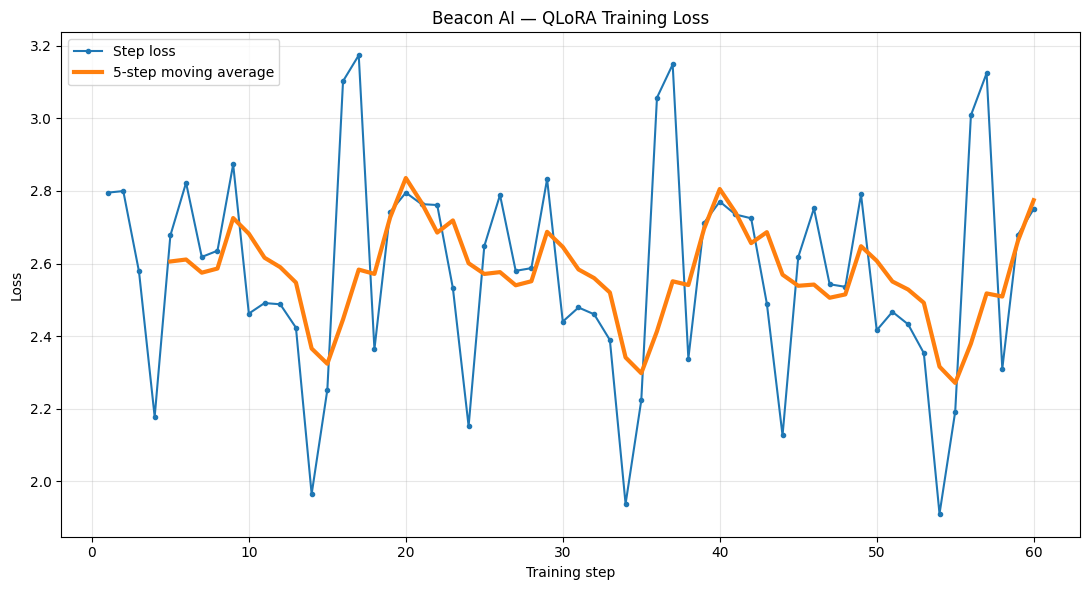

In [244]:
# ============================================================
# BEACON AI — LOSS CURVE + MOVING AVERAGE
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

losses = np.array(loss_history)

# Moving average window
window = min(5, len(losses))

if len(losses) >= window:
    moving_avg = np.convolve(
        losses,
        np.ones(window) / window,
        mode="valid"
    )
else:
    moving_avg = losses

steps = np.arange(1, len(losses) + 1)

plt.figure(figsize=(11, 6))

plt.plot(
    steps,
    losses,
    marker="o",
    linewidth=1.5,
    markersize=3,
    label="Step loss"
)

if len(losses) >= window:
    smooth_steps = np.arange(
        window,
        len(losses) + 1
    )

    plt.plot(
        smooth_steps,
        moving_avg,
        linewidth=3,
        label=f"{window}-step moving average"
    )

plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("Beacon AI — QLoRA Training Loss")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [245]:
# ============================================================
# BEACON AI — ROBUST CHECKPOINT SYSTEM
# ============================================================

import os
import json
import torch

CHECKPOINT_DIR = "/content/BeaconAI/checkpoints/beacon_qlora_pilot"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("=" * 60)
print("BEACON AI — CHECKPOINT SYSTEM")
print("=" * 60)

# ------------------------------------------------------------
# 1. Checkpoint saving function
# ------------------------------------------------------------

def save_beacon_checkpoint(
    model,
    processor,
    optimizer,
    epoch,
    global_step,
    loss_history,
    checkpoint_name
):

    checkpoint_path = os.path.join(
        CHECKPOINT_DIR,
        checkpoint_name
    )

    os.makedirs(
        checkpoint_path,
        exist_ok=True
    )

    print(
        f"\n💾 Saving checkpoint: {checkpoint_name}"
    )

    # --------------------------------------------------------
    # Save LoRA adapter
    # --------------------------------------------------------

    model.save_pretrained(
        checkpoint_path
    )

    # --------------------------------------------------------
    # Save processor
    # --------------------------------------------------------

    processor.save_pretrained(
        checkpoint_path
    )

    # --------------------------------------------------------
    # Save optimizer + training state
    # --------------------------------------------------------

    training_state = {
        "epoch": epoch,
        "global_step": global_step,
        "loss_history": loss_history,
    }

    torch.save(
        {
            "optimizer_state_dict":
                optimizer.state_dict(),

            "epoch":
                epoch,

            "global_step":
                global_step,

            "loss_history":
                loss_history,
        },

        os.path.join(
            checkpoint_path,
            "training_state.pt"
        )
    )

    # --------------------------------------------------------
    # Human-readable metadata
    # --------------------------------------------------------

    with open(
        os.path.join(
            checkpoint_path,
            "training_metadata.json"
        ),
        "w",
        encoding="utf-8"
    ) as f:

        json.dump(
            training_state,
            f,
            indent=2
        )

    print(
        f"✅ Checkpoint saved:"
        f"\n   {checkpoint_path}"
    )


# ------------------------------------------------------------
# 2. Save CURRENT model immediately
# ------------------------------------------------------------

save_beacon_checkpoint(
    model=model,
    processor=processor,
    optimizer=optimizer,
    epoch=0,
    global_step=global_step,
    loss_history=loss_history,
    checkpoint_name="latest"
)

print("\n🔥 Current Beacon model safely checkpointed.")

BEACON AI — CHECKPOINT SYSTEM

💾 Saving checkpoint: latest
✅ Checkpoint saved:
   /content/BeaconAI/checkpoints/beacon_qlora_pilot/latest

🔥 Current Beacon model safely checkpointed.


In [246]:
# ============================================================
# SAVE AFTER EVERY EPOCH
# ============================================================

save_beacon_checkpoint(
    model=model,
    processor=processor,
    optimizer=optimizer,
    epoch=epoch + 1,
    global_step=global_step,
    loss_history=loss_history,
    checkpoint_name=f"epoch_{epoch + 1:02d}"
)

# Also update "latest"
save_beacon_checkpoint(
    model=model,
    processor=processor,
    optimizer=optimizer,
    epoch=epoch + 1,
    global_step=global_step,
    loss_history=loss_history,
    checkpoint_name="latest"
)


💾 Saving checkpoint: epoch_03
✅ Checkpoint saved:
   /content/BeaconAI/checkpoints/beacon_qlora_pilot/epoch_03

💾 Saving checkpoint: latest
✅ Checkpoint saved:
   /content/BeaconAI/checkpoints/beacon_qlora_pilot/latest


In [247]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [248]:
DRIVE_CHECKPOINT_DIR = (
    "/content/drive/MyDrive/BeaconAI/checkpoints"
)

os.makedirs(
    DRIVE_CHECKPOINT_DIR,
    exist_ok=True
)

print(
    "Drive checkpoint directory:",
    DRIVE_CHECKPOINT_DIR
)

Drive checkpoint directory: /content/drive/MyDrive/BeaconAI/checkpoints


In [249]:
# ============================================================
# BEACON AI — VERIFY CHECKPOINT STORAGE
# ============================================================

from google.colab import drive
import os

drive.mount("/content/drive")

DRIVE_DIR = "/content/drive/MyDrive/BeaconAI/checkpoints"

os.makedirs(DRIVE_DIR, exist_ok=True)

print("=" * 60)
print("BEACON AI — CHECKPOINT STORAGE")
print("=" * 60)

print("Drive directory:")
print(DRIVE_DIR)

print("\nContents:")

for root, dirs, files in os.walk(DRIVE_DIR):

    level = root.replace(DRIVE_DIR, "").count(os.sep)

    indent = "  " * level

    print(indent + os.path.basename(root) + "/")

    for file in files:
        print(indent + "  " + file)

print("\n🔥 CHECKPOINT STORAGE VERIFIED")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BEACON AI — CHECKPOINT STORAGE
Drive directory:
/content/drive/MyDrive/BeaconAI/checkpoints

Contents:
checkpoints/

🔥 CHECKPOINT STORAGE VERIFIED


In [250]:
import os

possible_paths = [
    "/content/BeaconAI/checkpoints/beacon_qlora_pilot/latest",
    "/content/drive/MyDrive/BeaconAI/checkpoints/beacon_qlora_pilot/latest"
]

print("=" * 60)
print("BEACON CHECKPOINT SEARCH")
print("=" * 60)

for path in possible_paths:

    print("\n", path)

    if os.path.exists(path):

        print("✅ EXISTS")

        files = os.listdir(path)

        for f in files:
            print("   ", f)

    else:

        print("❌ NOT FOUND")

BEACON CHECKPOINT SEARCH

 /content/BeaconAI/checkpoints/beacon_qlora_pilot/latest
✅ EXISTS
    tokenizer_config.json
    processor_config.json
    README.md
    training_metadata.json
    training_state.pt
    chat_template.jinja
    tokenizer.json
    adapter_config.json
    adapter_model.safetensors

 /content/drive/MyDrive/BeaconAI/checkpoints/beacon_qlora_pilot/latest
❌ NOT FOUND


In [251]:
# ============================================================
# BEACON AI — BACKUP CURRENT CHECKPOINT TO GOOGLE DRIVE
# ============================================================

from google.colab import drive
import os
import shutil

# ------------------------------------------------------------
# 1. Mount Google Drive
# ------------------------------------------------------------

drive.mount("/content/drive")

# ------------------------------------------------------------
# 2. Define paths
# ------------------------------------------------------------

LOCAL_CHECKPOINT = (
    "/content/BeaconAI/checkpoints/"
    "beacon_qlora_pilot/latest"
)

DRIVE_CHECKPOINT = (
    "/content/drive/MyDrive/BeaconAI/"
    "checkpoints/beacon_qlora_pilot/latest"
)

os.makedirs(
    os.path.dirname(DRIVE_CHECKPOINT),
    exist_ok=True
)

# ------------------------------------------------------------
# 3. Verify local checkpoint
# ------------------------------------------------------------

assert os.path.exists(
    LOCAL_CHECKPOINT
), "❌ Local checkpoint not found!"

print("=" * 60)
print("BACKING UP BEACON CHECKPOINT")
print("=" * 60)

print("FROM:")
print(LOCAL_CHECKPOINT)

print("\nTO:")
print(DRIVE_CHECKPOINT)

# ------------------------------------------------------------
# 4. Copy checkpoint
# ------------------------------------------------------------

if os.path.exists(DRIVE_CHECKPOINT):
    shutil.rmtree(DRIVE_CHECKPOINT)

shutil.copytree(
    LOCAL_CHECKPOINT,
    DRIVE_CHECKPOINT
)

# ------------------------------------------------------------
# 5. Verify files
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DRIVE CHECKPOINT CONTENTS")
print("=" * 60)

for root, dirs, files in os.walk(DRIVE_CHECKPOINT):

    for file in files:

        path = os.path.join(root, file)

        size_mb = (
            os.path.getsize(path)
            / (1024 ** 2)
        )

        print(
            f"✅ {file:<35} "
            f"{size_mb:.2f} MB"
        )

# ------------------------------------------------------------
# 6. Critical file checks
# ------------------------------------------------------------

required_files = [
    "adapter_model.safetensors",
    "adapter_config.json",
    "training_state.pt",
    "training_metadata.json",
]

print("\n" + "=" * 60)
print("CHECKPOINT INTEGRITY")
print("=" * 60)

all_present = True

for filename in required_files:

    path = os.path.join(
        DRIVE_CHECKPOINT,
        filename
    )

    if os.path.exists(path):
        print("✅", filename)
    else:
        print("❌", filename)
        all_present = False

print("=" * 60)

if all_present:
    print("🔥 BEACON CHECKPOINT SAFELY BACKED UP TO DRIVE")
else:
    print("⚠️ CHECKPOINT BACKUP INCOMPLETE")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BACKING UP BEACON CHECKPOINT
FROM:
/content/BeaconAI/checkpoints/beacon_qlora_pilot/latest

TO:
/content/drive/MyDrive/BeaconAI/checkpoints/beacon_qlora_pilot/latest

DRIVE CHECKPOINT CONTENTS
✅ tokenizer_config.json               0.00 MB
✅ processor_config.json               0.00 MB
✅ README.md                           0.00 MB
✅ training_metadata.json              0.00 MB
✅ training_state.pt                   56.49 MB
✅ chat_template.jinja                 0.00 MB
✅ tokenizer.json                      10.89 MB
✅ adapter_config.json                 0.00 MB
✅ adapter_model.safetensors           28.17 MB

CHECKPOINT INTEGRITY
✅ adapter_model.safetensors
✅ adapter_config.json
✅ training_state.pt
✅ training_metadata.json
🔥 BEACON CHECKPOINT SAFELY BACKED UP TO DRIVE


In [252]:
# ============================================================
# BEACON AI — STEP 8
# RESUME-SAFE QLoRA TRAINING
# ============================================================

import os
import json
import torch
import matplotlib.pyplot as plt
from torch.optim import AdamW

# ============================================================
# CONFIGURATION
# ============================================================

DRIVE_ROOT = (
    "/content/drive/MyDrive/BeaconAI/checkpoints/"
    "beacon_qlora_pilot"
)

TOTAL_EPOCHS = 5

LEARNING_RATE = 1e-5
WEIGHT_DECAY = 0.01

GRADIENT_ACCUMULATION_STEPS = 4
MAX_GRAD_NORM = 1.0

os.makedirs(
    DRIVE_ROOT,
    exist_ok=True
)

print("=" * 60)
print("BEACON AI — RESUME-SAFE TRAINING")
print("=" * 60)


# ============================================================
# 1. VERIFY DRIVE
# ============================================================

assert os.path.exists(
    "/content/drive/MyDrive"
), "❌ Google Drive is not mounted."

print("✅ Google Drive mounted")


# ============================================================
# 2. CHECK FOR EXISTING CHECKPOINT
# ============================================================

LATEST_CHECKPOINT = os.path.join(
    DRIVE_ROOT,
    "latest"
)

checkpoint_state = os.path.join(
    LATEST_CHECKPOINT,
    "training_state.pt"
)

print("\nCheckpoint:")
print(LATEST_CHECKPOINT)

if os.path.exists(checkpoint_state):

    print("✅ Existing checkpoint found")

else:

    print("⚠️ No Drive checkpoint found")
    print("Starting from current model state.")


# ============================================================
# 3. CREATE OPTIMIZER
# ============================================================

trainable_params = [
    p for p in model.parameters()
    if p.requires_grad
]

optimizer = AdamW(
    trainable_params,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print("\nTrainable tensors:", len(trainable_params))


# ============================================================
# 4. RESTORE TRAINING STATE
# ============================================================

start_epoch = 0
global_step = 0

# Keep existing history if it already exists
if "loss_history" in globals():
    existing_loss_history = list(loss_history)
else:
    existing_loss_history = []


if os.path.exists(checkpoint_state):

    print("\nLoading training state...")

    state = torch.load(
        checkpoint_state,
        map_location="cpu"
    )

    # --------------------------------------------------------
    # Restore optimizer
    # --------------------------------------------------------

    optimizer.load_state_dict(
        state["optimizer_state_dict"]
    )

    # --------------------------------------------------------
    # Restore counters
    # --------------------------------------------------------

    start_epoch = state.get(
        "epoch",
        0
    )

    global_step = state.get(
        "global_step",
        0
    )

    # --------------------------------------------------------
    # Restore loss history
    # --------------------------------------------------------

    saved_history = state.get(
        "loss_history",
        []
    )

    if saved_history:
        existing_loss_history = list(
            saved_history
        )

    print("✅ Optimizer state restored")
    print("Checkpoint epoch:", start_epoch)
    print("Global step:", global_step)
    print(
        "Previous loss records:",
        len(existing_loss_history)
    )


loss_history = existing_loss_history


# ============================================================
# 5. SAVE FUNCTION
# ============================================================

def save_checkpoint(
    epoch,
    global_step,
    loss_history,
    epoch_losses
):

    epoch_name = f"epoch_{epoch:02d}"

    epoch_dir = os.path.join(
        DRIVE_ROOT,
        epoch_name
    )

    latest_dir = os.path.join(
        DRIVE_ROOT,
        "latest"
    )

    os.makedirs(
        epoch_dir,
        exist_ok=True
    )

    os.makedirs(
        latest_dir,
        exist_ok=True
    )

    # --------------------------------------------------------
    # Save adapter
    # --------------------------------------------------------

    model.save_pretrained(
        epoch_dir
    )

    # --------------------------------------------------------
    # Save processor
    # --------------------------------------------------------

    processor.save_pretrained(
        epoch_dir
    )

    # --------------------------------------------------------
    # Save optimizer/training state
    # --------------------------------------------------------

    training_state = {

        "epoch": epoch,

        "global_step": global_step,

        "loss_history": loss_history,

        "epoch_losses": epoch_losses,

    }

    torch.save(
        {
            "optimizer_state_dict":
                optimizer.state_dict(),

            "epoch":
                epoch,

            "global_step":
                global_step,

            "loss_history":
                loss_history,

            "epoch_losses":
                epoch_losses,
        },

        os.path.join(
            epoch_dir,
            "training_state.pt"
        )
    )

    # --------------------------------------------------------
    # Human-readable metadata
    # --------------------------------------------------------

    with open(
        os.path.join(
            epoch_dir,
            "training_metadata.json"
        ),
        "w",
        encoding="utf-8"
    ) as f:

        json.dump(
            training_state,
            f,
            indent=2
        )

    # --------------------------------------------------------
    # Update latest
    # --------------------------------------------------------

    import shutil

    if os.path.exists(latest_dir):

        shutil.rmtree(
            latest_dir
        )

    shutil.copytree(
        epoch_dir,
        latest_dir
    )

    print(
        f"💾 Checkpoint saved → {epoch_name}"
    )

    print(
        f"💾 Latest updated → latest"
    )


# ============================================================
# 6. TRAINING
# ============================================================

model.train()

epoch_losses = []

print("\n" + "=" * 60)
print("TRAINING")
print("=" * 60)

if start_epoch >= TOTAL_EPOCHS:

    print(
        f"\n🔥 Already at epoch {start_epoch}."
    )

    print(
        f"TOTAL_EPOCHS = {TOTAL_EPOCHS}"
    )

    print(
        "Increase TOTAL_EPOCHS if you want to continue."
    )

else:

    for epoch in range(
        start_epoch,
        TOTAL_EPOCHS
    ):

        current_epoch = epoch + 1

        print("\n" + "=" * 60)

        print(
            f"EPOCH "
            f"{current_epoch}/{TOTAL_EPOCHS}"
        )

        print("=" * 60)

        model.train()

        epoch_loss = 0.0

        optimizer.zero_grad(
            set_to_none=True
        )

        for sample_idx in range(
            len(dataset)
        ):

            # ------------------------------------------------
            # Build multimodal batch
            # ------------------------------------------------

            batch = collator([
                dataset[sample_idx]
            ])

            # ------------------------------------------------
            # Move tensors to GPU
            # ------------------------------------------------

            device = next(
                model.parameters()
            ).device

            model_inputs = {}

            for key, value in batch.items():

                if isinstance(
                    value,
                    torch.Tensor
                ):

                    model_inputs[key] = (
                        value.to(device)
                    )

                else:

                    model_inputs[key] = value

            # ------------------------------------------------
            # Forward
            # ------------------------------------------------

            outputs = model(
                **model_inputs
            )

            loss = outputs.loss

            # ------------------------------------------------
            # Record REAL loss
            # ------------------------------------------------

            loss_value = loss.item()

            loss_history.append(
                loss_value
            )

            epoch_loss += loss_value

            # ------------------------------------------------
            # Backward
            # ------------------------------------------------

            scaled_loss = (
                loss /
                GRADIENT_ACCUMULATION_STEPS
            )

            scaled_loss.backward()

            # ------------------------------------------------
            # Optimizer step
            # ------------------------------------------------

            should_update = (

                (sample_idx + 1)
                % GRADIENT_ACCUMULATION_STEPS
                == 0

                or

                sample_idx == len(dataset) - 1

            )

            if should_update:

                torch.nn.utils.clip_grad_norm_(
                    trainable_params,
                    MAX_GRAD_NORM
                )

                optimizer.step()

                optimizer.zero_grad(
                    set_to_none=True
                )

                global_step += 1

            # ------------------------------------------------
            # Logging
            # ------------------------------------------------

            print(
                f"[{sample_idx + 1:02d}/"
                f"{len(dataset)}]"
                f" Loss: {loss_value:.4f}"
            )

        # ====================================================
        # EPOCH SUMMARY
        # ====================================================

        average_loss = (
            epoch_loss /
            len(dataset)
        )

        epoch_losses.append(
            average_loss
        )

        print("\n" + "-" * 60)

        print(
            f"🔥 EPOCH {current_epoch} COMPLETE"
        )

        print(
            f"Average loss: "
            f"{average_loss:.6f}"
        )

        print(
            f"Optimizer steps: "
            f"{global_step}"
        )

        print("-" * 60)

        # ====================================================
        # SAVE CHECKPOINT
        # ====================================================

        save_checkpoint(
            epoch=current_epoch,
            global_step=global_step,
            loss_history=loss_history,
            epoch_losses=epoch_losses
        )


# ============================================================
# 7. FINAL LOSS SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("TRAINING FINISHED")
print("=" * 60)

print(
    "Total recorded losses:",
    len(loss_history)
)

print(
    "Total optimizer steps:",
    global_step
)

if epoch_losses:

    print("\nEpoch-average losses:")

    for i, value in enumerate(
        epoch_losses,
        1
    ):

        print(
            f"Epoch {i}: {value:.6f}"
        )

print("\n🔥 BEACON TRAINING COMPLETE")

BEACON AI — RESUME-SAFE TRAINING
✅ Google Drive mounted

Checkpoint:
/content/drive/MyDrive/BeaconAI/checkpoints/beacon_qlora_pilot/latest
✅ Existing checkpoint found

Trainable tensors: 288

Loading training state...
✅ Optimizer state restored
Checkpoint epoch: 3
Global step: 15
Previous loss records: 60

TRAINING

EPOCH 4/5
[01/20] Loss: 2.7059
[02/20] Loss: 2.6889
[03/20] Loss: 2.4524
[04/20] Loss: 2.0995
[05/20] Loss: 2.5868
[06/20] Loss: 2.7133
[07/20] Loss: 2.5086
[08/20] Loss: 2.4834
[09/20] Loss: 2.7540
[10/20] Loss: 2.3904
[11/20] Loss: 2.4558
[12/20] Loss: 2.4025
[13/20] Loss: 2.3166
[14/20] Loss: 1.8846
[15/20] Loss: 2.1612
[16/20] Loss: 2.9594
[17/20] Loss: 3.1017
[18/20] Loss: 2.2840
[19/20] Loss: 2.6457
[20/20] Loss: 2.7340

------------------------------------------------------------
🔥 EPOCH 4 COMPLETE
Average loss: 2.516433
Optimizer steps: 20
------------------------------------------------------------
💾 Checkpoint saved → epoch_04
💾 Latest updated → latest

EPOCH 5/5


BEACON AI — TRUE EPOCH LOSS
Total recorded losses: 100
Epoch 1: 2.611923
Epoch 2: 2.580165
Epoch 3: 2.548075
Epoch 4: 2.516433
Epoch 5: 2.486770


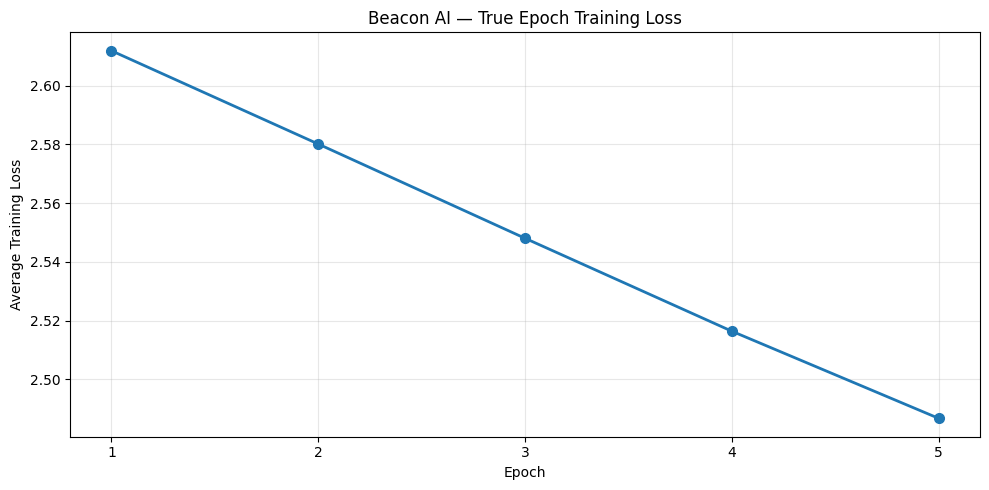


TRAINING SUMMARY
Initial loss:  2.611923
Final loss:    2.486770
Reduction:     0.125153
Reduction %:   4.79%


In [254]:
# ============================================================
# BEACON AI — RECOVER TRUE EPOCH LOSS HISTORY
# ============================================================

import os
import torch
import matplotlib.pyplot as plt

CHECKPOINT = (
    "/content/drive/MyDrive/BeaconAI/checkpoints/"
    "beacon_qlora_pilot/latest/training_state.pt"
)

state = torch.load(
    CHECKPOINT,
    map_location="cpu"
)

loss_history = state["loss_history"]

print("=" * 60)
print("BEACON AI — TRUE EPOCH LOSS")
print("=" * 60)

print("Total recorded losses:", len(loss_history))

SAMPLES_PER_EPOCH = 20

true_epoch_losses = []

for start in range(
    0,
    len(loss_history),
    SAMPLES_PER_EPOCH
):

    epoch_losses = loss_history[
        start:start + SAMPLES_PER_EPOCH
    ]

    if len(epoch_losses) == SAMPLES_PER_EPOCH:

        avg = sum(epoch_losses) / len(epoch_losses)

        true_epoch_losses.append(avg)

        print(
            f"Epoch {len(true_epoch_losses)}: "
            f"{avg:.6f}"
        )


# ============================================================
# PLOT
# ============================================================

epochs = range(
    1,
    len(true_epoch_losses) + 1
)

plt.figure(figsize=(10, 5))

plt.plot(
    epochs,
    true_epoch_losses,
    marker="o",
    linewidth=2,
    markersize=7
)

plt.xlabel("Epoch")
plt.ylabel("Average Training Loss")
plt.title("Beacon AI — True Epoch Training Loss")

plt.xticks(list(epochs))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# IMPROVEMENT
# ============================================================

print("\n" + "=" * 60)
print("TRAINING SUMMARY")
print("=" * 60)

if len(true_epoch_losses) >= 2:

    initial = true_epoch_losses[0]
    final = true_epoch_losses[-1]

    reduction = initial - final

    percentage = (
        reduction / initial
    ) * 100

    print(f"Initial loss:  {initial:.6f}")
    print(f"Final loss:    {final:.6f}")
    print(f"Reduction:     {reduction:.6f}")
    print(f"Reduction %:   {percentage:.2f}%")

In [255]:
# ============================================================
# BEACON AI — BASE vs BEACON QLoRA INFERENCE TEST
# ============================================================

import os
import torch
from PIL import Image

# ------------------------------------------------------------
# 1. TEST IMAGE
# ------------------------------------------------------------

TEST_IMAGE = "/content/BeaconAI/datasets/images/img_0020.jpg"

assert os.path.exists(TEST_IMAGE), \
    f"Test image not found: {TEST_IMAGE}"

image = Image.open(TEST_IMAGE).convert("RGB")

print("=" * 70)
print("BEACON AI — INFERENCE COMPARISON")
print("=" * 70)

print("Test image:", TEST_IMAGE)
print("Image size:", image.size)


# ------------------------------------------------------------
# 2. TEST QUESTION
# ------------------------------------------------------------

QUESTION = "Describe this outfit in detail, including the clothing pieces, colors, silhouette, style, and overall aesthetic."

print("\nQuestion:")
print(QUESTION)


# ------------------------------------------------------------
# 3. CREATE CONVERSATION
# ------------------------------------------------------------

messages = [
    {
        "role": "system",
        "content": (
            "You are Beacon AI, an expert fashion designer, "
            "fashion stylist, clothing analyst, and customization assistant."
        )
    },
    {
        "role": "user",
        "content": [
            {
                "type": "image"
            },
            {
                "type": "text",
                "text": QUESTION
            }
        ]
    }
]


# ------------------------------------------------------------
# 4. PREPARE QWEN INPUT
# ------------------------------------------------------------

text = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

inputs = processor(
    text=[text],
    images=[image],
    return_tensors="pt"
)

# Move tensors to model device
inputs = {
    k: v.to(model.device) if torch.is_tensor(v) else v
    for k, v in inputs.items()
}

print("\nInput prepared.")
print("Input IDs:", inputs["input_ids"].shape)


# ------------------------------------------------------------
# 5. GENERATION FUNCTION
# ------------------------------------------------------------

def generate_response():

    with torch.inference_mode():

        output_ids = model.generate(
            **inputs,
            max_new_tokens=120,
            do_sample=False,
            temperature=None,
            top_p=None,
            use_cache=True
        )

    # Remove prompt tokens
    generated_ids = output_ids[
        :, inputs["input_ids"].shape[1]:
    ]

    response = processor.batch_decode(
        generated_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=True
    )[0]

    return response.strip()


# ------------------------------------------------------------
# 6. BASE QWEN
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("BASE QWEN2.5-VL")
print("=" * 70)

model.eval()

# Temporarily disable LoRA
with model.disable_adapter():

    base_response = generate_response()

print("\nBASE RESPONSE:")
print(base_response)


# ------------------------------------------------------------
# 7. BEACON QLoRA
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("BEACON QLoRA")
print("=" * 70)

# Adapter automatically becomes active after
# leaving disable_adapter() context.

model.eval()

beacon_response = generate_response()

print("\nBEACON RESPONSE:")
print(beacon_response)


# ------------------------------------------------------------
# 8. FINAL COMPARISON
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("🔥 BASE vs BEACON COMPARISON")
print("=" * 70)

print("\nQUESTION:")
print(QUESTION)

print("\n" + "-" * 70)
print("BASE QWEN:")
print("-" * 70)
print(base_response)

print("\n" + "-" * 70)
print("BEACON:")
print("-" * 70)
print(beacon_response)

print("\n" + "=" * 70)
print("TEST COMPLETE")
print("=" * 70)

BEACON AI — INFERENCE COMPARISON
Test image: /content/BeaconAI/datasets/images/img_0020.jpg
Image size: (2500, 3750)

Question:
Describe this outfit in detail, including the clothing pieces, colors, silhouette, style, and overall aesthetic.

Input prepared.
Input IDs: torch.Size([1, 542])

BASE QWEN2.5-VL


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.



BASE RESPONSE:
The outfit features a sophisticated and minimalist design, characterized by its neutral color palette and clean lines. The ensemble is composed of two main pieces: a long, flowing trench coat and wide-leg trousers.

**Trench Coat:**
- **Color:** The trench coat is a light beige or off-white, providing a neutral backdrop that allows the other elements of the outfit to stand out.
- **Silhouette:** The coat has a loose, flowing silhouette with a slight A-line shape, giving it a relaxed yet elegant feel. It features a high collar and a front button closure, which adds a touch of

BEACON QLoRA

BEACON RESPONSE:
The outfit features a minimalist and elegant design, characterized by its neutral color palette and clean lines. The ensemble consists of a long, flowing trench coat and wide-leg trousers.

**Trench Coat:**
- **Color:** The trench coat is a light beige or off-white, providing a soft and understated look.
- **Silhouette:** The coat has a loose, flowing silhouette with 

In [257]:
# ============================================================
# BEACON AI — UNSEEN IMAGE GENERALIZATION TEST
# ============================================================

TEST_IMAGE = "/content/BeaconAI/test/unseen_001.jpg"

image = Image.open(TEST_IMAGE).convert("RGB")

QUESTION = """
Analyze this outfit as a fashion expert.

Identify:
1. The main clothing pieces
2. Colors and patterns
3. Silhouette and fit
4. Style/aesthetic
5. Suitable occasions
6. How the outfit could be styled further

Do not invent details that cannot be visually determined.
"""

messages = [
    {
        "role": "system",
        "content": (
            "You are Beacon AI, an expert fashion designer, "
            "fashion stylist, clothing analyst, and customization assistant."
        )
    },
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": QUESTION}
        ]
    }
]

text = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

inputs = processor(
    text=[text],
    images=[image],
    return_tensors="pt"
)

inputs = {
    k: v.to(model.device) if torch.is_tensor(v) else v
    for k, v in inputs.items()
}


def generate():

    with torch.inference_mode():

        output_ids = model.generate(
            **inputs,
            max_new_tokens=250,
            do_sample=False,
            use_cache=True
        )

    generated_ids = output_ids[
        :, inputs["input_ids"].shape[1]:
    ]

    return processor.batch_decode(
        generated_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0].strip()


# ------------------------------------------------------------
# BASE
# ------------------------------------------------------------

print("=" * 70)
print("BASE QWEN2.5-VL")
print("=" * 70)

with model.disable_adapter():

    base_response = generate()

print(base_response)


# ------------------------------------------------------------
# BEACON
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("BEACON QLoRA")
print("=" * 70)

beacon_response = generate()

print(beacon_response)


# ------------------------------------------------------------
# COMPARISON
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("GENERALIZATION TEST COMPLETE")
print("=" * 70)

BASE QWEN2.5-VL
1. **The Main Clothing Pieces**: The outfit consists of a long, flowing dress with a fitted bodice and a full, tulle skirt. The bodice is adorned with intricate lace and floral appliqués, while the skirt features similar lace and floral details, creating a cohesive and elegant look.

2. **Colors and Patterns**: The dress is primarily in a soft, creamy beige color with accents of light pink and white floral appliqués. The lace is detailed with small, delicate flowers and leaves, adding texture and depth to the fabric.

3. **Silhouette and Fit**: The silhouette is classic and elegant, with a fitted bodice that accentuates the figure and a full, voluminous skirt that flows down to the floor. The fit is form-fitting at the waist, gradually widening towards the hips and then flaring out into the full skirt.

4. **Style/Aesthetic**: The style is romantic and vintage-inspired, with a touch of elegance and sophistication. The use of lace and floral appliqués gives it a delicate

In [258]:
# ============================================================
# BEACON AI — REAL UNSEEN IMAGE GENERALIZATION TEST
# ============================================================

from google.colab import files
from PIL import Image
import torch
import os

print("=" * 70)
print("BEACON AI — UNSEEN IMAGE TEST")
print("=" * 70)

# ------------------------------------------------------------
# 1. UPLOAD UNSEEN IMAGE
# ------------------------------------------------------------

uploaded = files.upload()

assert len(uploaded) > 0, "❌ No image uploaded."

TEST_IMAGE = next(iter(uploaded.keys()))

image = Image.open(TEST_IMAGE).convert("RGB")

print("\n✅ Image loaded")
print("Filename:", TEST_IMAGE)
print("Format:", Image.open(TEST_IMAGE).format)
print("Size:", image.size)


# ------------------------------------------------------------
# 2. BLIND FASHION ANALYSIS PROMPT
# ------------------------------------------------------------

QUESTION = """
Analyze this outfit as a professional fashion designer and stylist.

Identify:

1. Main clothing pieces
2. Colors and patterns
3. Neckline and sleeve design
4. Silhouette and fit
5. Fabric or material appearance
6. Decorative details
7. Overall style/aesthetic
8. Suitable occasions
9. One practical styling suggestion

Only describe details that can reasonably be determined from the image.
Do not invent hidden details such as exact fabric composition.
"""


messages = [
    {
        "role": "system",
        "content": (
            "You are Beacon AI, an expert fashion designer, "
            "fashion stylist, clothing analyst, and customization assistant."
        )
    },
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": QUESTION}
        ]
    }
]


# ------------------------------------------------------------
# 3. PROCESS IMAGE
# ------------------------------------------------------------

text = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

inputs = processor(
    text=[text],
    images=[image],
    return_tensors="pt"
)

device = next(model.parameters()).device

inputs = {
    k: v.to(device) if torch.is_tensor(v) else v
    for k, v in inputs.items()
}

print("\nInput tensor shape:")
print(inputs["input_ids"].shape)


# ------------------------------------------------------------
# 4. GENERATION FUNCTION
# ------------------------------------------------------------

def generate_answer():

    with torch.inference_mode():

        output_ids = model.generate(
            **inputs,
            max_new_tokens=300,
            do_sample=False,
            use_cache=True
        )

    generated_ids = output_ids[
        :,
        inputs["input_ids"].shape[1]:
    ]

    answer = processor.batch_decode(
        generated_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0]

    return answer.strip()


# ------------------------------------------------------------
# 5. BASE QWEN
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("BASE QWEN2.5-VL")
print("=" * 70)

model.eval()

with model.disable_adapter():

    base_response = generate_answer()

print("\n" + base_response)


# ------------------------------------------------------------
# 6. BEACON
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("BEACON QLoRA")
print("=" * 70)

model.eval()

beacon_response = generate_answer()

print("\n" + beacon_response)


# ------------------------------------------------------------
# 7. SIDE-BY-SIDE OUTPUT
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("🔥 UNSEEN IMAGE — BASE vs BEACON")
print("=" * 70)

print("\nQUESTION:")
print(QUESTION)

print("\n" + "-" * 70)
print("BASE QWEN2.5-VL")
print("-" * 70)
print(base_response)

print("\n" + "-" * 70)
print("BEACON QLoRA")
print("-" * 70)
print(beacon_response)

print("\n" + "=" * 70)
print("GENERALIZATION TEST COMPLETE")
print("=" * 70)

BEACON AI — UNSEEN IMAGE TEST


Saving unseen_001.jpg to unseen_001.jpg

✅ Image loaded
Filename: unseen_001.jpg
Format: AVIF
Size: (834, 1406)

Input tensor shape:
torch.Size([1, 626])

BASE QWEN2.5-VL

1. **Main Clothing Pieces**: The outfit consists of a single piece, which is a formal gown.
2. **Colors and Patterns**: The dress is predominantly in a soft, creamy beige color with intricate floral appliqués in shades of pink and white. The bodice features lace detailing, while the skirt is adorned with elaborate floral embroidery.
3. **Neckline and Sleeve Design**: The neckline is off-the-shoulder, accentuating the shoulders and creating a delicate, elegant look. There are no visible sleeves on the dress.
4. **Silhouette and Fit**: The silhouette is ballgown-like, with a fitted bodice that flares out into a full, flowing skirt. The fit is structured at the waist, gradually widening towards the bottom.
5. **Fabric or Material Appearance**: The fabric appears to be a lightweight tulle or organza for the bodice, with 

In [259]:
# ============================================================
# BEACON AI — 6-IMAGE GENERALIZATION BENCHMARK
# ============================================================

import os
import glob
import json
import torch
from PIL import Image

print("=" * 70)
print("BEACON AI — UNSEEN FASHION GENERALIZATION BENCHMARK")
print("=" * 70)

# ============================================================
# 1. FIND UNSEEN IMAGES
# ============================================================

TEST_IMAGES = sorted(
    glob.glob("/content/unseen_*.jpg")
)

# Also check /content/BeaconAI/test if necessary
if len(TEST_IMAGES) == 0:

    TEST_IMAGES = sorted(
        glob.glob("/content/BeaconAI/test/unseen_*.jpg")
    )

print("\nImages found:", len(TEST_IMAGES))

for path in TEST_IMAGES:
    print(" ", os.path.basename(path))

assert len(TEST_IMAGES) >= 6, (
    f"Expected at least 6 unseen images, "
    f"found {len(TEST_IMAGES)}"
)

# ============================================================
# 2. STANDARDIZED EVALUATION PROMPT
# ============================================================

QUESTION = """
Analyze this outfit as a professional fashion designer and stylist.

Identify:

1. Main clothing pieces
2. Colors and patterns
3. Neckline and sleeve design where applicable
4. Silhouette and fit
5. Fabric or material appearance
6. Decorative or construction details
7. Overall style/aesthetic
8. Suitable occasions
9. One practical styling suggestion

Only describe details that can reasonably be determined
from the image. Do not invent exact fabric composition
or hidden details.
"""

# ============================================================
# 3. GENERATION FUNCTION
# ============================================================

def prepare_inputs(image):

    messages = [
        {
            "role": "system",
            "content": (
                "You are Beacon AI, an expert fashion designer, "
                "fashion stylist, clothing analyst, and "
                "customization assistant."
            )
        },
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {
                    "type": "text",
                    "text": QUESTION
                }
            ]
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    batch = processor(
        text=[text],
        images=[image],
        return_tensors="pt"
    )

    device = next(model.parameters()).device

    batch = {
        k: v.to(device) if torch.is_tensor(v) else v
        for k, v in batch.items()
    }

    return batch


def generate_answer(batch):

    with torch.inference_mode():

        output_ids = model.generate(
            **batch,
            max_new_tokens=300,
            do_sample=False,
            use_cache=True
        )

    generated_ids = output_ids[
        :,
        batch["input_ids"].shape[1]:
    ]

    answer = processor.batch_decode(
        generated_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0]

    return answer.strip()


# ============================================================
# 4. RUN BENCHMARK
# ============================================================

results = []

model.eval()

for idx, image_path in enumerate(TEST_IMAGES, 1):

    filename = os.path.basename(image_path)

    print("\n" + "=" * 70)
    print(f"TEST {idx}/{len(TEST_IMAGES)} — {filename}")
    print("=" * 70)

    # --------------------------------------------------------
    # Load image
    # --------------------------------------------------------

    image = Image.open(
        image_path
    ).convert("RGB")

    print(
        "Image size:",
        image.size
    )

    # --------------------------------------------------------
    # Prepare identical input
    # --------------------------------------------------------

    batch = prepare_inputs(image)

    # --------------------------------------------------------
    # BASE QWEN
    # --------------------------------------------------------

    print("\n[BASE QWEN] Generating...")

    with model.disable_adapter():

        base_response = generate_answer(
            batch
        )

    print("\nBASE:")
    print(base_response)

    # --------------------------------------------------------
    # BEACON
    # --------------------------------------------------------

    print("\n[BEACON QLoRA] Generating...")

    beacon_response = generate_answer(
        batch
    )

    print("\nBEACON:")
    print(beacon_response)

    # --------------------------------------------------------
    # Store
    # --------------------------------------------------------

    results.append(
        {
            "image": filename,
            "base": base_response,
            "beacon": beacon_response
        }
    )


# ============================================================
# 5. SAVE RESULTS
# ============================================================

OUTPUT_FILE = (
    "/content/BeaconAI/"
    "unseen_generalization_results.json"
)

os.makedirs(
    "/content/BeaconAI",
    exist_ok=True
)

with open(
    OUTPUT_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        results,
        f,
        indent=2,
        ensure_ascii=False
    )

print("\n" + "=" * 70)
print("🔥 BENCHMARK COMPLETE")
print("=" * 70)

print(
    "Results saved to:",
    OUTPUT_FILE
)

print(
    "Images evaluated:",
    len(results)
)

BEACON AI — UNSEEN FASHION GENERALIZATION BENCHMARK

Images found: 6
  unseen_001.jpg
  unseen_002.jpg
  unseen_003.jpg
  unseen_004.jpg
  unseen_005.jpg
  unseen_006.jpg

TEST 1/6 — unseen_001.jpg
Image size: (834, 1406)

[BASE QWEN] Generating...

BASE:
1. **Main Clothing Pieces**: The outfit consists of a single piece, which is a formal gown.
2. **Colors and Patterns**: The dress is predominantly in a soft, creamy beige color with intricate floral appliqués in shades of pink and white. The bodice features lace detailing, while the skirt is adorned with elaborate floral embroidery.
3. **Neckline and Sleeve Design**: The neckline is off-the-shoulder, and there are no visible sleeves.
4. **Silhouette and Fit**: The silhouette is ballgown-like, with a fitted bodice that flares out into a full, flowing skirt. The fit is structured at the waist, gradually widening towards the bottom.
5. **Fabric or Material Appearance**: The fabric appears to be a lightweight tulle or organza for the bodi

In [260]:
# ============================================================
# BEACON AI — FINAL PORTABLE PROJECT BACKUP
# ============================================================

import os
import json
import shutil
import subprocess
from datetime import datetime

from google.colab import drive

# ------------------------------------------------------------
# 1. MOUNT GOOGLE DRIVE
# ------------------------------------------------------------

drive.mount("/content/drive")

# ------------------------------------------------------------
# 2. PATHS
# ------------------------------------------------------------

PROJECT_DIR = "/content/BeaconAI"

DRIVE_ROOT = "/content/drive/MyDrive/BeaconAI_FINAL_PILOT"

CHECKPOINT_SRC = "/content/BeaconAI/checkpoints"
DATASET_SRC = "/content/BeaconAI/datasets"

UNSEEN_RESULTS = "/content/BeaconAI/unseen_generalization_results.json"

os.makedirs(DRIVE_ROOT, exist_ok=True)

print("=" * 70)
print("BEACON AI — FINAL PORTABLE BACKUP")
print("=" * 70)

print("\nSource:")
print(PROJECT_DIR)

print("\nDestination:")
print(DRIVE_ROOT)


# ------------------------------------------------------------
# 3. COPY COMPLETE CHECKPOINT DIRECTORY
# ------------------------------------------------------------

print("\n[1] CHECKPOINTS")

checkpoint_dst = os.path.join(
    DRIVE_ROOT,
    "checkpoints"
)

if os.path.exists(checkpoint_dst):
    shutil.rmtree(checkpoint_dst)

shutil.copytree(
    CHECKPOINT_SRC,
    checkpoint_dst
)

print("✅ All checkpoints copied")


# ------------------------------------------------------------
# 4. COPY DATASET
# ------------------------------------------------------------

print("\n[2] DATASET")

dataset_dst = os.path.join(
    DRIVE_ROOT,
    "datasets"
)

if os.path.exists(dataset_dst):
    shutil.rmtree(dataset_dst)

shutil.copytree(
    DATASET_SRC,
    dataset_dst
)

print("✅ Dataset copied")


# ------------------------------------------------------------
# 5. COPY UNSEEN EVALUATION RESULTS
# ------------------------------------------------------------

print("\n[3] EVALUATION")

if os.path.exists(UNSEEN_RESULTS):

    shutil.copy2(
        UNSEEN_RESULTS,
        os.path.join(
            DRIVE_ROOT,
            "unseen_generalization_results.json"
        )
    )

    print("✅ Unseen benchmark copied")

else:

    print("⚠️ Unseen benchmark not found")


# ------------------------------------------------------------
# 6. SAVE ENVIRONMENT INFORMATION
# ------------------------------------------------------------

print("\n[4] ENVIRONMENT")

environment = {}

# Python
environment["python_version"] = subprocess.check_output(
    ["python", "--version"],
    text=True
).strip()

# Pip packages
try:

    environment["pip_freeze"] = subprocess.check_output(
        ["pip", "freeze"],
        text=True
    ).splitlines()

except Exception as e:

    environment["pip_freeze_error"] = str(e)


# Torch
try:

    import torch

    environment["torch_version"] = torch.__version__
    environment["cuda_available"] = torch.cuda.is_available()

    if torch.cuda.is_available():

        environment["cuda_version"] = torch.version.cuda
        environment["gpu_name"] = torch.cuda.get_device_name(0)

except Exception as e:

    environment["torch_error"] = str(e)


# Transformers
try:

    import transformers

    environment["transformers_version"] = transformers.__version__

except Exception as e:

    environment["transformers_error"] = str(e)


# PEFT
try:

    import peft

    environment["peft_version"] = peft.__version__

except Exception as e:

    environment["peft_error"] = str(e)


with open(
    os.path.join(DRIVE_ROOT, "environment.json"),
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        environment,
        f,
        indent=2
    )

print("✅ Environment information saved")


# ------------------------------------------------------------
# 7. SAVE TRAINING VARIABLES IF THEY EXIST
# ------------------------------------------------------------

print("\n[5] TRAINING HISTORY")

history = {}

# Loss history
if "loss_history" in globals():

    try:
        history["loss_history"] = [
            float(x) for x in loss_history
        ]
        print("✅ loss_history saved")

    except Exception:
        pass


# Epoch losses
if "epoch_losses" in globals():

    try:

        history["epoch_losses"] = {
            str(k): float(v)
            for k, v in epoch_losses.items()
        }

        print("✅ epoch_losses saved")

    except Exception:
        pass


# Global step
if "global_step" in globals():

    try:
        history["global_step"] = int(global_step)
    except Exception:
        pass


# Current epoch
if "start_epoch" in globals():

    try:
        history["start_epoch"] = int(start_epoch)
    except Exception:
        pass


with open(
    os.path.join(
        DRIVE_ROOT,
        "training_history.json"
    ),
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        history,
        f,
        indent=2
    )

print("✅ Training history saved")


# ------------------------------------------------------------
# 8. CREATE RESUME MANIFEST
# ------------------------------------------------------------

print("\n[6] RESUME MANIFEST")

latest_checkpoint = os.path.join(
    DRIVE_ROOT,
    "checkpoints",
    "beacon_qlora_pilot",
    "latest"
)

# If your actual structure is checkpoints/latest,
# this fallback handles it.
if not os.path.exists(latest_checkpoint):

    latest_checkpoint = os.path.join(
        DRIVE_ROOT,
        "checkpoints",
        "latest"
    )


# Try to capture model name if it exists
model_name = globals().get(
    "MODEL_NAME",
    "UNKNOWN — check training notebook"
)

manifest = {

    "project": "Beacon AI",

    "backup_created": datetime.now().isoformat(),

    "status": "QLoRA pilot training COMPLETE",

    "model_name": model_name,

    "base_model": "Qwen2.5-VL",

    "training_method": "QLoRA",

    "dataset": {
        "image_count": 20,
        "annotation_file":
            "datasets/annotations/train.jsonl",
        "image_directory":
            "datasets/images/"
    },

    "training": {
        "epochs_completed": 5,
        "total_recorded_losses": 100,
        "checkpoint":
            "checkpoints/beacon_qlora_pilot/latest"
    },

    "important_files": {

        "latest_checkpoint":
            "checkpoints/beacon_qlora_pilot/latest",

        "epoch_05":
            "checkpoints/beacon_qlora_pilot/epoch_05",

        "dataset":
            "datasets/",

        "unseen_benchmark":
            "unseen_generalization_results.json",

        "environment":
            "environment.json",

        "training_history":
            "training_history.json"
    },

    "resume_instruction": (
        "Mount Google Drive, load the base Qwen2.5-VL model, "
        "load the LoRA adapter from "
        "checkpoints/beacon_qlora_pilot/latest, "
        "restore training_state.pt, restore optimizer state, "
        "and continue training from the recorded epoch/global step."
    )
}


with open(
    os.path.join(
        DRIVE_ROOT,
        "RESUME_MANIFEST.json"
    ),
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        manifest,
        f,
        indent=2
    )

print("✅ Resume manifest created")


# ------------------------------------------------------------
# 9. CREATE HUMAN-READABLE RESUME FILE
# ------------------------------------------------------------

resume_text = f"""
============================================================
BEACON AI — PORTABLE TRAINING CHECKPOINT
============================================================

Backup created:
{datetime.now().isoformat()}

PROJECT
-------
Beacon AI

MODEL
-----
Qwen2.5-VL
Training method: QLoRA

DATASET
-------
20 fashion images
20 conversational annotations

TRAINING
--------
Epochs completed: 5
Total recorded losses: 100

CHECKPOINT
----------
{latest_checkpoint}

IMPORTANT
---------
DO NOT DELETE:

adapter_model.safetensors
adapter_config.json
training_state.pt
optimizer state
tokenizer files
processor files

These files are required for resuming the trained Beacon
version without retraining from the beginning.

DATASET
-------
datasets/images/
datasets/annotations/train.jsonl

EVALUATION
----------
unseen_generalization_results.json

ENVIRONMENT
-----------
environment.json

TRAINING HISTORY
----------------
training_history.json

HOW TO RESUME
-------------
1. Open a new Google Colab.
2. Mount Google Drive.
3. Load the same Qwen2.5-VL base model.
4. Load the LoRA adapter from the latest checkpoint.
5. Load processor/tokenizer.
6. Restore training_state.pt.
7. Restore optimizer state.
8. Continue from the saved epoch/global step.

============================================================
THIS IS THE SAVED BEACON AI PILOT VERSION.
============================================================
"""

with open(
    os.path.join(
        DRIVE_ROOT,
        "HOW_TO_RESUME.txt"
    ),
    "w",
    encoding="utf-8"
) as f:

    f.write(resume_text)

print("✅ HOW_TO_RESUME.txt created")


# ------------------------------------------------------------
# 10. SHOW BACKUP CONTENTS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("BACKUP CONTENTS")
print("=" * 70)

for root, dirs, files in os.walk(DRIVE_ROOT):

    level = root.replace(
        DRIVE_ROOT,
        ""
    ).count(os.sep)

    indent = "  " * level

    print(f"{indent}{os.path.basename(root)}/")

    for file in files:

        print(
            f"{indent}  {file}"
        )


# ------------------------------------------------------------
# 11. FINAL STATUS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("🔥 BEACON AI BACKUP COMPLETE")
print("=" * 70)

print("\nGoogle Drive location:")
print(DRIVE_ROOT)

print("\nYou can safely disconnect this Colab runtime now.")
print("\nYour trained Beacon version is preserved.")
print("🔥 RESUME-READY 🔥")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BEACON AI — FINAL PORTABLE BACKUP

Source:
/content/BeaconAI

Destination:
/content/drive/MyDrive/BeaconAI_FINAL_PILOT

[1] CHECKPOINTS
✅ All checkpoints copied

[2] DATASET
✅ Dataset copied

[3] EVALUATION
✅ Unseen benchmark copied

[4] ENVIRONMENT
✅ Environment information saved

[5] TRAINING HISTORY
✅ loss_history saved
✅ Training history saved

[6] RESUME MANIFEST
✅ Resume manifest created
✅ HOW_TO_RESUME.txt created

BACKUP CONTENTS
BeaconAI_FINAL_PILOT/
  unseen_generalization_results.json
  environment.json
  training_history.json
  RESUME_MANIFEST.json
  HOW_TO_RESUME.txt
  checkpoints/
    beacon_qlora_pilot/
      tokenizer_config.json
      processor_config.json
      README.md
      chat_template.jinja
      tokenizer.json
      adapter_config.json
      adapter_model.safetensors
      epoch_03/
        tokenizer_config.json
        processor_conf